# Population-Level Statistics

This notebook inventories every persisted scalar `stats_*` column found in MALCA run products or a review database and plots a distribution for each one.

It focuses on scalar columns flattened into parquet outputs or the review database. Table-like outputs from `compute_stats(...)` such as `nightly_table`, `by_camera`, or `seasons` are not written as ordinary `stats_*` columns and are therefore excluded from the histogram pass.


In [1]:
import json
import re
import sqlite3
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import MaxNLocator

from malca.plotting.lightcurve_publication import (
    FIG_SINGLE_COL_WIDTH,
    FIG_TWO_COL_WIDTH,
    apply_publication_rcparams,
    finalize_publication_figure,
)

warnings.filterwarnings('ignore')

apply_publication_rcparams(plt)
plt.rcParams.update({
    'axes.grid': False,
    'axes.facecolor': 'white',
    'figure.facecolor': 'white',
})

REPO_ROOT = next(
    (p for p in (Path.cwd(), *Path.cwd().parents) if (p / "pyproject.toml").exists() and (p / "malca").is_dir()),
    Path.cwd(),
)


## Configuration

- `DATA_SOURCE = 'review_db'` loads only the flattened `stats_*` columns from the configured review database in read-only mode. The default is the complete July 1 candidate set.
- `REVIEW_CLASS_OVERLAYS` overlays the dipper, LTV, and microlensing subsets on every histogram. All populations use the same bins and full-population clipping range, with bin fractions normalized to sum to one for each plotted cohort. Remove an entry from the mapping to disable that overlay.
- Every statistic is exported as its own standalone figure. Figures use adaptive shared bins and save as vector PDF plus 300-dpi PNG under `results/population_stats_publication`.
- Constant numeric fields remain visible in the inventory but are excluded from the publication figures; binary and low-cardinality fields are rendered as probability bars rather than misleading continuous histograms.
- Set `DATA_SOURCE = 'parquet'` to use the older run-product workflow. In that mode, leave `RUN_DIR_NAMES` empty to auto-discover the configured magnitude-bin runs, or list exact run directory names.
- Some newer run parquets intentionally omit flattened `stats_*` columns even when those fields are present in the review database.


In [2]:
RUN_ROOT_CANDIDATES = [REPO_ROOT / 'output/runs']
RUNS_ROOT = next((path for path in RUN_ROOT_CANDIDATES if path.exists()), RUN_ROOT_CANDIDATES[0])
print(f'Using run root: {RUNS_ROOT.resolve()}')

DATA_SOURCE = 'review_db'  # 'review_db' or 'parquet'
REVIEW_DB_RUN_NAME = 'dat3-full-extended_2026-07-01-v4'
REVIEW_DB_LABEL = 'Candidates'
REVIEW_DB_PATH = RUNS_ROOT / REVIEW_DB_RUN_NAME / 'review' / 'review.db'
REVIEW_CLASS_OVERLAYS = {
    'dipper': {
        'label': 'Dippers',
        'color': '#D55E00',  # Okabe-Ito vermillion
        'linestyle': '-',
    },
    'ltv': {
        'label': 'LTVs',
        'color': '#009E73',  # Okabe-Ito bluish green
        'linestyle': '--',
    },
    'microlensing': {
        'label': 'Microlensing events',
        'color': '#CC79A7',  # Okabe-Ito reddish purple
        'linestyle': '-.',
    },
}
FULL_POPULATION_COLOR = '#0072B2'  # Okabe-Ito blue

FIGURE_COLUMNS = 1
FIGURE_WIDTH = FIG_TWO_COL_WIDTH
HIST_MIN_BINS = 12
HIST_MAX_BINS = 24
EXPORT_FIGURES = True
EXPORT_FORMATS = ('pdf', 'png')
FIGURE_OUTPUT_DIR = RUNS_ROOT / REVIEW_DB_RUN_NAME / 'results' / 'population_stats_publication'

RUN_DIR_NAMES = []
RUN_PATTERNS = [
    ('12_12.5', '12-12.5'),
    ('12.5_13', '12.5-13'),
    ('13_13.5', '13-13.5'),
    ('13.5_14', '13.5-14'),
    ('14_14.5', '14-14.5'),
]

RESULT_PRIORITY = [
    # Older run products often retain flattened stats_* columns here;
    # newer runs may require DATA_SOURCE = 'review_db' instead.
    'lc_events_enriched.parquet',
    'lc_events_vetted.parquet',
    'lc_events_spectra.parquet',
    'lc_events_neighbors.parquet',
    'lc_events_classified.parquet',
    'lc_events_characterized.parquet',
    'lc_events_filtered.parquet',
]

LOW_CARDINALITY_MAX = 12
PERCENTILE_CLIP = (0.01, 0.99)
BASE_COLORS = [
    FULL_POPULATION_COLOR, '#009E73', '#CC79A7', '#E69F00',
    '#56B4E9', '#F0E442', '#000000', '#7A7A7A',
]

LOG10_COLUMNS = {
    'stats_file_points_total',
    'stats_file_points_kept_after_filter',
    'stats_time_span_days',
    'stats_n_unique_nights',
    'stats_cadence_mean_dt_days',
    'stats_cadence_median_dt_days',
    'stats_cadence_p05_dt_days',
    'stats_cadence_p95_dt_days',
    'stats_variability_reduced_chi2_vs_constant',
    'stats_variability_lomb_scargle_best_period_days',
    'stats_anderson_darling',
    'stats_gp_drw_tau',
    'stats_mhps_high',
    'stats_mhps_low',
    'stats_mhps_ratio',
}


Using run root: /Users/calder/code/malca/output/runs


In [3]:
def infer_mag_bin_label(run_dir: Path) -> str:
    run_params = run_dir / 'run_params.json'
    if run_params.exists():
        try:
            params = json.loads(run_params.read_text())
            mag_bin = params.get('mag_bin')
            if mag_bin:
                return str(mag_bin)
            mag_min = params.get('mag_min')
            mag_max = params.get('mag_max')
            if mag_min is not None and mag_max is not None:
                return f'{float(mag_min):g}-{float(mag_max):g}'
        except Exception:
            pass

    match = re.search(r'(\d+(?:\.\d+)?)_(\d+(?:\.\d+)?)', run_dir.name)
    if match:
        return f'{float(match.group(1)):g}-{float(match.group(2)):g}'
    return run_dir.name


def pick_results_file(run_dir: Path) -> Path | None:
    results_dir = run_dir / 'results'
    if not results_dir.exists():
        return None

    for filename in RESULT_PRIORITY:
        exact = results_dir / filename
        if exact.exists():
            return exact

        stem = Path(filename).stem
        matches = sorted(
            results_dir.glob(f'{stem}_*.parquet'),
            key=lambda p: p.stat().st_mtime,
            reverse=True,
        )
        if matches:
            return matches[0]
    return None


def sort_labels(labels):
    preferred = [label for _, label in RUN_PATTERNS]
    present = {str(label) for label in labels if pd.notna(label)}
    ordered = [label for label in preferred if label in present]

    leftovers = []
    for label in labels:
        if pd.isna(label):
            continue
        label_str = str(label)
        if label_str not in ordered and label_str not in leftovers:
            leftovers.append(label_str)

    def key(label):
        match = re.match(r'^(\d+(?:\.\d+)?)-(\d+(?:\.\d+)?)$', str(label))
        if match:
            return (0, float(match.group(1)), float(match.group(2)), str(label))
        return (1, str(label))

    return ordered + sorted(leftovers, key=key)


def discover_run_files() -> pd.DataFrame:
    rows = []
    if RUN_DIR_NAMES:
        run_dirs = [RUNS_ROOT / name for name in RUN_DIR_NAMES]
        for run_dir in run_dirs:
            result_file = pick_results_file(run_dir)
            if result_file is None:
                continue
            rows.append({
                'run_dir': run_dir,
                'run_name': run_dir.name,
                'mag_bin': infer_mag_bin_label(run_dir),
                'candidate_file': result_file,
            })
    else:
        run_dirs = sorted([p for p in RUNS_ROOT.iterdir() if p.is_dir()])
        for token, label in RUN_PATTERNS:
            matches = []
            for run_dir in run_dirs:
                if token not in run_dir.name:
                    continue
                result_file = pick_results_file(run_dir)
                if result_file is not None:
                    matches.append((run_dir, result_file))
            if not matches:
                print(f'Warning: no run products found for {label} under {RUNS_ROOT}')
                continue
            run_dir, result_file = max(matches, key=lambda item: item[1].stat().st_mtime)
            rows.append({
                'run_dir': run_dir,
                'run_name': run_dir.name,
                'mag_bin': label,
                'candidate_file': result_file,
            })

    if not rows:
        raise FileNotFoundError(f'No run products found under {RUNS_ROOT}')
    return pd.DataFrame(rows)


def load_population_frame(run_manifest: pd.DataFrame) -> pd.DataFrame:
    frames = []
    for row in run_manifest.itertuples(index=False):
        df = pd.read_parquet(row.candidate_file)
        df = df.copy()
        df['run_name'] = row.run_name
        df['mag_bin'] = row.mag_bin
        df['candidate_file'] = str(row.candidate_file)
        frames.append(df)
    if not frames:
        raise FileNotFoundError(f'No readable run products found in {RUNS_ROOT}')
    return pd.concat(frames, ignore_index=True)


def numeric_series(series: pd.Series) -> pd.Series:
    s = pd.to_numeric(series, errors='coerce')
    return s[np.isfinite(s)]


def is_binary_series(series: pd.Series) -> bool:
    s = numeric_series(series)
    if s.empty:
        return False
    return set(np.unique(s)) <= {0.0, 1.0}


def is_integer_like_series(series: pd.Series) -> bool:
    s = numeric_series(series)
    if s.empty:
        return False
    arr = s.to_numpy(dtype=float)
    return np.allclose(arr, np.round(arr))


def stats_group(col: str) -> str:
    if col.startswith('stats_file_points_') or col.startswith('stats_jd_') or col in {
        'stats_time_span_days',
        'stats_n_unique_nights',
        'stats_duty_cycle_fraction',
    }:
        return 'Coverage and timing'
    if col.startswith('stats_cadence_'):
        return 'Cadence'
    if col.startswith('stats_photometry_') or col.startswith('stats_clipped_') or col == 'stats_n_outliers_removed_robust_3sigma':
        return 'Photometry'
    if col.startswith('stats_error_and_snr_stats_'):
        return 'Errors and SNR'
    if col.startswith('stats_variability_lomb_scargle_') or col.startswith('stats_harmonics_') or col.startswith('stats_psi_'):
        return 'Period and harmonics'
    if col.startswith('stats_variability_') or col.startswith('stats_trend_'):
        return 'Core variability and trend'
    if col.startswith('stats_gp_drw_') or col == 'stats_iar_phi' or col.startswith('stats_mhps_'):
        return 'Stochastic models'
    return 'ALeRCE-style moments'


GROUP_ORDER = [
    'Coverage and timing',
    'Cadence',
    'Photometry',
    'Errors and SNR',
    'Core variability and trend',
    'ALeRCE-style moments',
    'Period and harmonics',
    'Stochastic models',
]


def plot_kind(series: pd.Series) -> str:
    s = numeric_series(series)
    if s.empty:
        return 'empty'
    if is_binary_series(s):
        return 'binary'
    if is_integer_like_series(s) and s.nunique() <= LOW_CARDINALITY_MAX:
        return 'discrete'
    return 'continuous'


def transform_series(col: str, series: pd.Series) -> tuple[pd.Series, str, str]:
    s = numeric_series(series)
    xlabel = col.removeprefix('stats_')
    transform = 'linear'

    if col.endswith('_fap'):
        s = s[s > 0]
        if not s.empty:
            s = -np.log10(s)
            xlabel = f'-log10({xlabel})'
            transform = '-log10'
        return s, xlabel, transform

    if col in LOG10_COLUMNS:
        s = s[s > 0]
        if not s.empty:
            s = np.log10(s)
            xlabel = f'log10({xlabel})'
            transform = 'log10'
    return s, xlabel, transform



def clip_series(series: pd.Series, kind: str) -> pd.Series:
    if series.empty or kind in {'binary', 'discrete'}:
        return series
    lo = series.quantile(PERCENTILE_CLIP[0])
    hi = series.quantile(PERCENTILE_CLIP[1])
    clipped = series[(series >= lo) & (series <= hi)]
    return clipped if not clipped.empty else series


def bins_for_series(series: pd.Series, kind: str):
    if kind == 'binary':
        return np.array([-0.5, 0.5, 1.5])
    if kind == 'discrete':
        lo = int(np.floor(series.min()))
        hi = int(np.ceil(series.max()))
        return np.arange(lo - 0.5, hi + 1.5, 1.0)
    if series.empty or series.min() == series.max():
        center = float(series.iloc[0]) if not series.empty else 0.0
        return np.linspace(center - 0.5, center + 0.5, HIST_MIN_BINS + 1)

    fd_edges = np.histogram_bin_edges(series.to_numpy(dtype=float), bins='fd')
    n_bins = int(np.clip(len(fd_edges) - 1, HIST_MIN_BINS, HIST_MAX_BINS))
    return np.linspace(float(series.min()), float(series.max()), n_bins + 1)


LABEL_REPLACEMENTS = {
    'ahl': 'AHL',
    'ce': 'CE',
    'eb': 'EB',
    'jd': 'JD',
    'iqr': 'IQR',
    'lc': 'LC',
    'loo': 'LOO',
    'mse': 'MSE',
    'n': 'N',
    'pdm': 'PDM',
    'r2': 'R²',
    'rcs': 'RCS',
    'sf': 'SF',
    'snr': 'S/N',
    'fap': 'FAP',
    'gp': 'GP',
    'drw': 'DRW',
    'iar': 'IAR',
    'mhps': 'MHPS',
    'roms': 'RoMS',
    'stetson': 'Stetson',
    'lomb': 'Lomb',
    'scargle': 'Scargle',
    'chi2': 'χ²',
}


def publication_stat_label(column: str) -> str:
    raw = column.removeprefix('stats_')
    for prefix in ('error_and_snr_stats_', 'photometry_', 'variability_'):
        raw = raw.removeprefix(prefix)
    raw = raw.replace('_', ' ')
    words = [LABEL_REPLACEMENTS.get(word.lower(), word) for word in raw.split()]
    return ' '.join(words)


def publication_axis_label(column: str, transform: str) -> str:
    label = publication_stat_label(column)
    if transform == 'log10':
        return rf'$\log_{{10}}$({label})'
    if transform == '-log10':
        return rf'$-\log_{{10}}$({label})'
    return label


def figure_slug(value: str) -> str:
    return re.sub(r'[^a-z0-9]+', '_', value.lower()).strip('_')


def chunked(values: list[str], size: int):
    for start in range(0, len(values), size):
        yield values[start:start + size]


def balanced_pages(values: list[str], max_size: int) -> list[list[str]]:
    if not values:
        return []
    n_pages = int(np.ceil(len(values) / max_size))
    base_size, extra = divmod(len(values), n_pages)
    page_sizes = [base_size + int(index < extra) for index in range(n_pages)]
    pages = []
    start = 0
    for page_size in page_sizes:
        pages.append(values[start:start + page_size])
        start += page_size
    return pages


def build_inventory(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    rows = []
    for col in cols:
        s = df[col]
        numeric = numeric_series(s)
        _, _, transform = transform_series(col, s)
        rows.append({
            'column': col,
            'group': stats_group(col),
            'dtype': str(s.dtype),
            'non_null': int(s.notna().sum()),
            'completeness': float(s.notna().mean()),
            'n_unique_non_null': int(s.dropna().nunique()),
            'plot_kind': plot_kind(s),
            'transform': transform,
            'min': float(numeric.min()) if not numeric.empty else np.nan,
            'max': float(numeric.max()) if not numeric.empty else np.nan,
        })
    inventory = pd.DataFrame(
        rows,
        columns=[
            'column', 'group', 'dtype', 'non_null', 'completeness',
            'n_unique_non_null', 'plot_kind', 'transform', 'min', 'max',
        ],
    )
    if inventory.empty:
        return inventory
    return inventory.sort_values(['group', 'column']).reset_index(drop=True)


def summarize_column(df: pd.DataFrame, column: str) -> pd.DataFrame:
    rows = []
    labels = sort_labels(df['mag_bin'].dropna().unique()) + ['ALL']
    for label in labels:
        subset = df[column] if label == 'ALL' else df.loc[df['mag_bin'] == label, column]
        s = numeric_series(subset)
        if s.empty:
            continue
        rows.append({
            'column': column,
            'mag_bin': label,
            'count': int(s.size),
            'mean': float(s.mean()),
            'std': float(s.std(ddof=1)) if s.size > 1 else np.nan,
            'median': float(s.median()),
            'mad': float(np.median(np.abs(s - s.median()))),
            'p05': float(s.quantile(0.05)),
            'p25': float(s.quantile(0.25)),
            'p75': float(s.quantile(0.75)),
            'p95': float(s.quantile(0.95)),
        })
    return pd.DataFrame(rows)


def palette_for(labels: list[str]) -> dict[str, str]:
    ordered = sort_labels(labels)
    return {label: BASE_COLORS[i % len(BASE_COLORS)] for i, label in enumerate(ordered)}


def _plot_group_histograms_legacy(
    df: pd.DataFrame,
    cols: list[str],
    title: str,
    split_col: str = 'mag_bin',
    *,
    overlay_df: pd.DataFrame | None = None,
    overlay_label: str | None = None,
    overlay_color: str = '#d95f02',
) -> None:
    if not cols:
        return
    if len(cols) > 1:
        for col in cols:
            _plot_group_histograms_legacy(
                df, [col], publication_stat_label(col), split_col,
                overlay_df=overlay_df, overlay_label=overlay_label,
                overlay_color=overlay_color,
            )
        return

    labels = sort_labels(df[split_col].dropna().unique())
    palette = palette_for(labels)
    ncols = min(3, len(cols))
    nrows = int(np.ceil(len(cols) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 3.8 * nrows), squeeze=False)

    for idx, col in enumerate(cols):
        ax = axes[idx // ncols, idx % ncols]
        kind = INVENTORY_MAP[col]['plot_kind']
        xlabel = col.removeprefix('stats_')
        transform_label = INVENTORY_MAP[col]['transform']
        if transform_label == 'log10':
            xlabel = f'log10({xlabel})'
        elif transform_label == '-log10':
            xlabel = f'-log10({xlabel})'

        reference_series, _, _ = transform_series(col, df[col])
        reference_series = clip_series(reference_series, kind)
        if reference_series.empty:
            ax.axis('off')
            continue
        bins = bins_for_series(reference_series, kind)

        for label in labels:
            series, _, _ = transform_series(col, df.loc[df[split_col] == label, col])
            population_n = int(df[split_col].eq(label).sum())
            if kind not in {'binary', 'discrete'}:
                series = series[series.between(reference_series.min(), reference_series.max())]
            if series.empty:
                continue
            ax.hist(
                series,
                bins=bins,
                weights=np.full(series.size, 1.0 / series.size),
                histtype='step',
                linewidth=1.8,
                color=palette[label],
                label=f'{label} (N={population_n:,})',
            )

        if overlay_df is not None and overlay_label and col in overlay_df.columns:
            overlay_series, _, _ = transform_series(col, overlay_df[col])
            if kind not in {'binary', 'discrete'}:
                overlay_series = overlay_series[
                    overlay_series.between(reference_series.min(), reference_series.max())
                ]
            if not overlay_series.empty:
                ax.hist(
                    overlay_series,
                    bins=bins,
                    weights=np.full(overlay_series.size, 1.0 / overlay_series.size),
                    histtype='step',
                    linewidth=2.6,
                    color=overlay_color,
                    label=f'{overlay_label} (N={len(overlay_df):,})',
                    zorder=4,
                )

        ax.set_xlabel(xlabel, fontsize=9)
        ax.set_ylabel('Fraction', fontsize=9)
        ax.tick_params(labelsize=8)
        if idx == 0:
            ax.legend(fontsize=8, title='Population')

    for idx in range(len(cols), nrows * ncols):
        axes[idx // ncols, idx % ncols].set_visible(False)

    finalize_publication_figure(fig)
    plt.show()


def plot_group_histograms(
    df: pd.DataFrame,
    cols: list[str],
    split_col: str = 'mag_bin',
    *,
    overlays: list[dict] | None = None,
    output_dir: Path | None = None,
) -> list[Path]:
    if not cols:
        return []

    overlays = [overlay for overlay in (overlays or []) if not overlay['df'].empty]
    labels = sort_labels(df[split_col].dropna().unique())
    palette = palette_for(labels)
    pages = [[col] for col in cols]
    saved_paths: list[Path] = []

    legend_handles = []
    for label in labels:
        population_n = int(df[split_col].eq(label).sum())
        legend_handles.append(Patch(
            facecolor=palette[label],
            edgecolor=palette[label],
            alpha=0.22,
            label=f'{label} (N={population_n:,})',
        ))
    for overlay in overlays:
        legend_handles.append(Line2D(
            [0], [0], color=overlay['color'], linewidth=1.8,
            linestyle=overlay['linestyle'],
            label=f"{overlay['label']} (N={len(overlay['df']):,})",
        ))

    for page_cols in pages:
        n_panels = len(page_cols)
        ncols = min(FIGURE_COLUMNS, n_panels)
        nrows = int(np.ceil(n_panels / ncols))
        figure_width = FIGURE_WIDTH
        figure_height = 1.15 + 2.45 * nrows
        fig, axes = plt.subplots(
            nrows, ncols, figsize=(figure_width, figure_height), squeeze=False,
        )
        fig.legend(
            handles=legend_handles,
            loc='upper center',
            bbox_to_anchor=(0.5, 0.965),
            ncol=min(2, len(legend_handles)),
            frameon=False,
            handlelength=2.2,
            columnspacing=1.5,
        )

        for panel_index, col in enumerate(page_cols):
            ax = axes[panel_index // ncols, panel_index % ncols]
            kind = INVENTORY_MAP[col]['plot_kind']
            transform_label = INVENTORY_MAP[col]['transform']
            reference_series, _, _ = transform_series(col, df[col])
            reference_series = clip_series(reference_series, kind)
            if reference_series.empty:
                ax.axis('off')
                continue

            panel_overlays = []
            for overlay in overlays:
                overlay_series, _, _ = transform_series(col, overlay['df'][col])
                panel_overlays.append((overlay, overlay_series))

            if kind in {'binary', 'discrete'}:
                overlay_values = {
                    value
                    for _, overlay_series in panel_overlays
                    for value in overlay_series.tolist()
                }
                values = sorted(set(reference_series.tolist()) | overlay_values)
                positions = np.arange(len(values), dtype=float)
                populated_overlays = [
                    item for item in panel_overlays if not item[1].empty
                ]
                n_distributions = len(labels) + len(populated_overlays)
                bar_width = 0.76 / max(n_distributions, 1)
                distribution_index = 0
                for label in labels:
                    series, _, _ = transform_series(col, df.loc[df[split_col] == label, col])
                    probabilities = series.value_counts(normalize=True).reindex(values, fill_value=0.0)
                    offset = (distribution_index - (n_distributions - 1) / 2) * bar_width
                    ax.bar(
                        positions + offset, probabilities.to_numpy(), width=bar_width,
                        facecolor=palette[label], edgecolor=palette[label],
                        alpha=0.28, linewidth=0.7, zorder=2,
                    )
                    distribution_index += 1
                for overlay, overlay_series in populated_overlays:
                    probabilities = overlay_series.value_counts(normalize=True).reindex(values, fill_value=0.0)
                    offset = (distribution_index - (n_distributions - 1) / 2) * bar_width
                    ax.bar(
                        positions + offset, probabilities.to_numpy(), width=bar_width,
                        facecolor='none', edgecolor=overlay['color'],
                        linewidth=1.3, zorder=4,
                    )
                    distribution_index += 1
                ax.set_xticks(positions, [f'{value:g}' for value in values])
                ax.set_ylabel('Fraction')
            else:
                bins = bins_for_series(reference_series, kind)
                for label in labels:
                    series, _, _ = transform_series(col, df.loc[df[split_col] == label, col])
                    series = series[series.between(reference_series.min(), reference_series.max())]
                    if series.empty:
                        continue
                    histtype = 'stepfilled' if len(labels) == 1 else 'step'
                    ax.hist(
                        series, bins=bins,
                        weights=np.full(series.size, 1.0 / series.size),
                        histtype=histtype,
                        linewidth=0.9, color=palette[label],
                        alpha=0.20 if histtype == 'stepfilled' else 0.85, zorder=2,
                    )
                for overlay, overlay_series in panel_overlays:
                    overlay_series = overlay_series[
                        overlay_series.between(reference_series.min(), reference_series.max())
                    ]
                    if not overlay_series.empty:
                        ax.hist(
                            overlay_series, bins=bins,
                            weights=np.full(overlay_series.size, 1.0 / overlay_series.size),
                            histtype='step',
                            linewidth=1.8, color=overlay['color'],
                            linestyle=overlay['linestyle'], zorder=4,
                        )
                ax.set_ylabel('Fraction')
                ax.xaxis.set_major_locator(MaxNLocator(nbins=5))

            ax.set_xlabel(publication_axis_label(col, transform_label), fontsize=8.5)
            ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
            ax.tick_params(direction='out', length=3.0, width=0.7, labelsize=7.5)
            ax.grid(axis='y', color='0.88', linewidth=0.5, zorder=0)
            ax.set_axisbelow(True)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.margins(x=0.02)
            try:
                ax.ticklabel_format(axis='y', style='sci', scilimits=(-3, 3), useMathText=True)
            except AttributeError:
                pass

        for empty_index in range(n_panels, nrows * ncols):
            axes[empty_index // ncols, empty_index % ncols].axis('off')

        finalize_publication_figure(fig, rect=(0.0, 0.0, 1.0, 0.91), w_pad=0.8, h_pad=0.9)
        if output_dir is not None:
            output_dir.mkdir(parents=True, exist_ok=True)
            stat_slug = figure_slug(page_cols[0].removeprefix('stats_'))
            stem = f'population_stats_{stat_slug}'
            for extension in EXPORT_FORMATS:
                output_path = output_dir / f'{stem}.{extension}'
                fig.savefig(
                    output_path, dpi=300, bbox_inches=None,
                    facecolor='white', transparent=False,
                )
                saved_paths.append(output_path)
        plt.show()
        plt.close(fig)

    return saved_paths


In [4]:
if DATA_SOURCE == 'review_db':
    if not REVIEW_DB_PATH.exists():
        raise FileNotFoundError(REVIEW_DB_PATH)

    connect_target = f'file:{REVIEW_DB_PATH}?mode=ro'
    with sqlite3.connect(connect_target, uri=True) as conn:
        candidate_schema = conn.execute('PRAGMA table_info(candidates)').fetchall()
        database_stats_cols = [row[1] for row in candidate_schema if row[1].startswith('stats_')]
        if not database_stats_cols:
            raise RuntimeError(f'No stats_* columns found in {REVIEW_DB_PATH}')
        quoted_cols = ', '.join(f'"{col}"' for col in database_stats_cols)
        df_all = pd.read_sql_query(f'SELECT candidate_id, {quoted_cols} FROM candidates', conn)
        overlay_candidate_ids = {}
        for event_class in REVIEW_CLASS_OVERLAYS:
            overlay_candidate_ids[event_class] = {
                row[0]
                for row in conn.execute(
                    "SELECT candidate_id FROM reviews "
                    "WHERE lower(trim(COALESCE(event_class, ''))) = lower(?)",
                    (event_class,),
                )
            }

    df_all['run_name'] = REVIEW_DB_RUN_NAME
    df_all['mag_bin'] = REVIEW_DB_LABEL
    df_all['candidate_file'] = str(REVIEW_DB_PATH)
    review_class_overlays = []
    for event_class, style in REVIEW_CLASS_OVERLAYS.items():
        candidate_ids = overlay_candidate_ids.get(event_class, set())
        overlay_df = df_all.loc[df_all['candidate_id'].isin(candidate_ids)].copy()
        review_class_overlays.append({
            'event_class': event_class,
            'label': style['label'],
            'color': style['color'],
            'linestyle': style['linestyle'],
            'df': overlay_df,
        })
    run_manifest = pd.DataFrame([{
        'run_name': REVIEW_DB_RUN_NAME,
        'mag_bin': REVIEW_DB_LABEL,
        'candidate_file': REVIEW_DB_PATH,
        'data_source': 'review_db',
    }])
    print(
        f'Loaded {len(df_all):,} candidate rows and {len(database_stats_cols):,} stats_* columns '
        f'from read-only review DB: {REVIEW_DB_PATH}'
    )
    for overlay in review_class_overlays:
        print(
            f"Overlay population: {len(overlay['df']):,} {overlay['label'].lower()}"
        )
elif DATA_SOURCE == 'parquet':
    run_manifest = discover_run_files()
    df_all = load_population_frame(run_manifest)
    review_class_overlays = []
    print(f'Loaded {len(df_all):,} rows from {run_manifest.shape[0]} run product(s).')
else:
    raise ValueError(f'Unsupported DATA_SOURCE={DATA_SOURCE!r}; use review_db or parquet')

display(run_manifest[['run_name', 'mag_bin', 'candidate_file']])


Loaded 22,942 candidate rows and 168 stats_* columns from read-only review DB: /Users/calder/code/malca/output/runs/dat3-full-extended_2026-07-01-v4/review/review.db
Overlay population: 82 dippers
Overlay population: 45 ltvs
Overlay population: 22 microlensing events


,run_name,mag_bin,candidate_file
0,dat3-full-extended_2026-07-01-v4,Candidates,/Users/calder/code/malca/output/runs/dat3-full...


In [5]:
stats_cols_all = sorted([c for c in df_all.columns if c.startswith('stats_')])
scalar_stats_cols = [
    c for c in stats_cols_all
    if pd.api.types.is_numeric_dtype(df_all[c]) and df_all[c].notna().any()
]
skipped_stats_cols = sorted(set(stats_cols_all) - set(scalar_stats_cols))

inventory = build_inventory(df_all, scalar_stats_cols)
INVENTORY_MAP = inventory.set_index('column').to_dict(orient='index')
nonvarying_stats_cols = [
    c for c in scalar_stats_cols if INVENTORY_MAP[c]['n_unique_non_null'] <= 1
]
plottable_stats_cols = [c for c in scalar_stats_cols if c not in nonvarying_stats_cols]

print(f'{len(stats_cols_all)} stats_* columns found')
print(f'{len(scalar_stats_cols)} populated numeric scalar stats found')
print(f'{len(plottable_stats_cols)} nonconstant stats will be plotted')
if nonvarying_stats_cols:
    print(f'{len(nonvarying_stats_cols)} constant stats excluded from figures: {nonvarying_stats_cols}')
if skipped_stats_cols:
    print(f'{len(skipped_stats_cols)} stats_* columns skipped because they are non-numeric or all-null')

display(inventory)


168 stats_* columns found
158 populated numeric scalar stats found
155 nonconstant stats will be plotted
3 constant stats excluded from figures: ['stats_autocor_length', 'stats_variability_quasi_periodicity_n_bins', 'stats_variability_quasi_periodicity_smooth_window_bins']
10 stats_* columns skipped because they are non-numeric or all-null


,column,group,dtype,non_null,completeness,n_unique_non_null,plot_kind,transform,min,max
0,stats_ahl_ratio,ALeRCE-style moments,float64,22942,1.0,21079,continuous,linear,0.249645,4.206107
1,stats_amplitude,ALeRCE-style moments,float64,22942,1.0,19306,continuous,linear,0.018500,2.880481
2,stats_anderson_darling,ALeRCE-style moments,float64,22942,1.0,22942,continuous,log10,0.166436,505.730715
3,stats_autocor_length,ALeRCE-style moments,float64,22942,1.0,1,binary,linear,1.000000,1.000000
4,stats_beyond_1_std,ALeRCE-style moments,float64,22942,1.0,20010,continuous,linear,0.032609,0.509537
...,...,...,...,...,...,...,...,...,...,...
153,stats_mhps_high,Stochastic models,float64,22942,1.0,22942,continuous,log10,0.000089,24.233299
154,stats_mhps_low,Stochastic models,float64,22942,1.0,22942,continuous,log10,0.000085,233.738298
155,stats_mhps_non_zero,Stochastic models,float64,22942,1.0,2906,continuous,linear,219.000000,6165.000000
156,stats_mhps_pn_flag,Stochastic models,int64,22942,1.0,2,binary,linear,0.000000,1.000000


## Coverage Audit

The table below makes the scope explicit: every discovered scalar numeric `stats_*` column is assigned to a plot family and a plotting mode.


In [6]:
coverage_audit = (
    inventory.groupby(['group', 'plot_kind'])['column']
    .count()
    .rename('n_columns')
    .reset_index()
    .sort_values(['group', 'plot_kind'])
)
display(coverage_audit)


,group,plot_kind,n_columns
0,ALeRCE-style moments,binary,1
1,ALeRCE-style moments,continuous,41
2,Cadence,continuous,4
3,Core variability and trend,binary,1
4,Core variability and trend,continuous,26
5,Core variability and trend,discrete,1
6,Coverage and timing,continuous,7
7,Errors and SNR,continuous,7
8,Period and harmonics,continuous,43
9,Period and harmonics,discrete,1


## Long-Form Summary Table

`summary_long` keeps per-column summary statistics for each magnitude bin plus an `ALL` aggregate. Query it by column name when needed.


In [7]:
summary_frames = [summarize_column(df_all, col) for col in scalar_stats_cols]
summary_long = (
    pd.concat(summary_frames, ignore_index=True)
    if summary_frames
    else pd.DataFrame(columns=['column', 'mag_bin', 'count', 'mean', 'std', 'median', 'mad', 'p05', 'p25', 'p75', 'p95'])
)
display(summary_long.head(20))


,column,mag_bin,count,mean,std,median,mad,p05,p25,p75,p95
0,stats_ahl_ratio,Candidates,22942,1.269599,0.458001,1.149170,0.163240,0.661134,1.026321,1.403528,2.242999
1,stats_ahl_ratio,ALL,22942,1.269599,0.458001,1.149170,0.163240,0.661134,1.026321,1.403528,2.242999
2,stats_amplitude,Candidates,22942,0.121027,0.193792,0.068592,0.030000,0.030339,0.044166,0.121205,0.334951
3,stats_amplitude,ALL,22942,0.121027,0.193792,0.068592,0.030000,0.030339,0.044166,0.121205,0.334951
4,stats_anderson_darling,Candidates,22942,31.557040,39.655492,15.584310,9.988763,3.102932,7.733711,39.029063,112.847042
5,stats_anderson_darling,ALL,22942,31.557040,39.655492,15.584310,9.988763,3.102932,7.733711,39.029063,112.847042
6,stats_autocor_length,Candidates,22942,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000
7,stats_autocor_length,ALL,22942,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000
8,stats_beyond_1_std,Candidates,22942,0.242347,0.039203,0.243810,0.020062,0.177042,0.221495,0.262265,0.300723
9,stats_beyond_1_std,ALL,22942,0.242347,0.039203,0.243810,0.020062,0.177042,0.221495,0.262265,0.300723


## Publication Distribution Figures

Each statistic is rendered as a standalone publication figure. Continuous fields use shared adaptive bins, percentile clipping, and fractional bin counts; binary and low-cardinality fields use fractional bars. Constant fields are documented in the inventory but omitted from the figures.


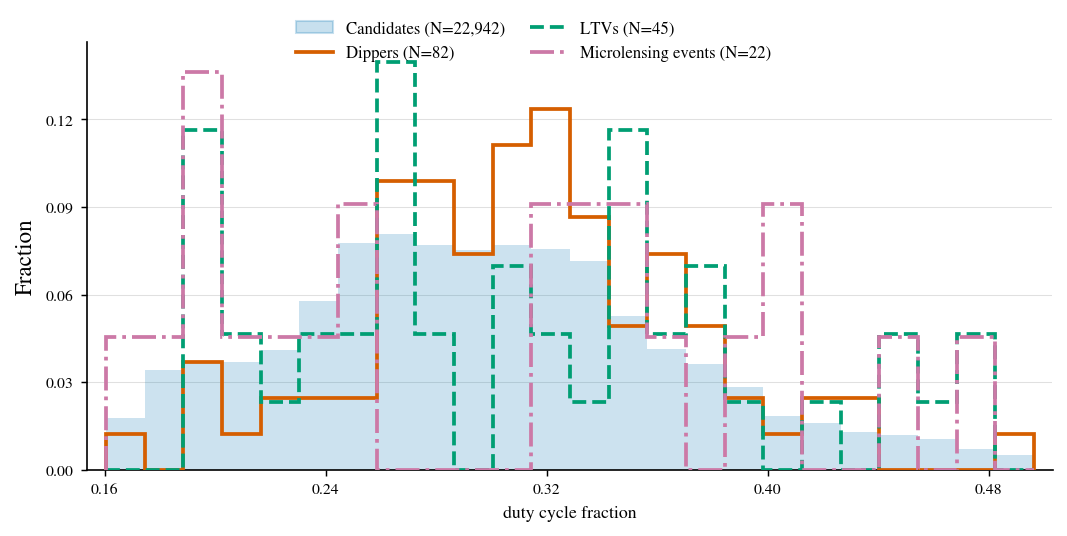

'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


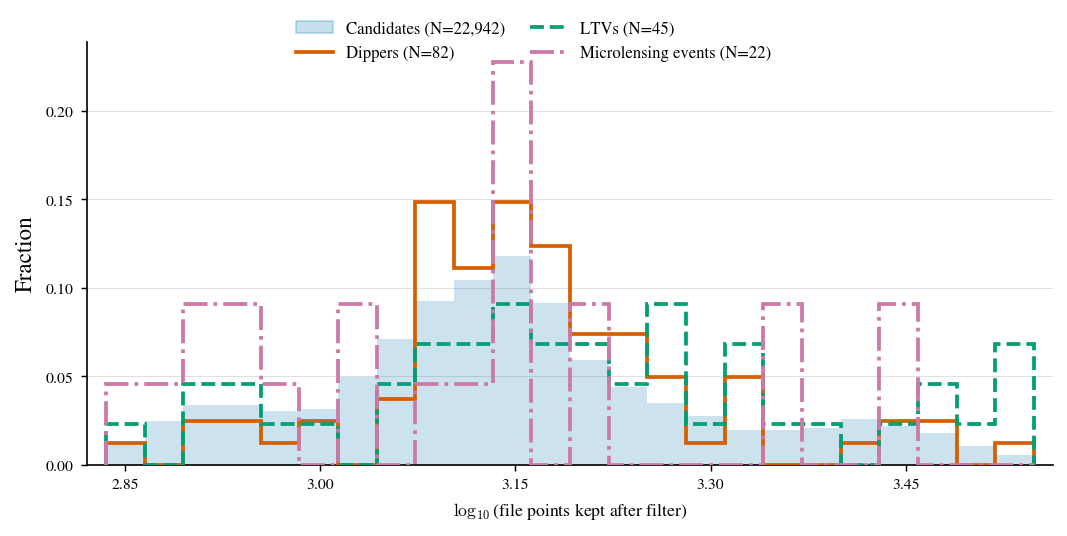

'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


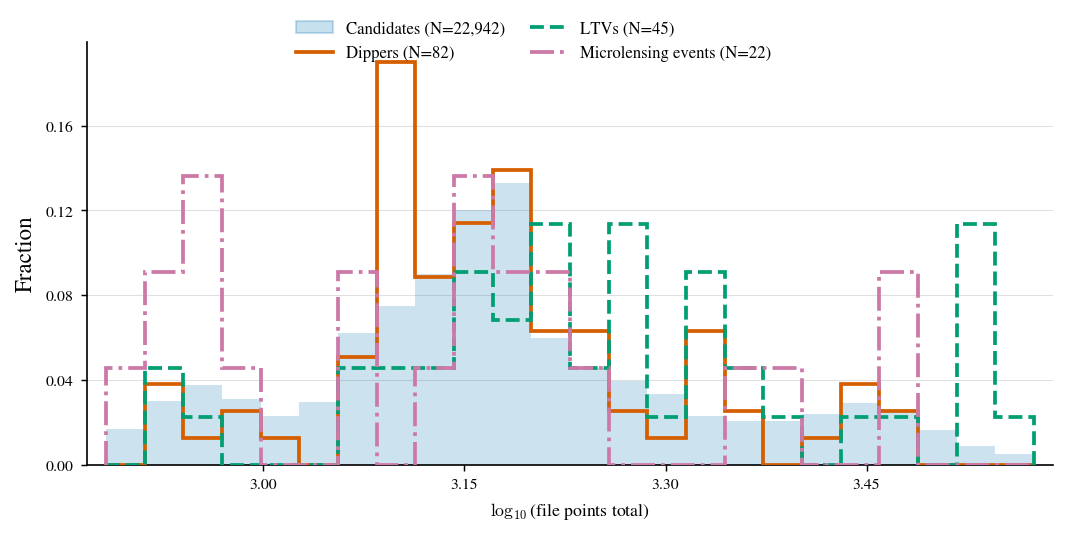

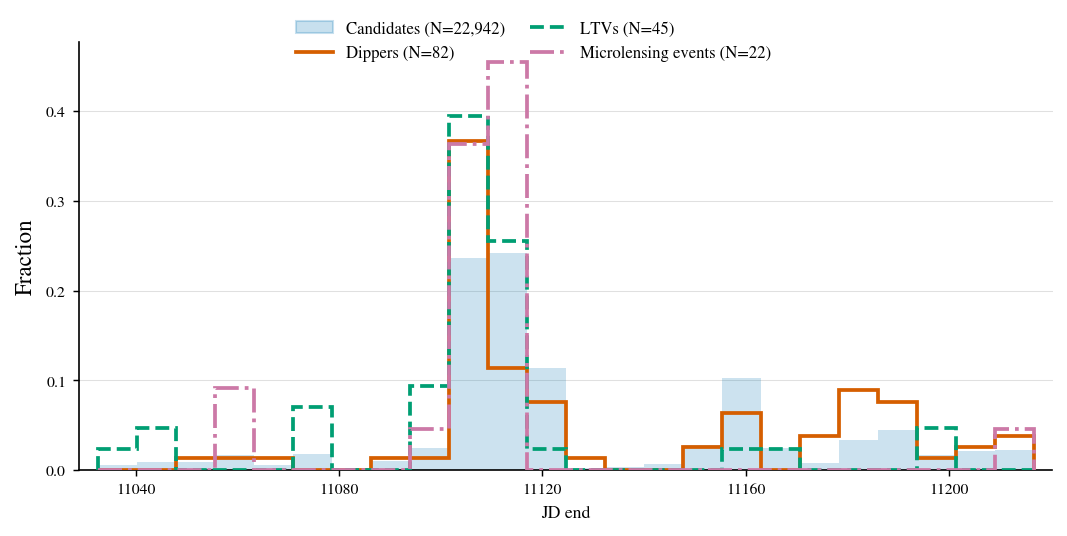

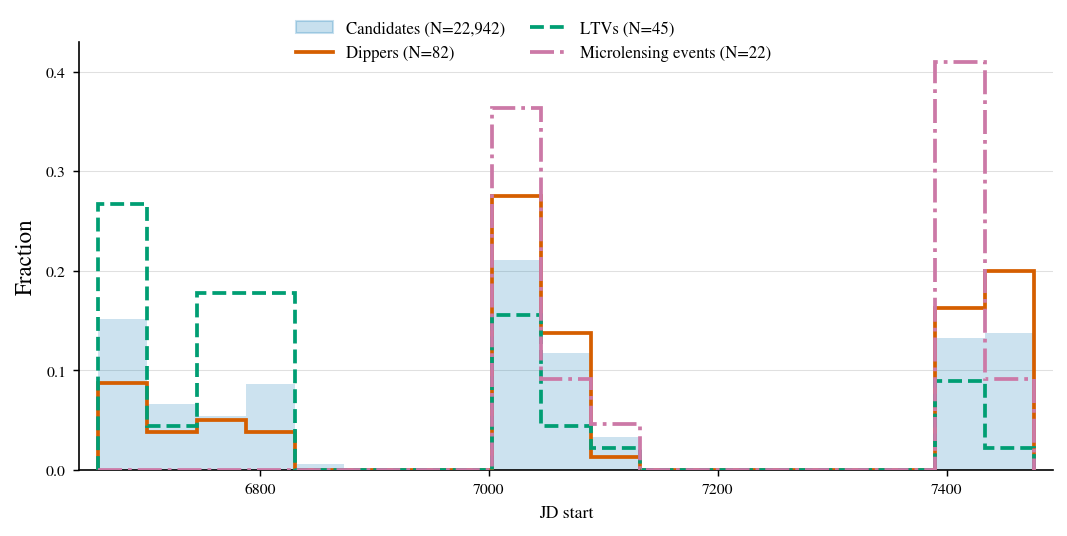

'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


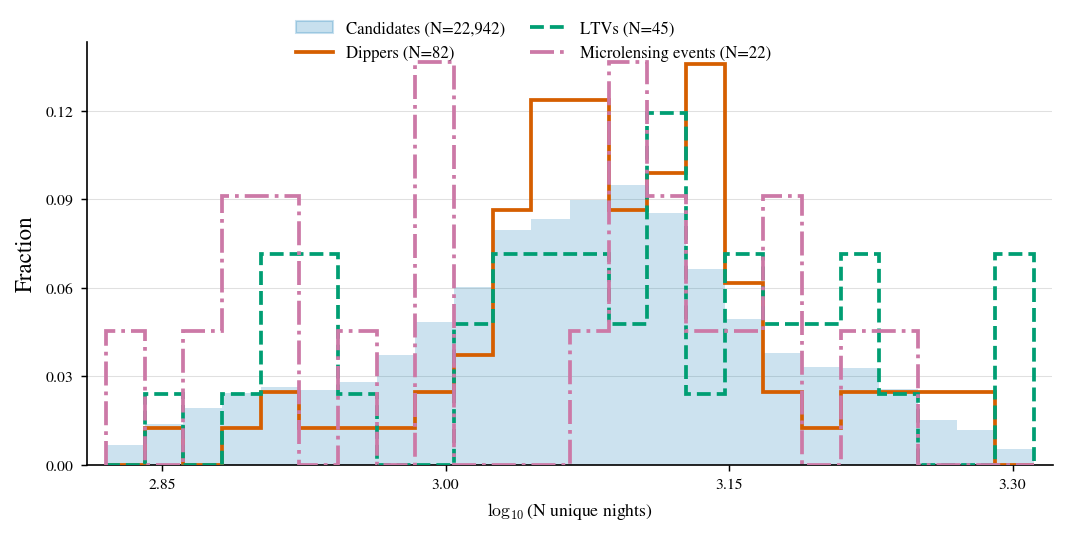

'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


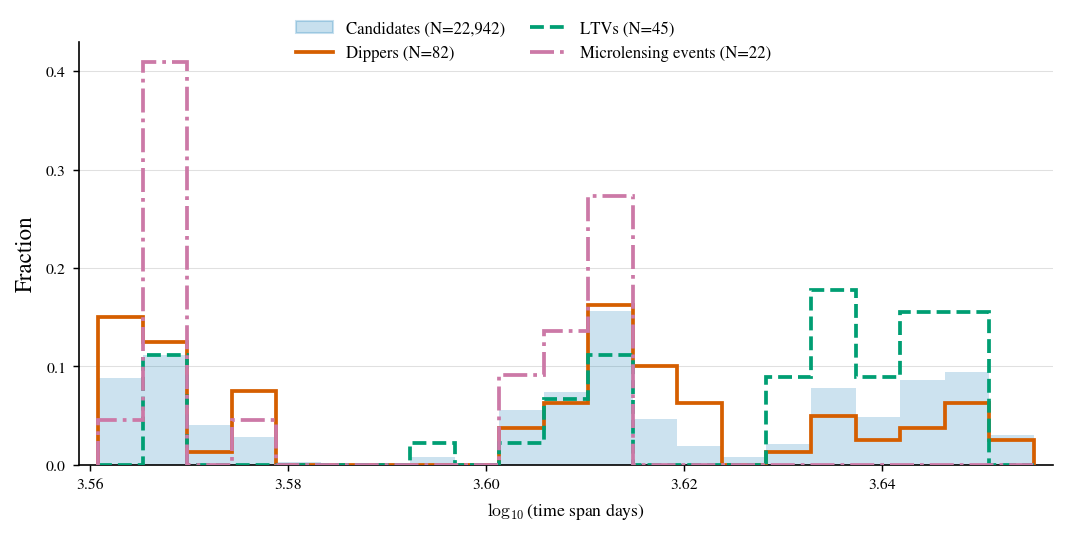

'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


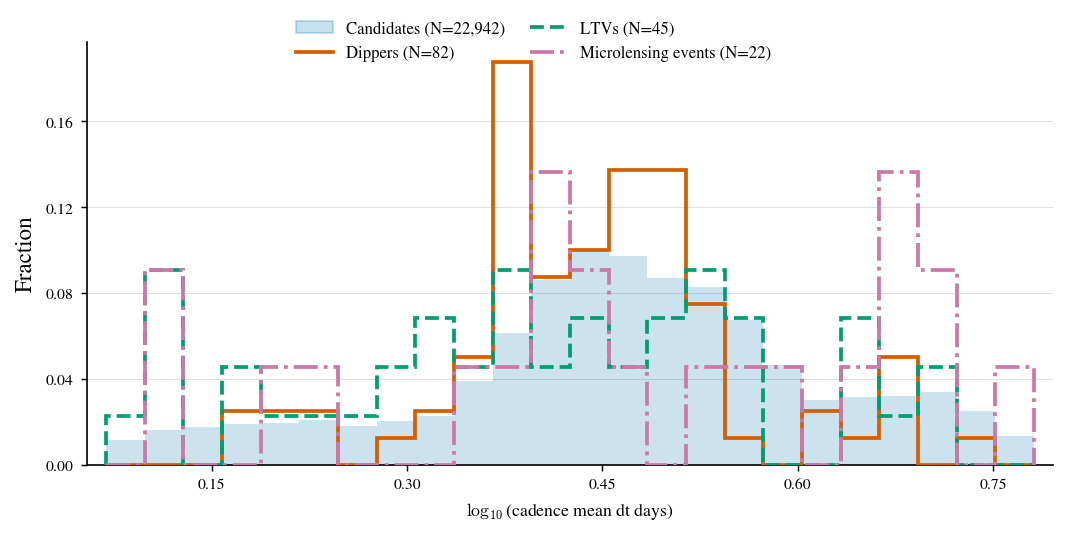

'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


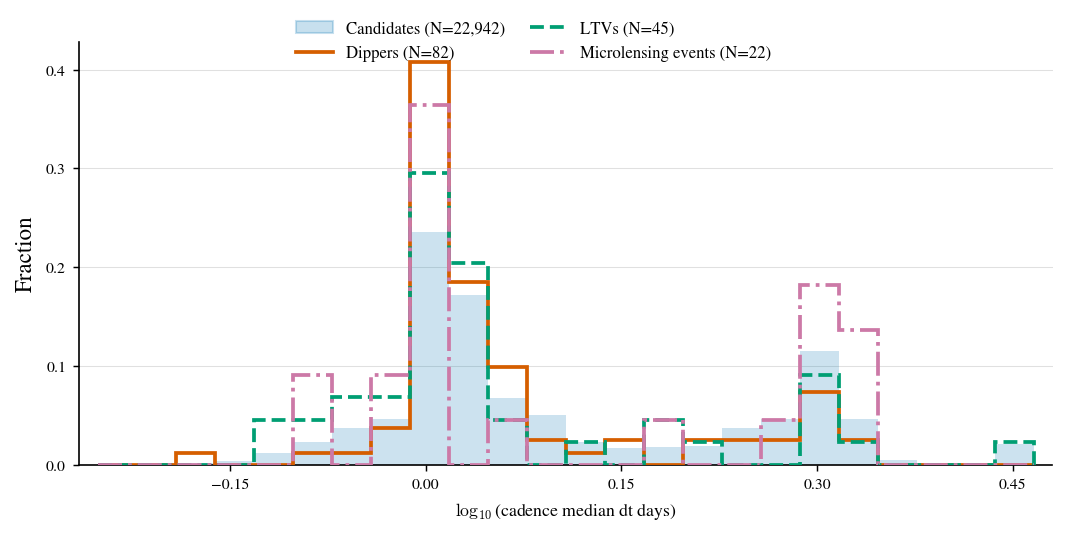

'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


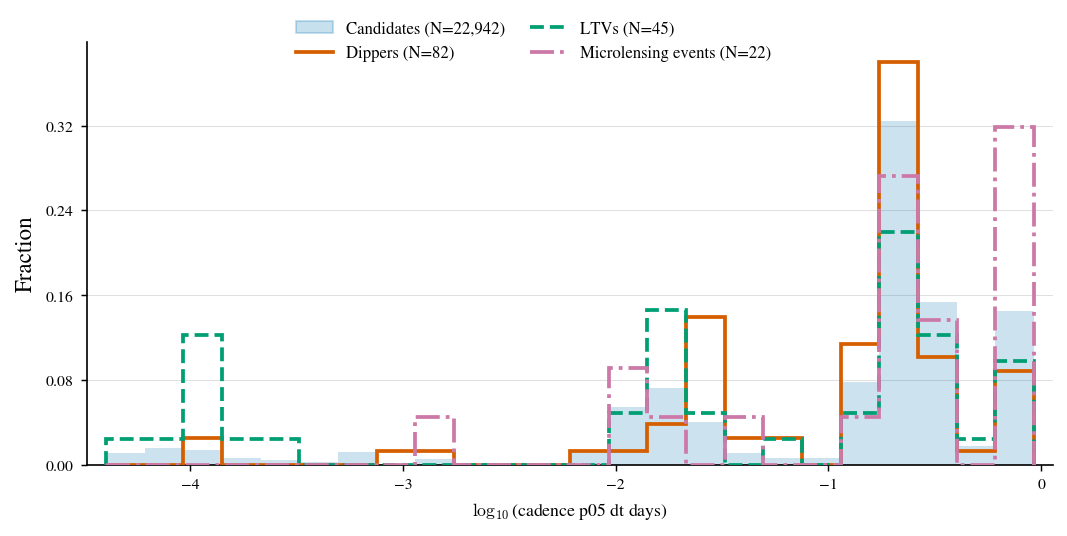

'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


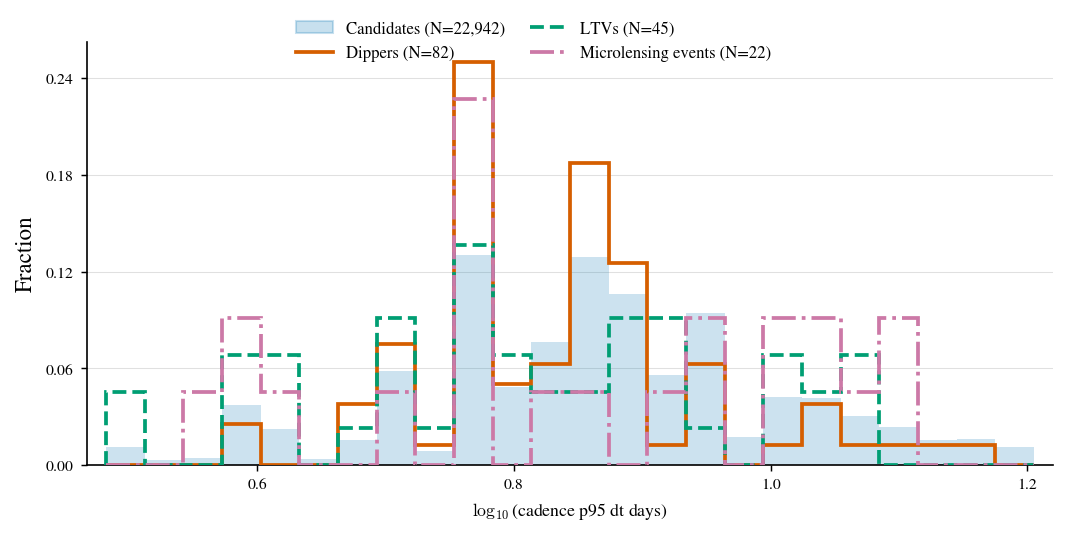

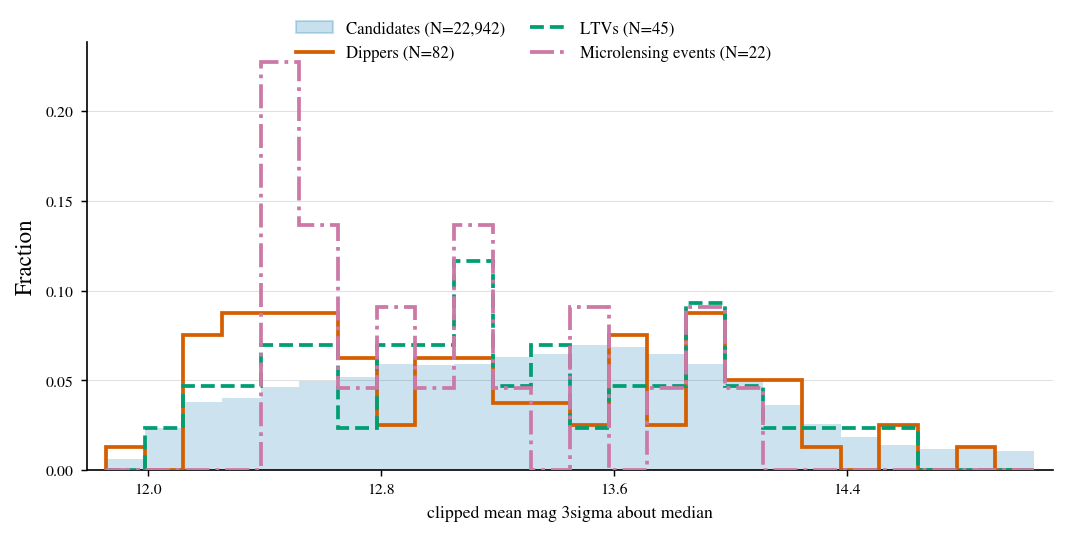

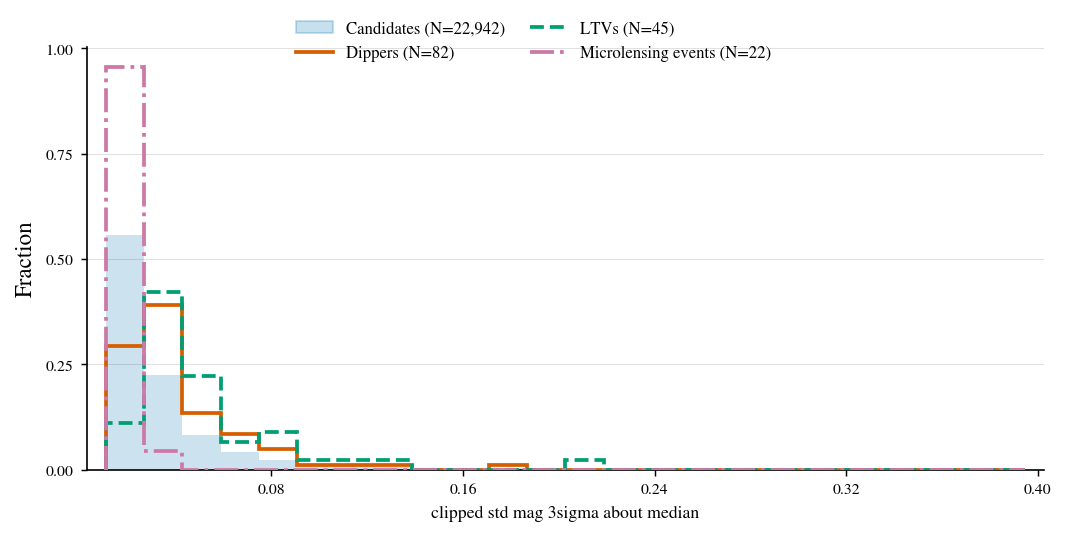

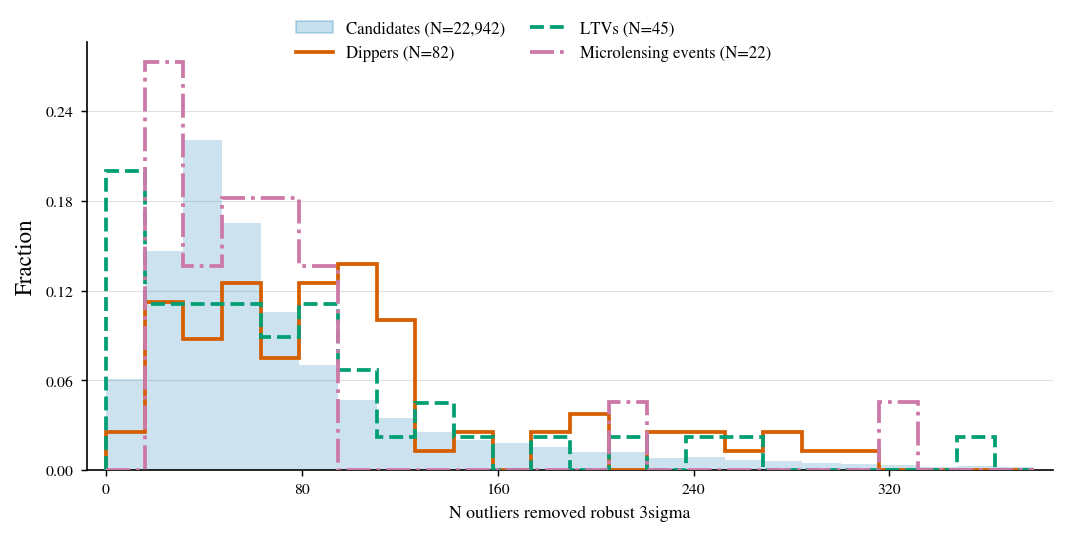

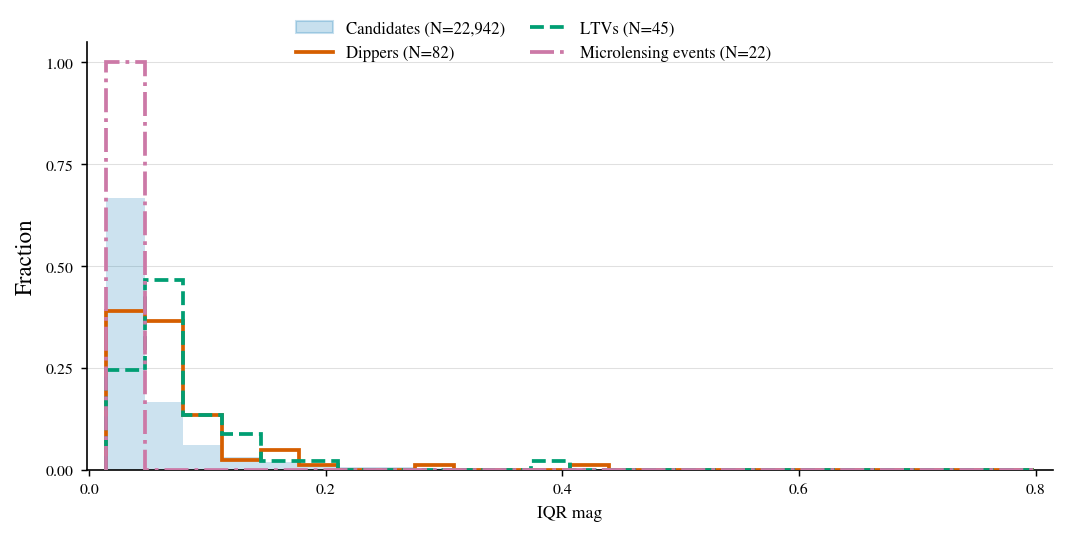

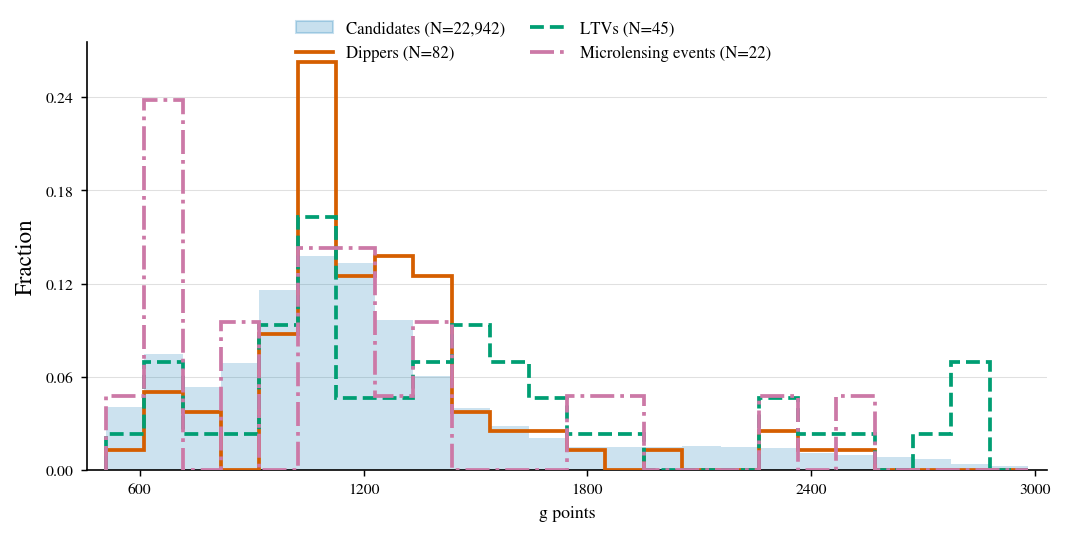

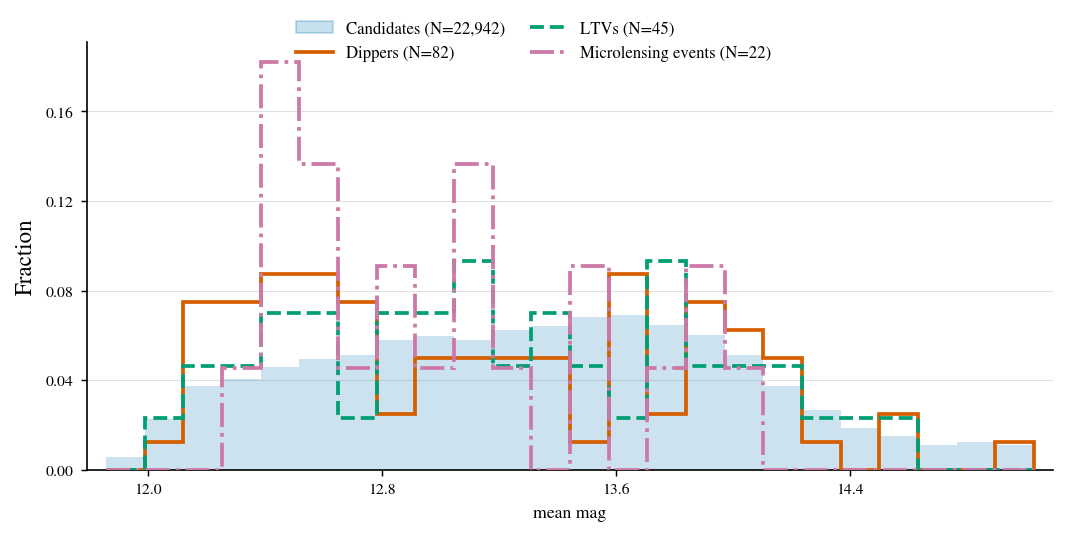

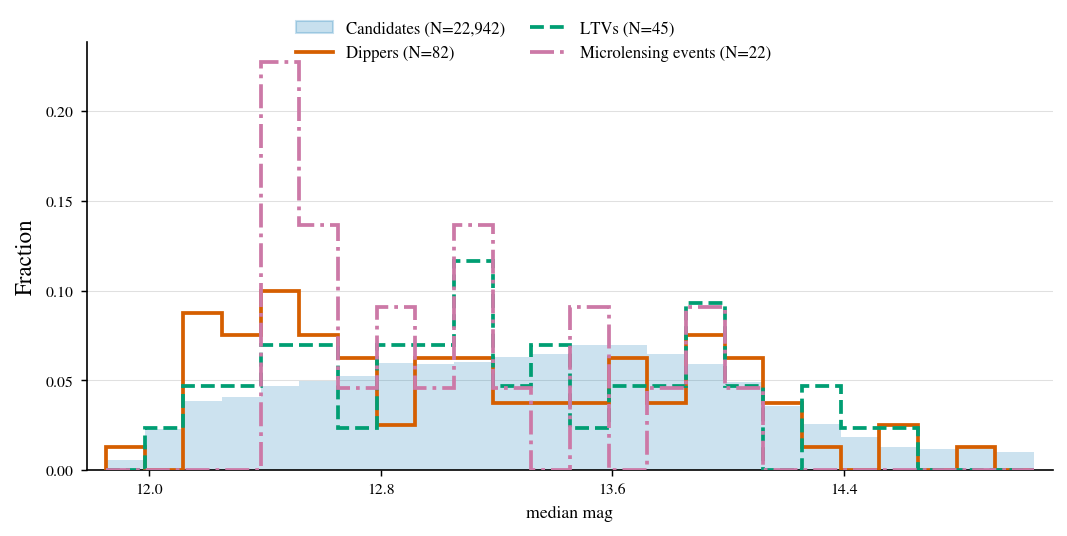

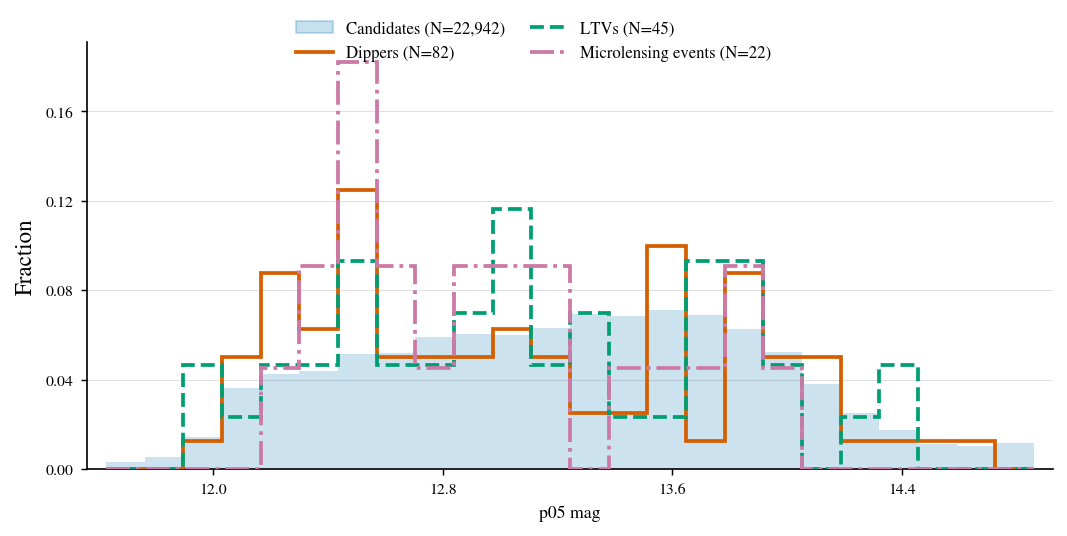

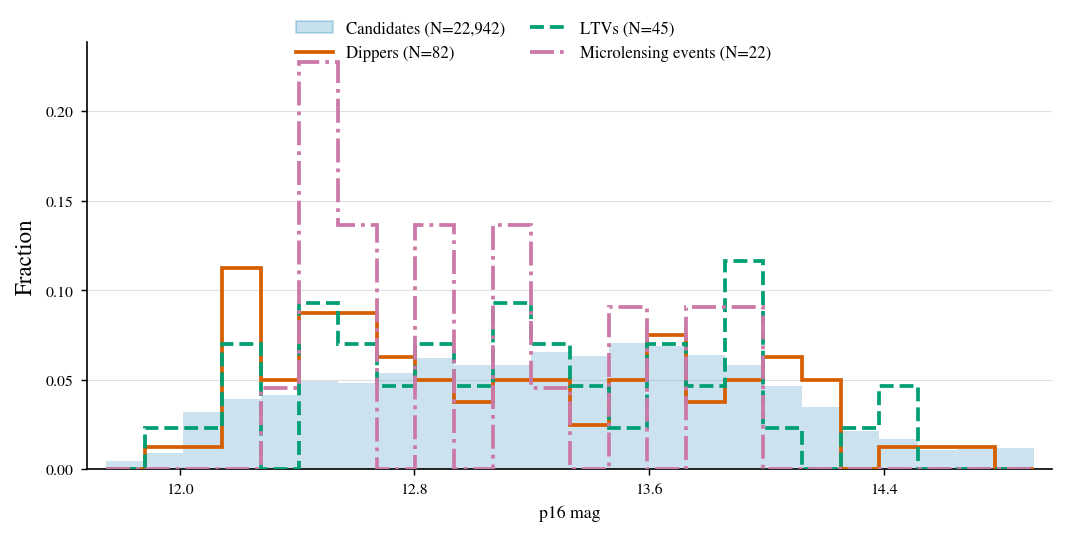

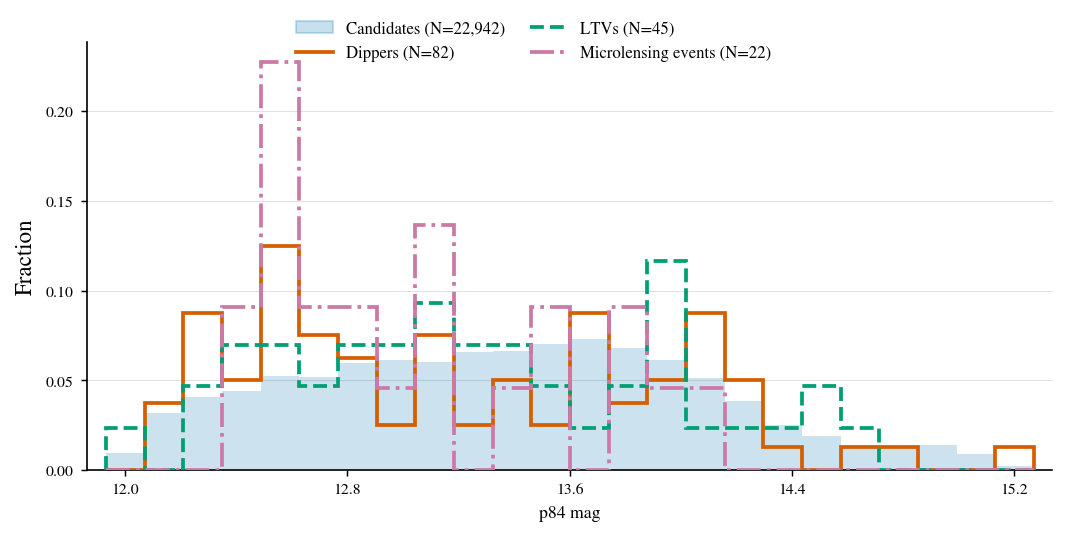

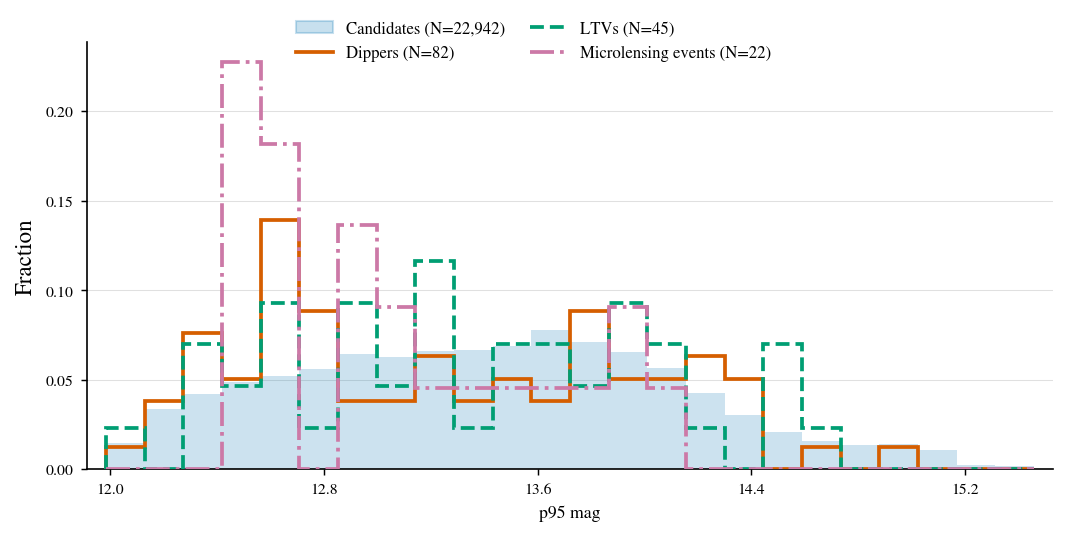

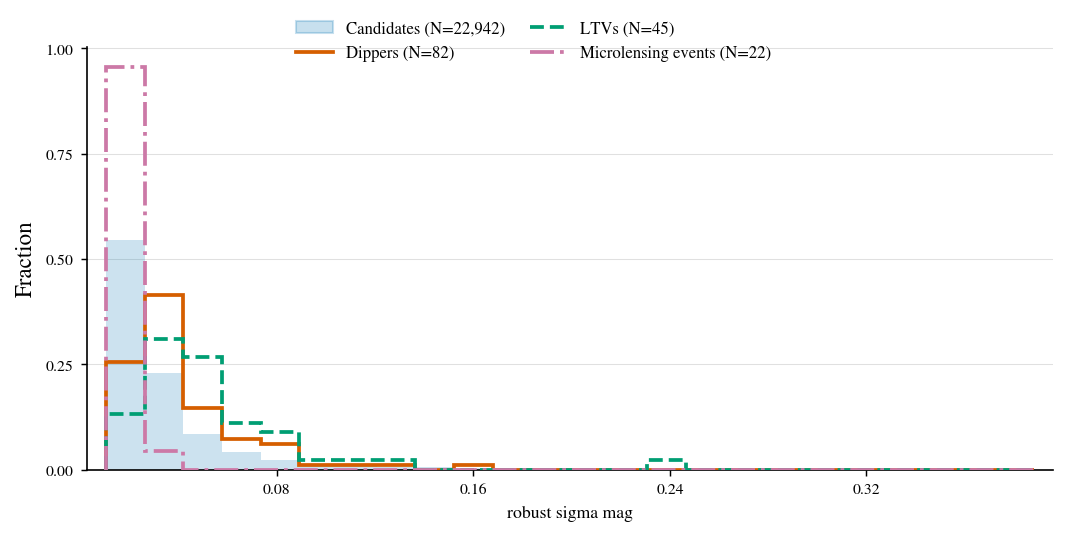

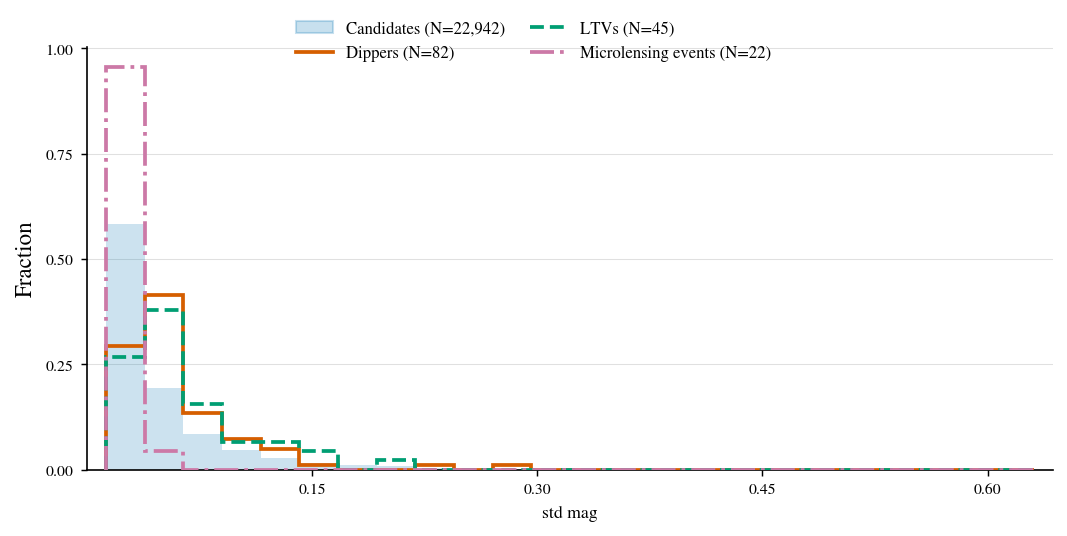

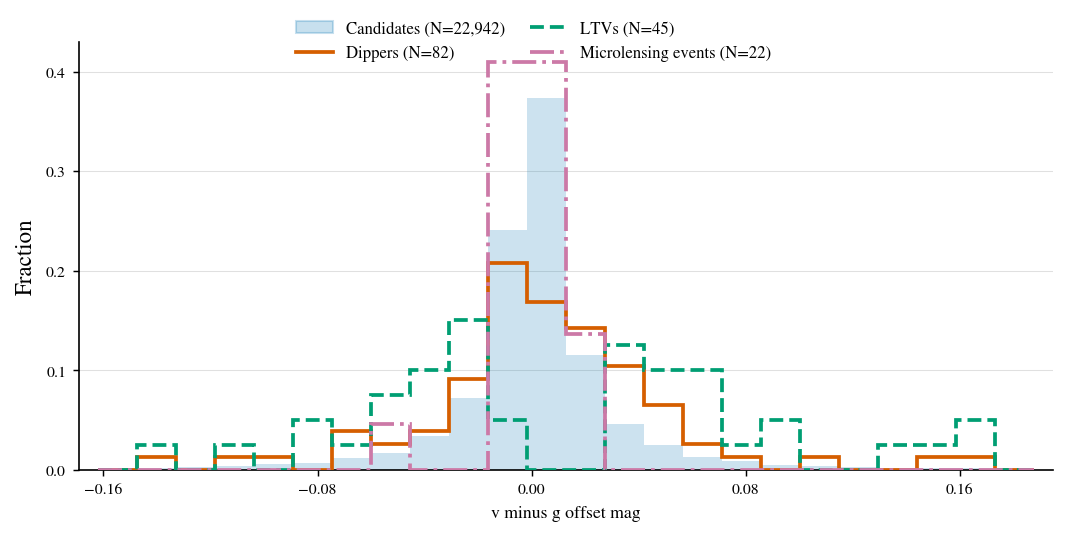

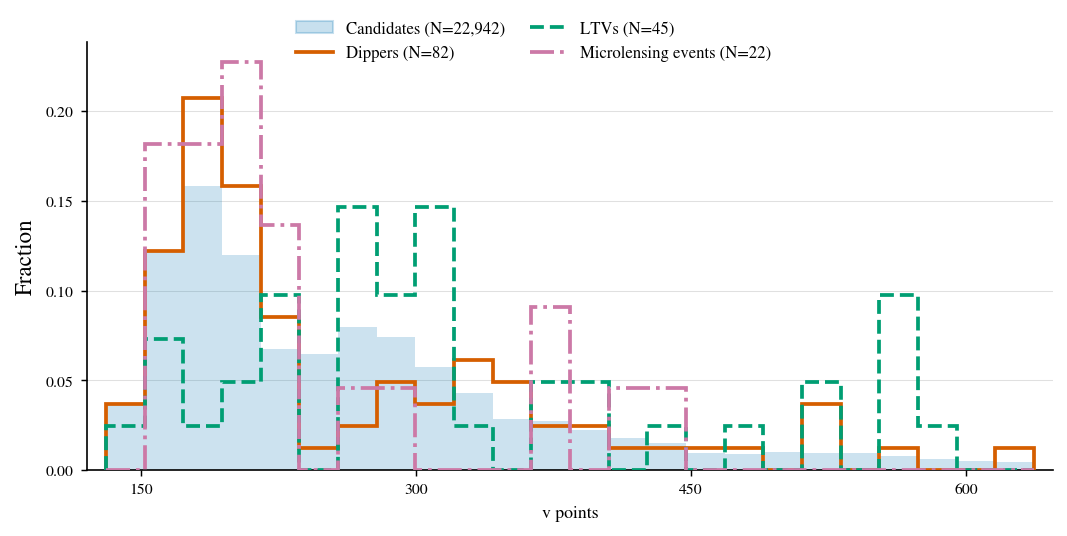

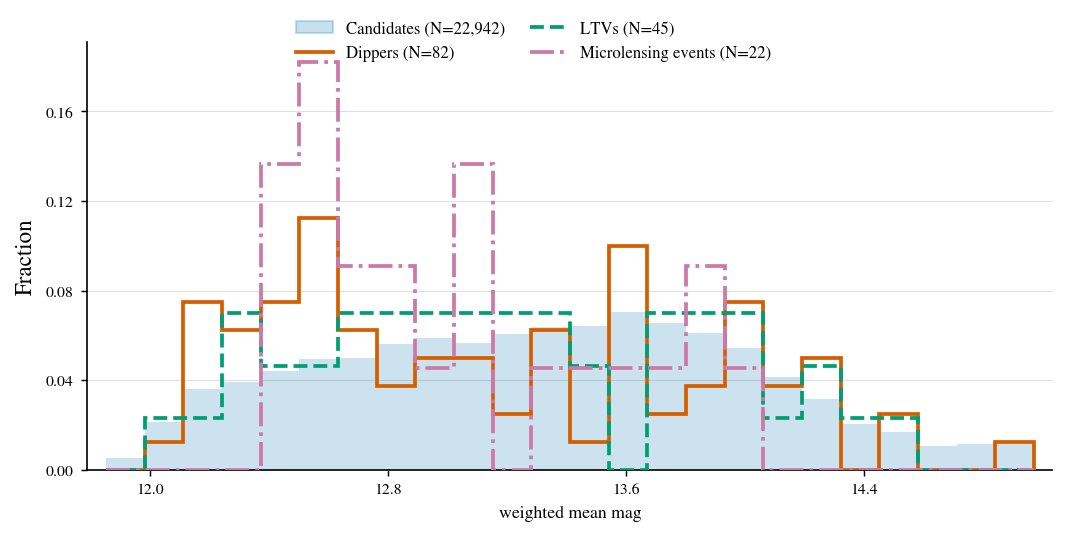

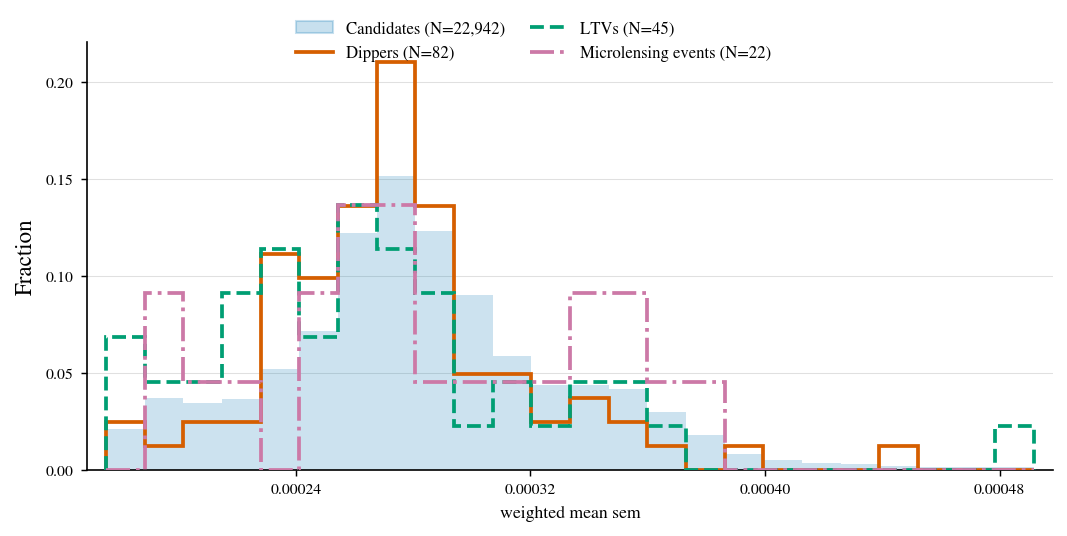

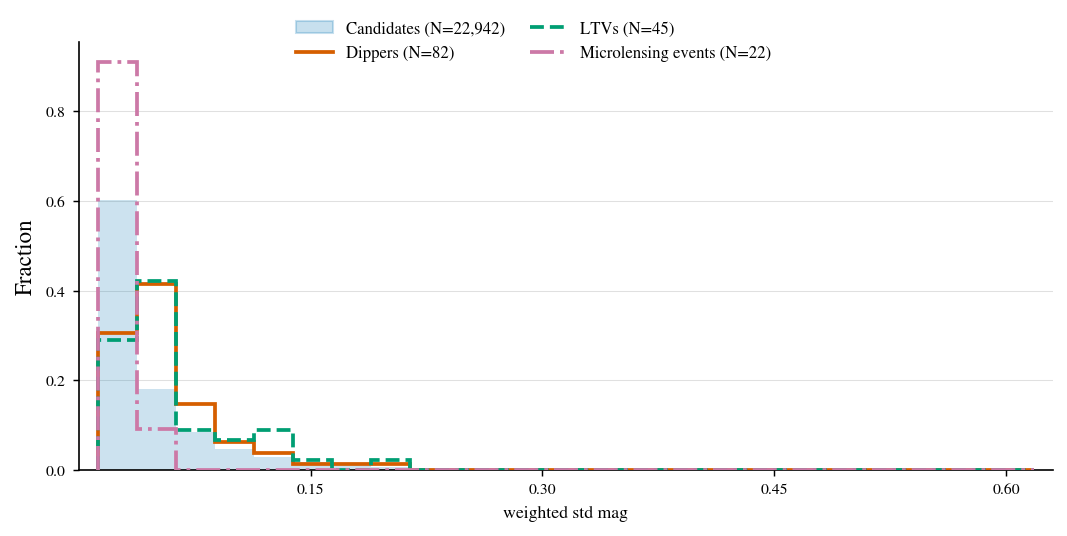

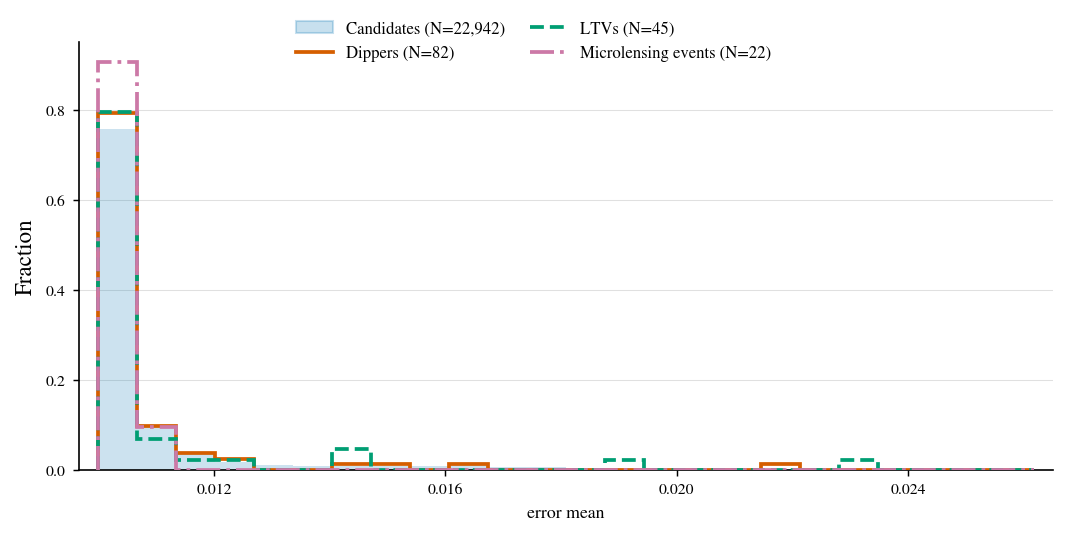

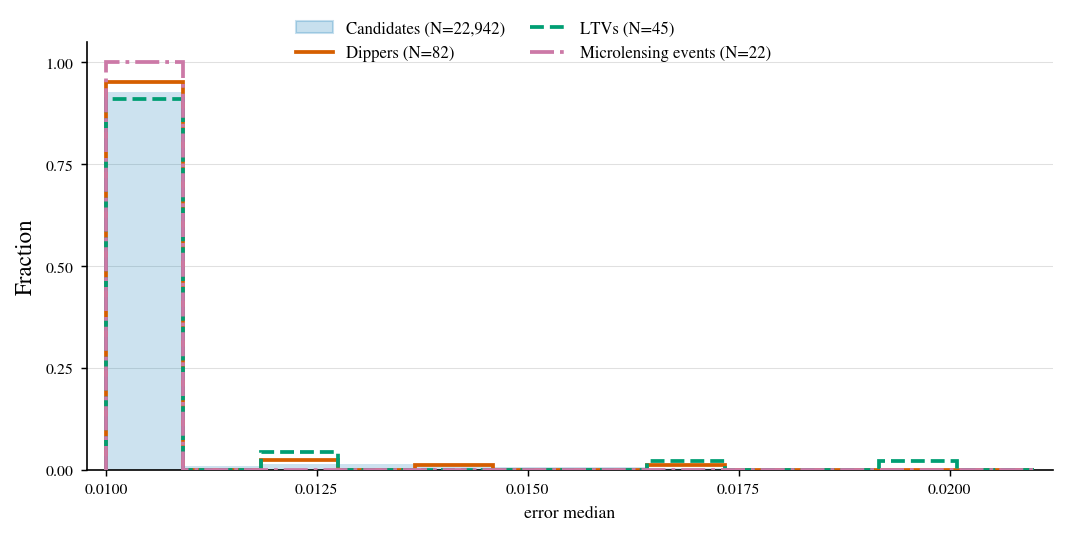

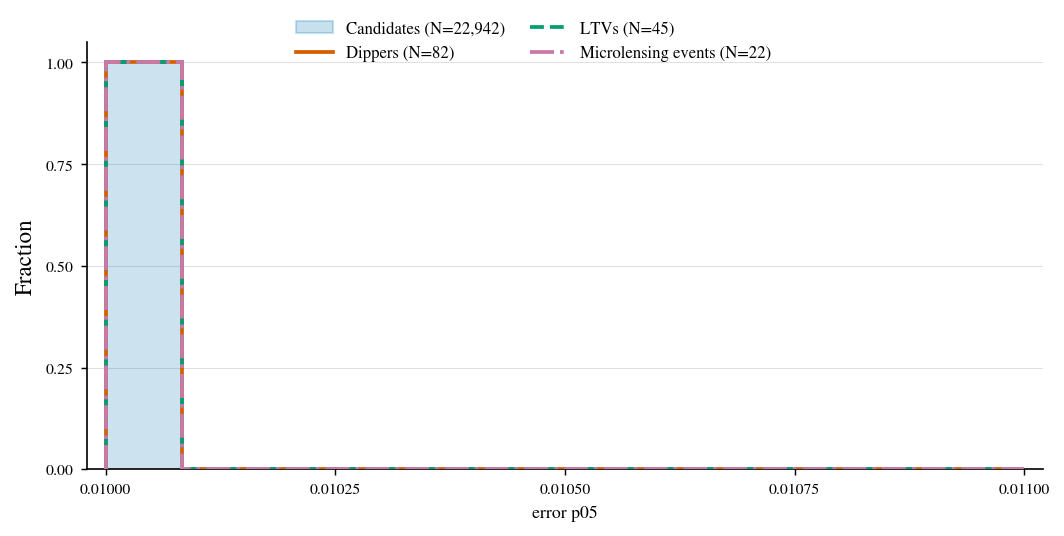

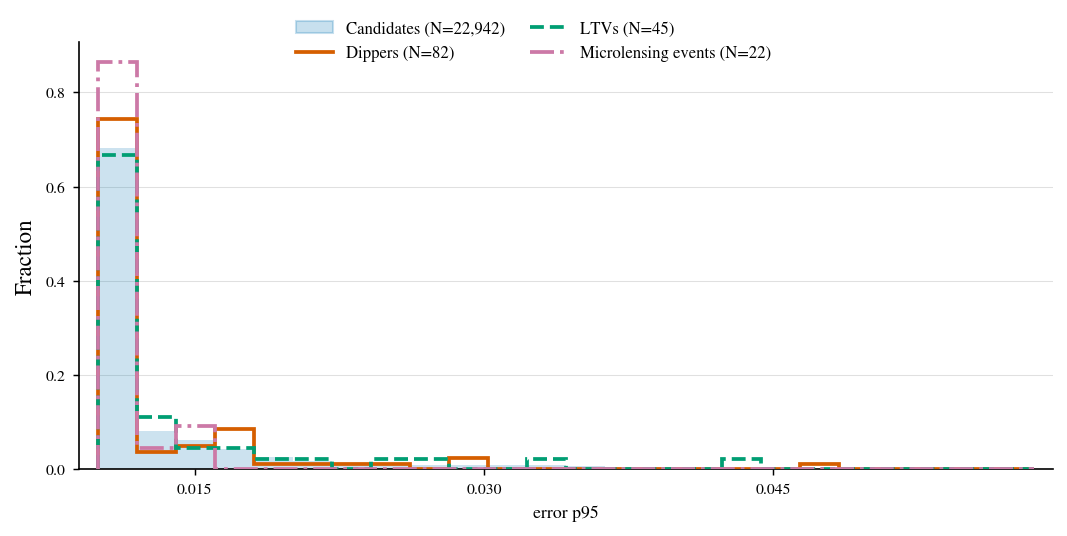

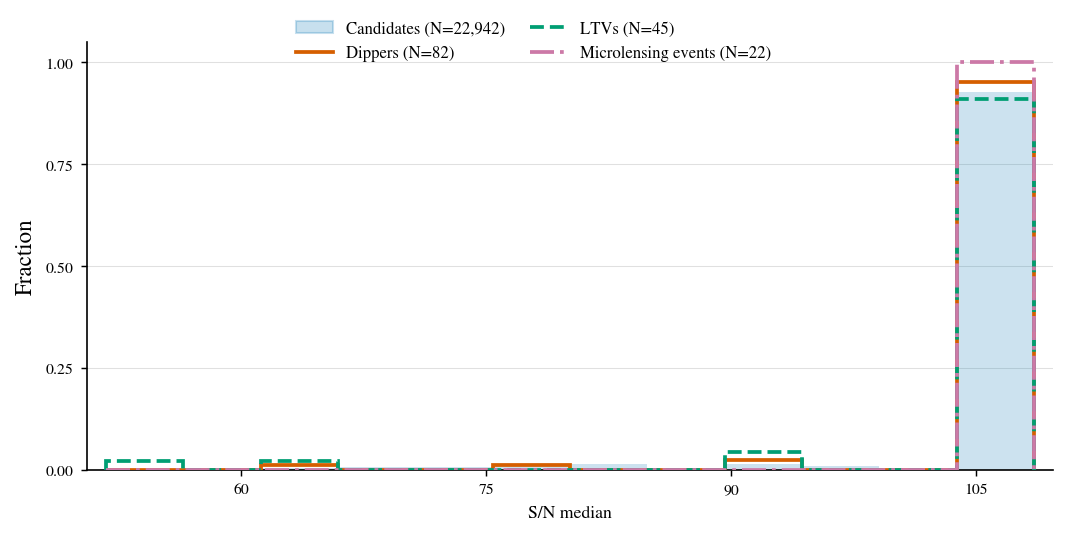

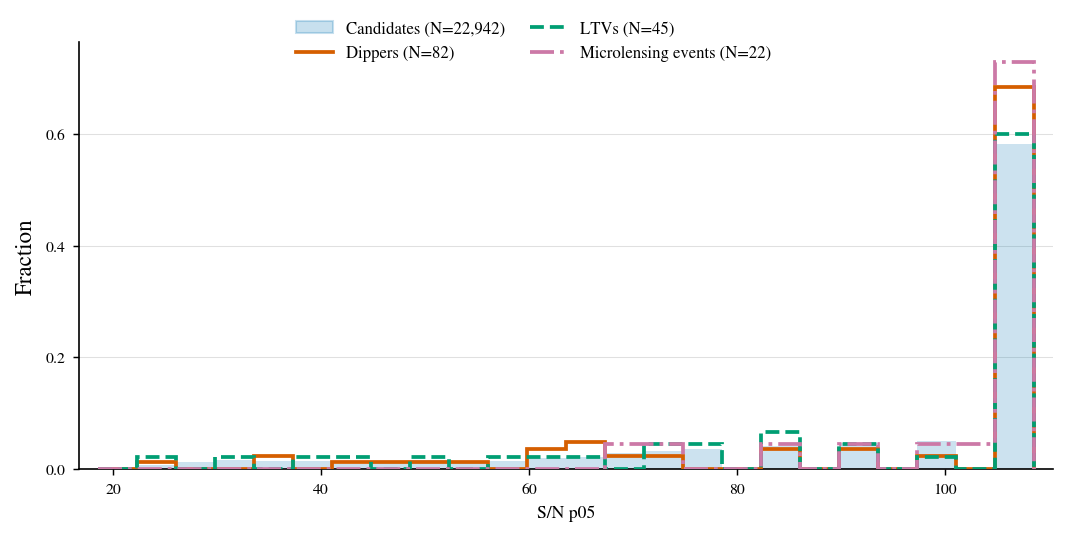

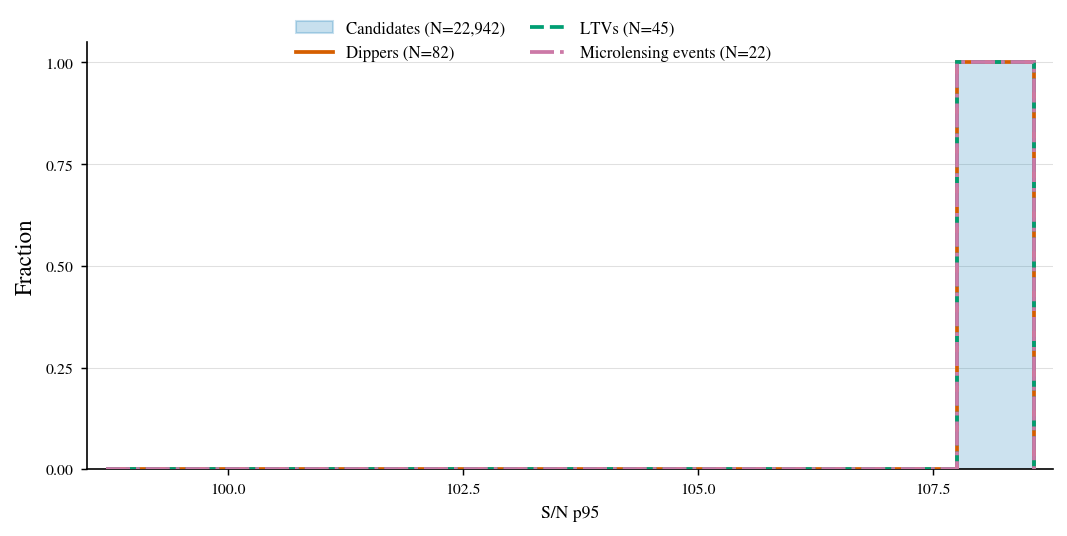

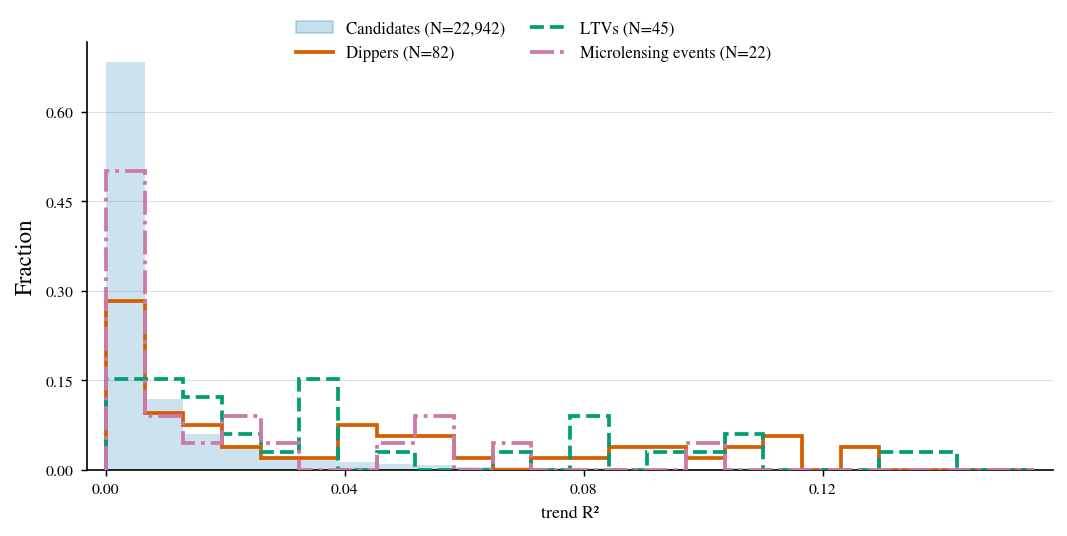

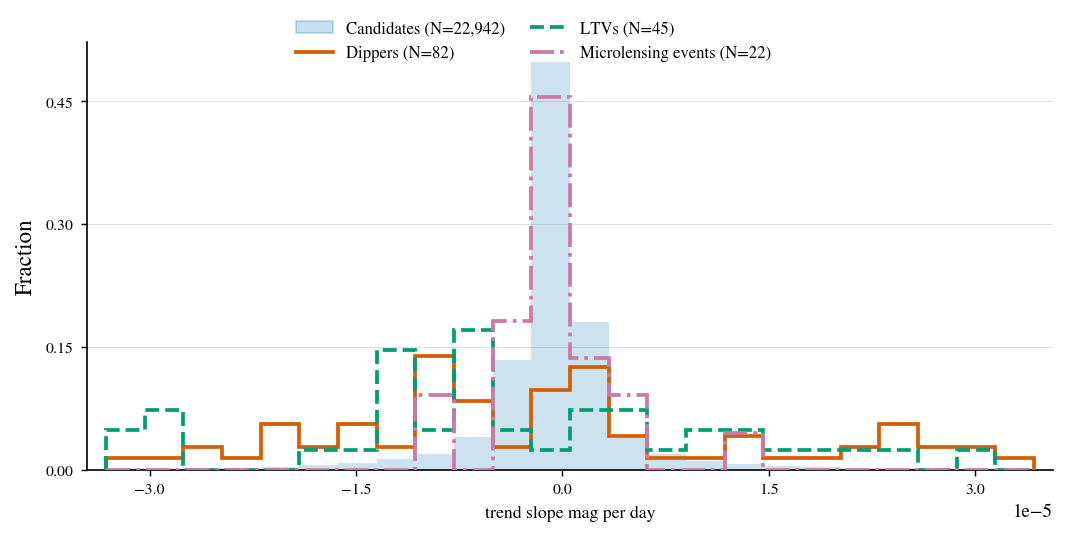

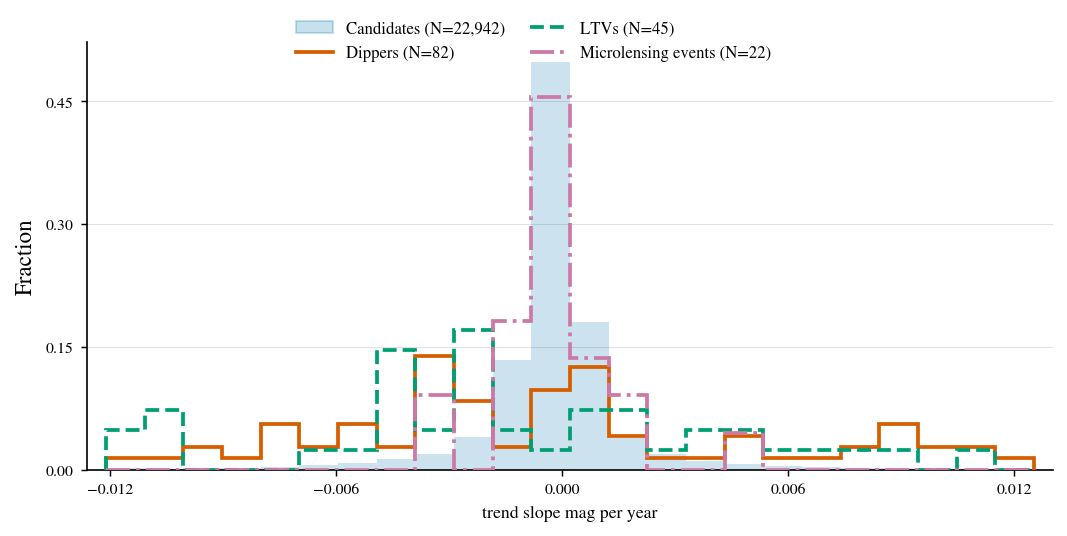

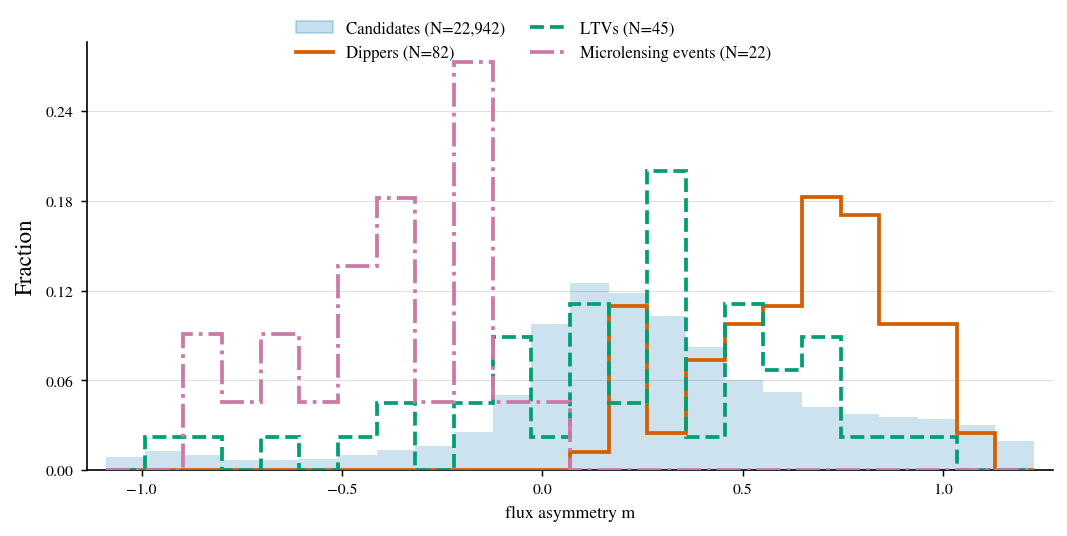

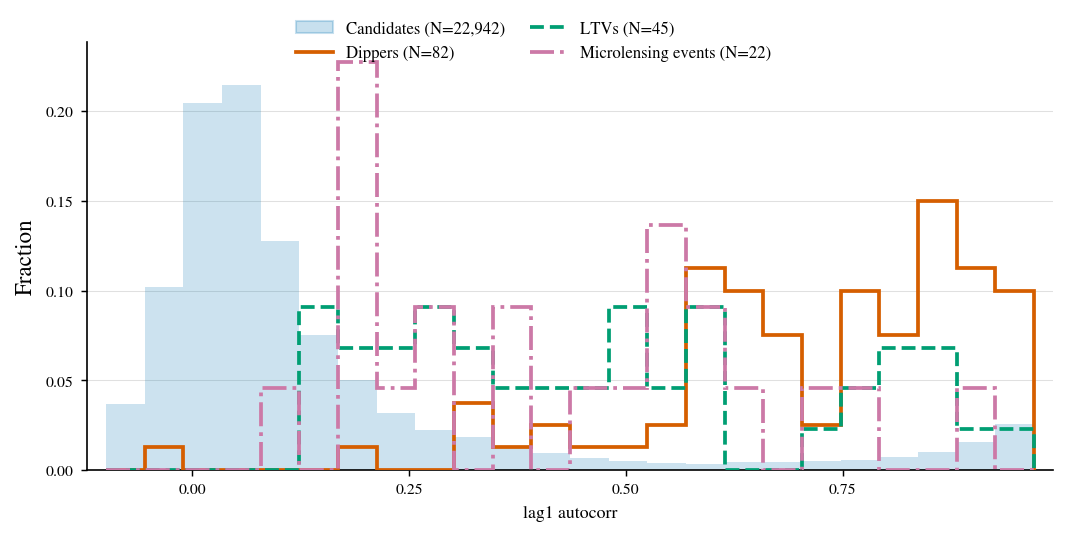

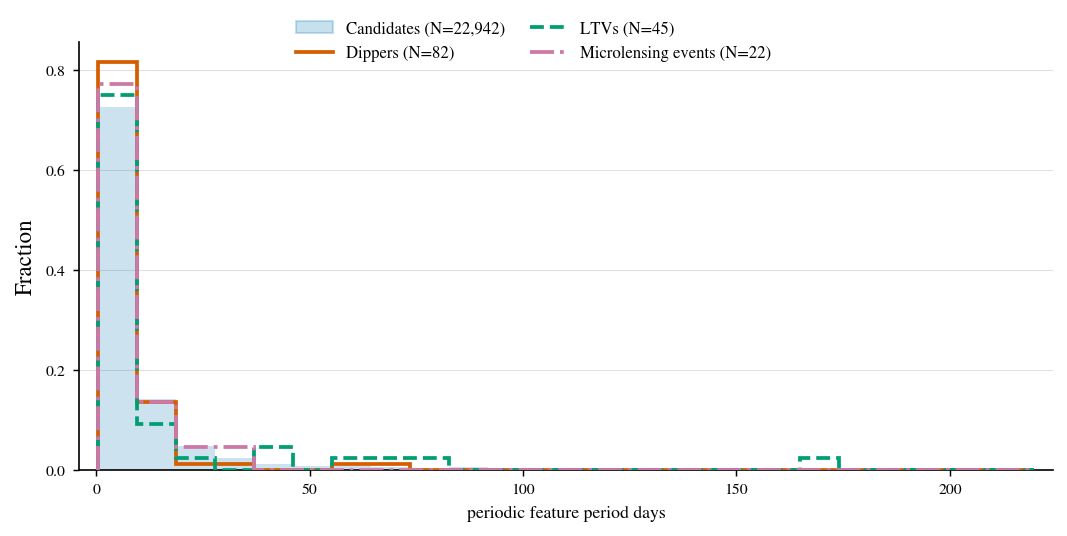

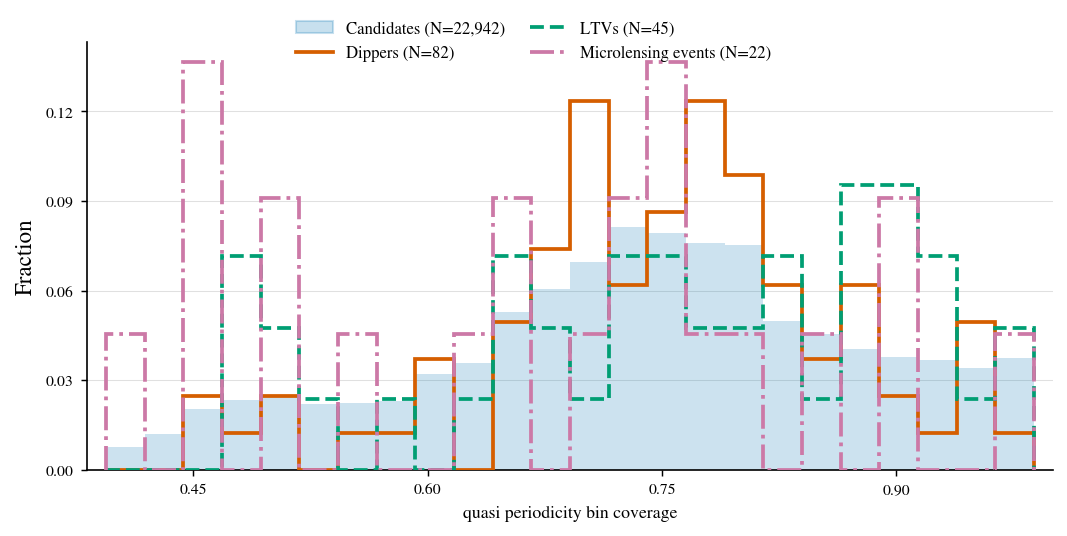

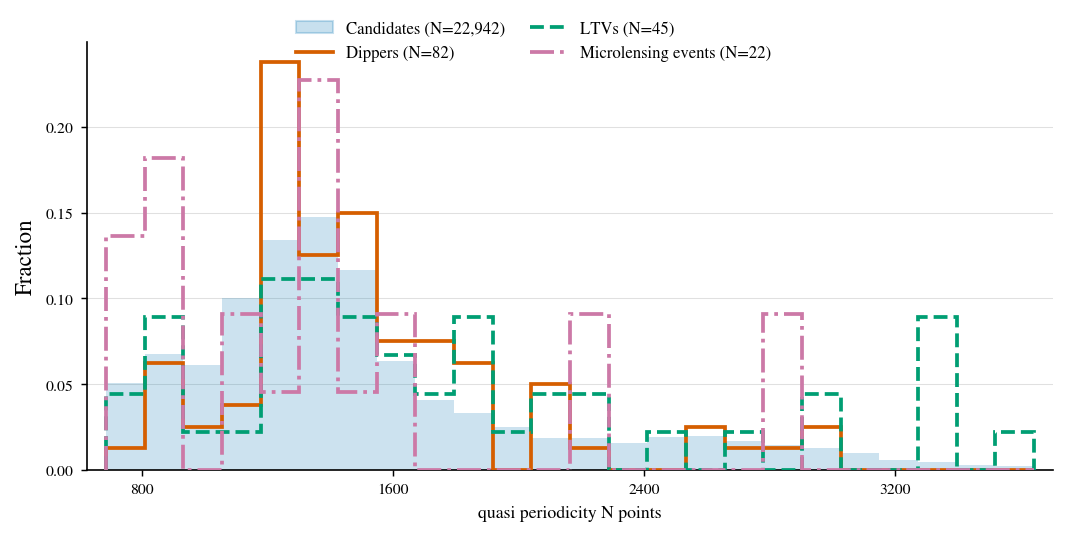

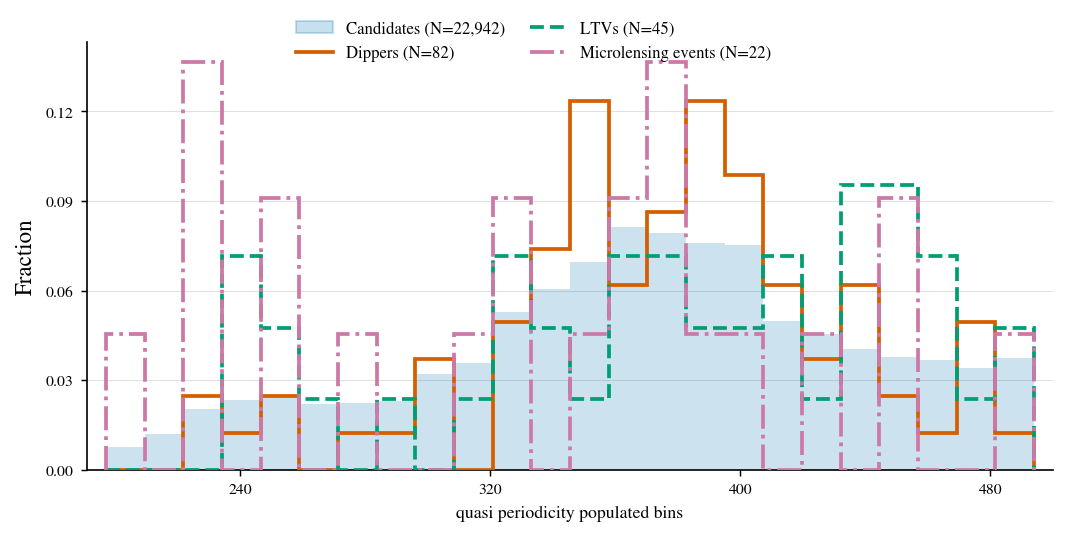

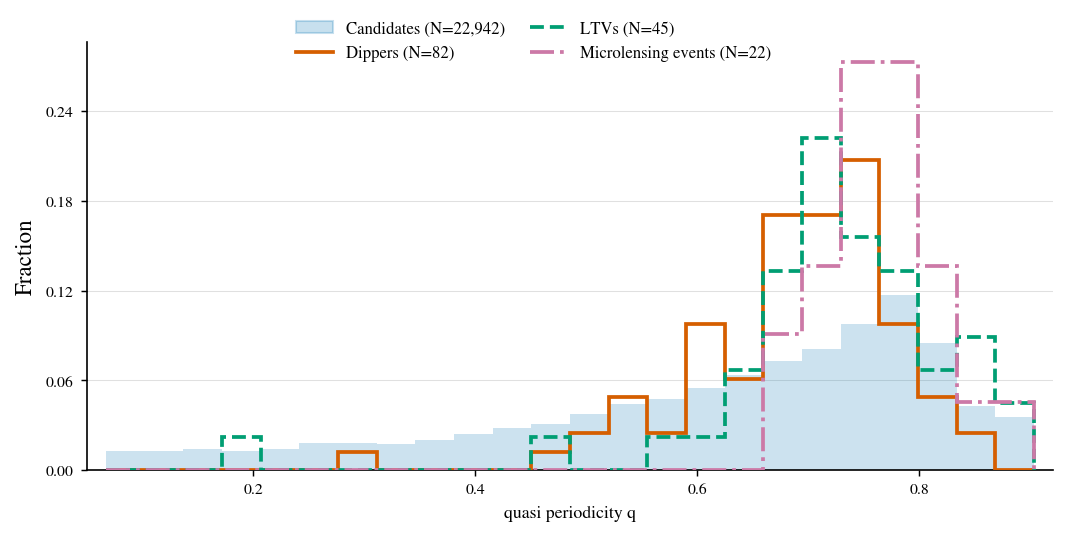

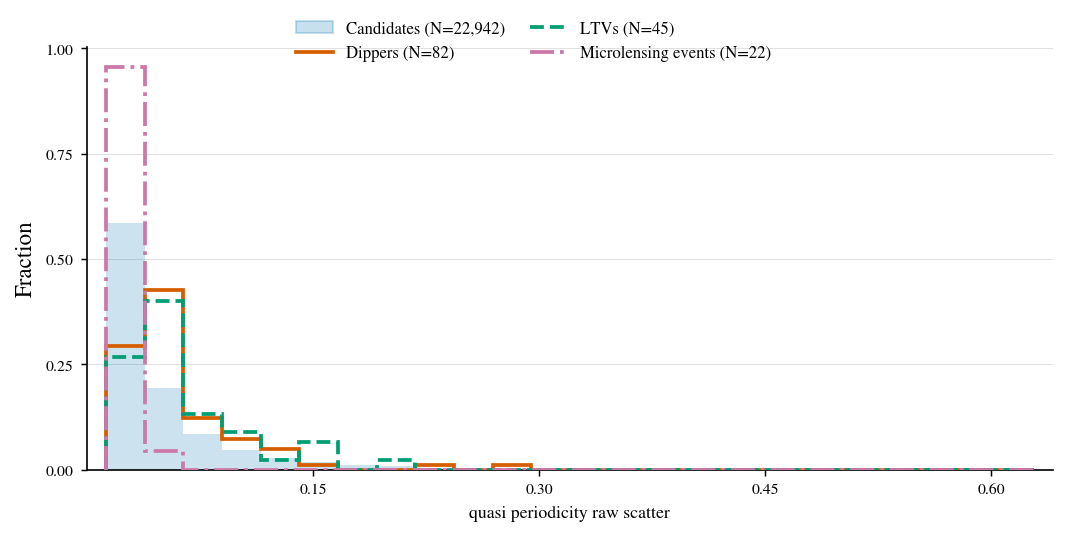

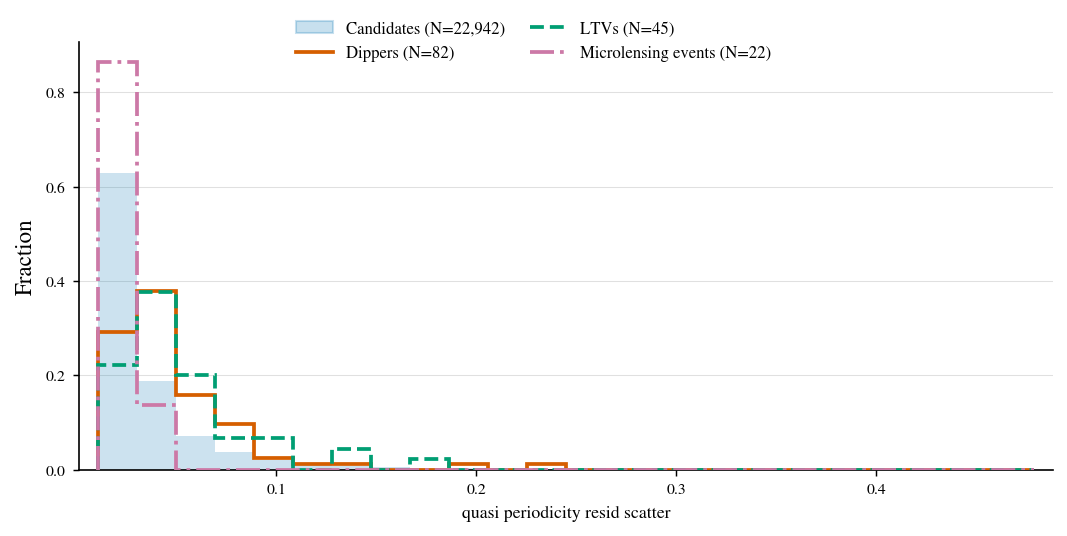

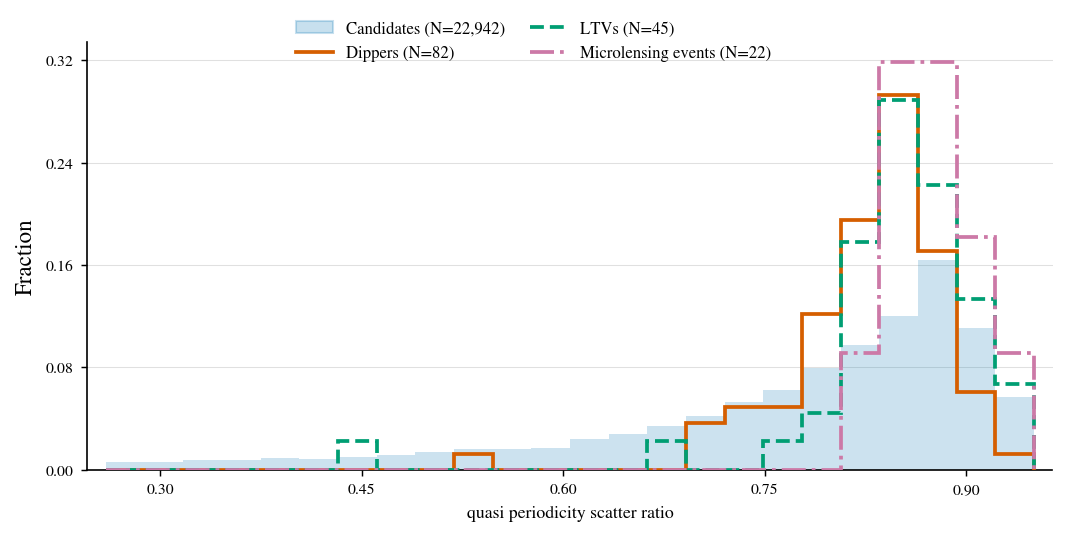

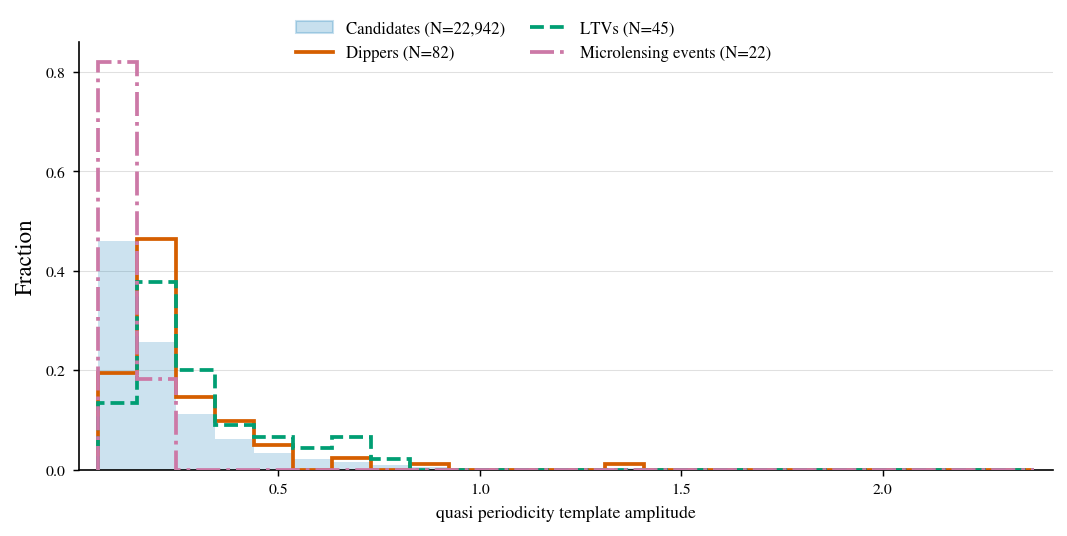

'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


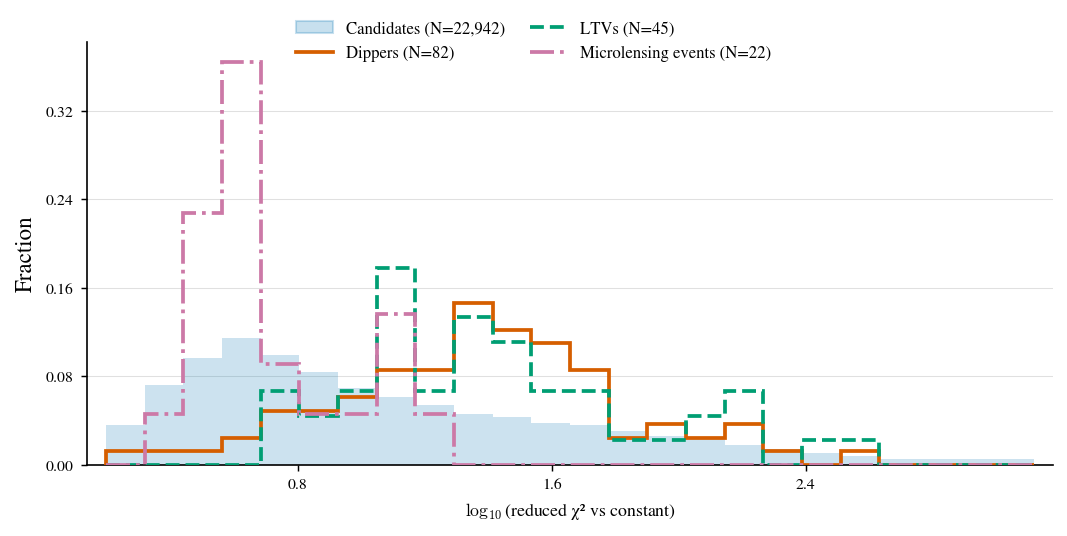

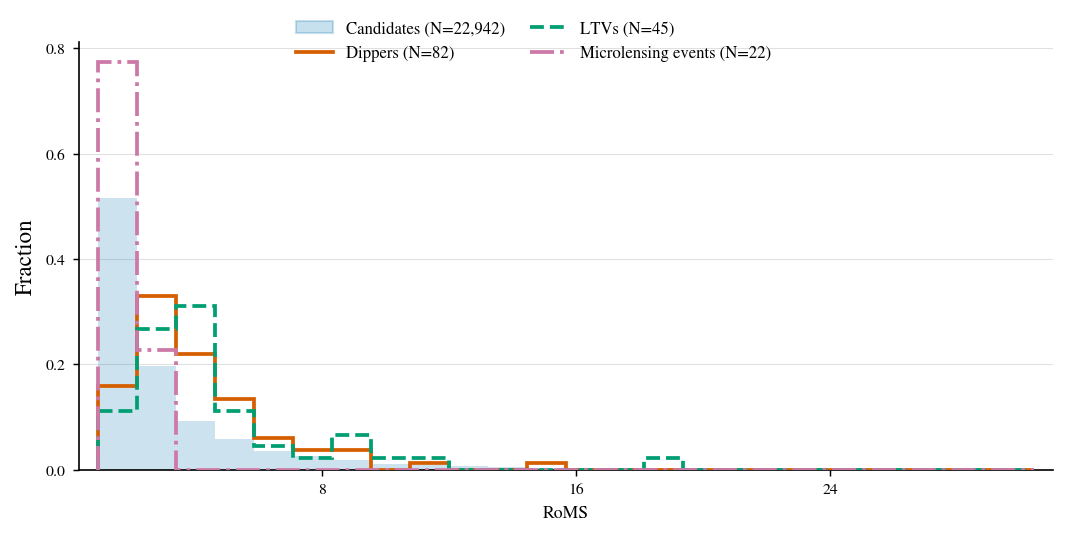

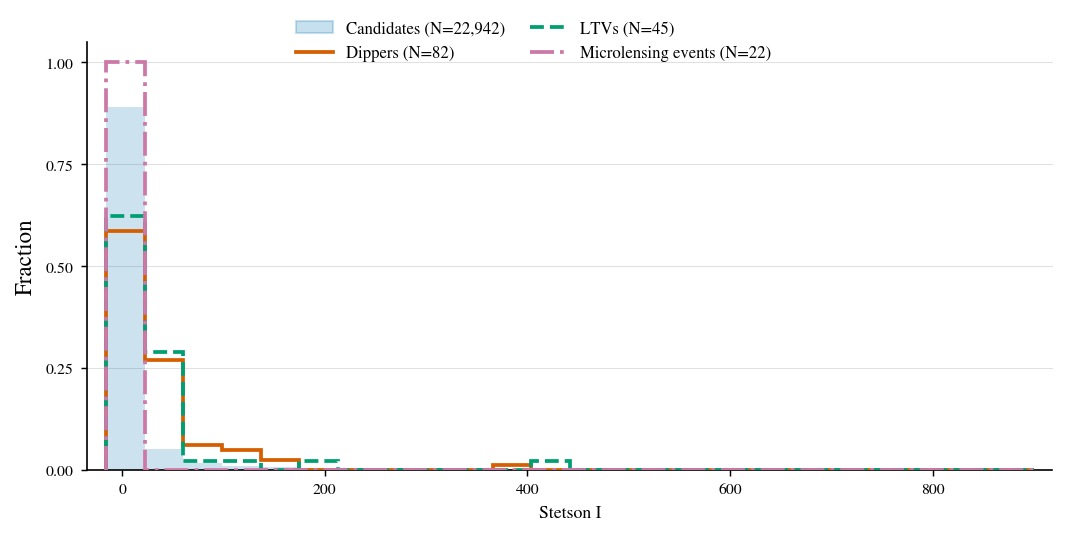

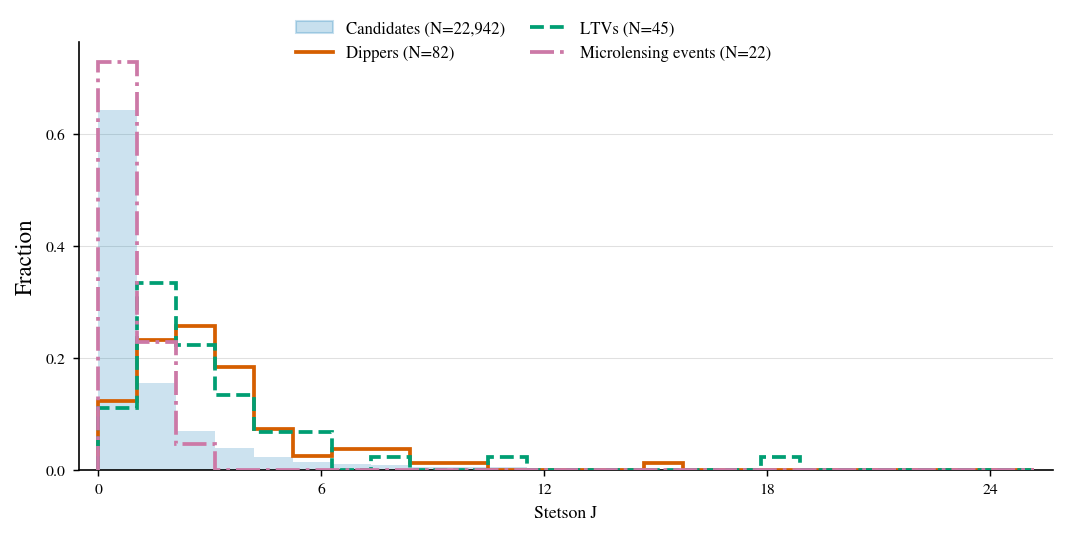

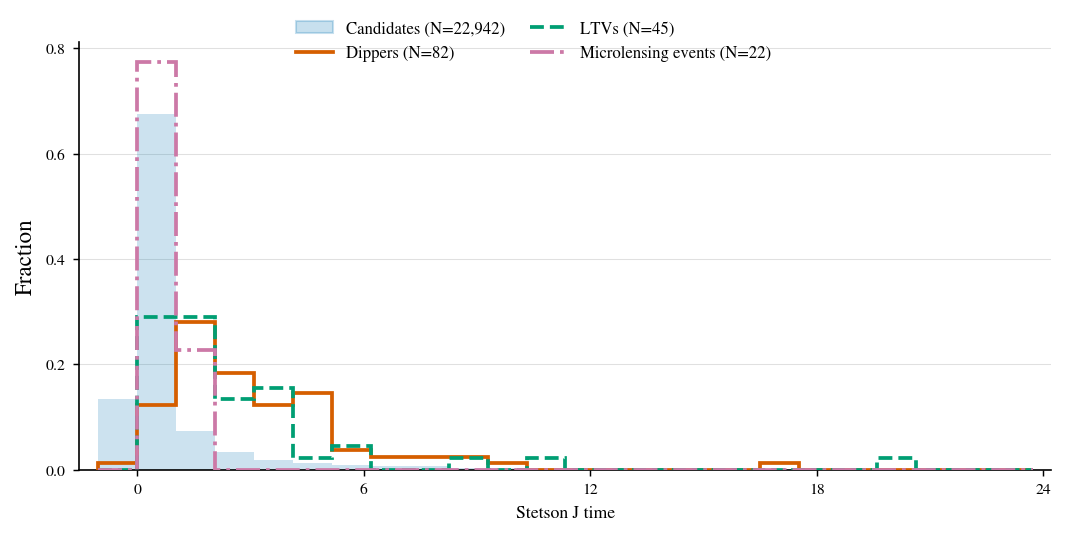

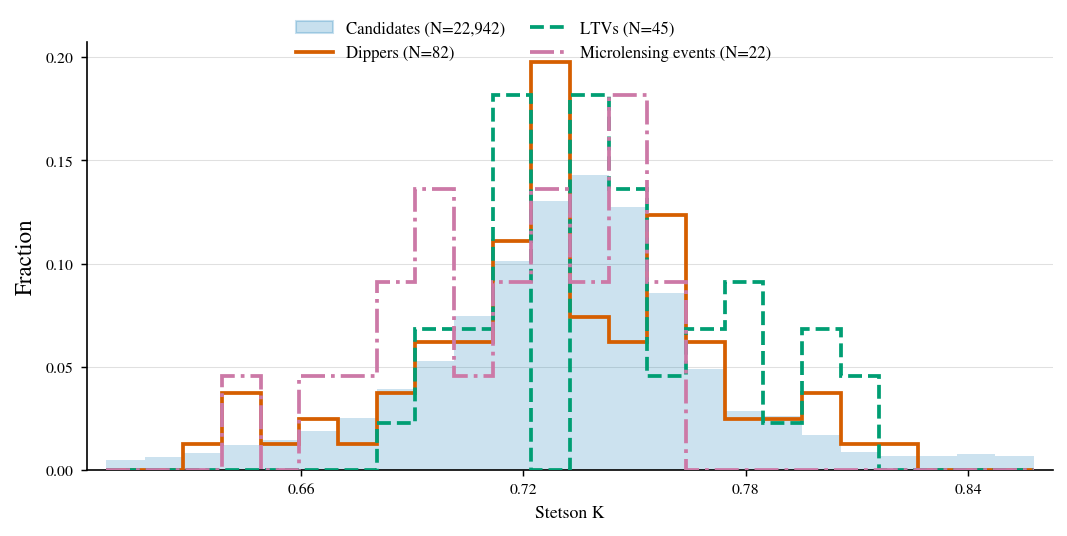

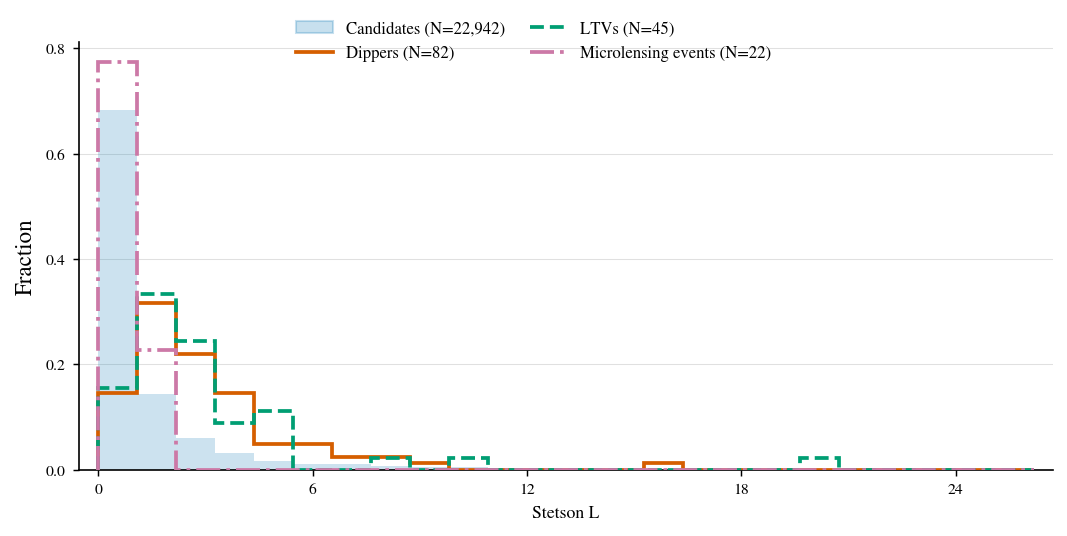

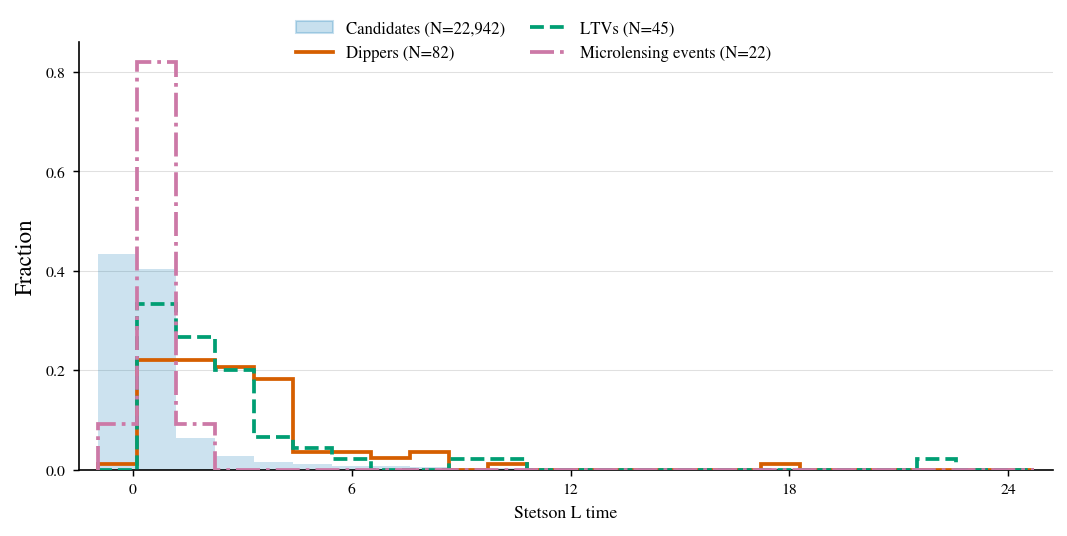

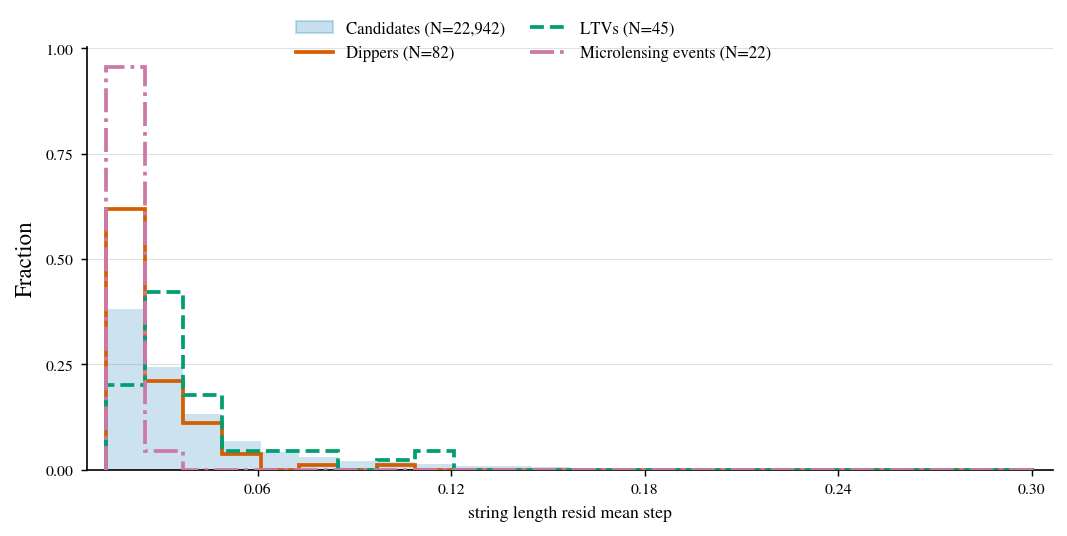

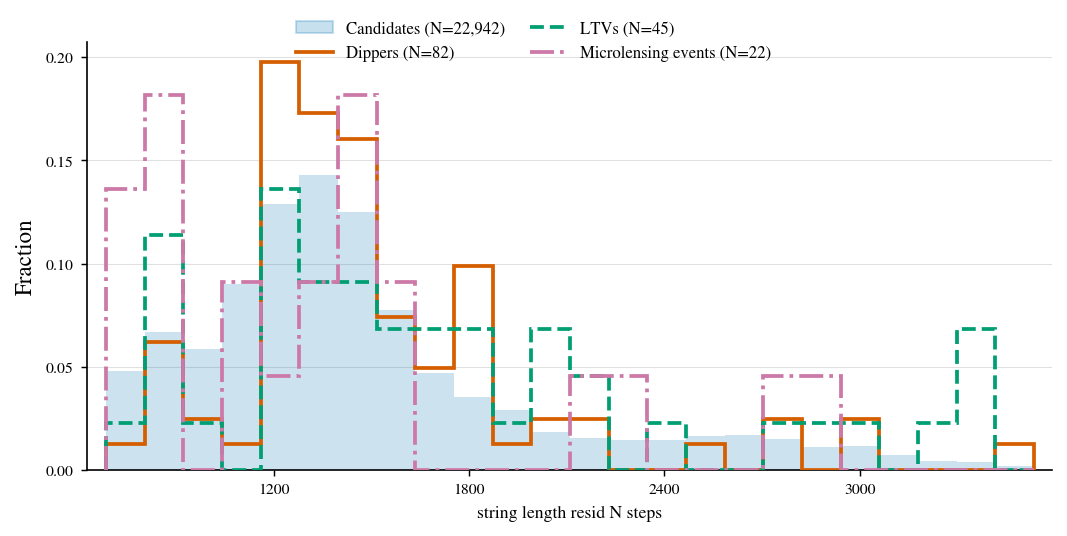

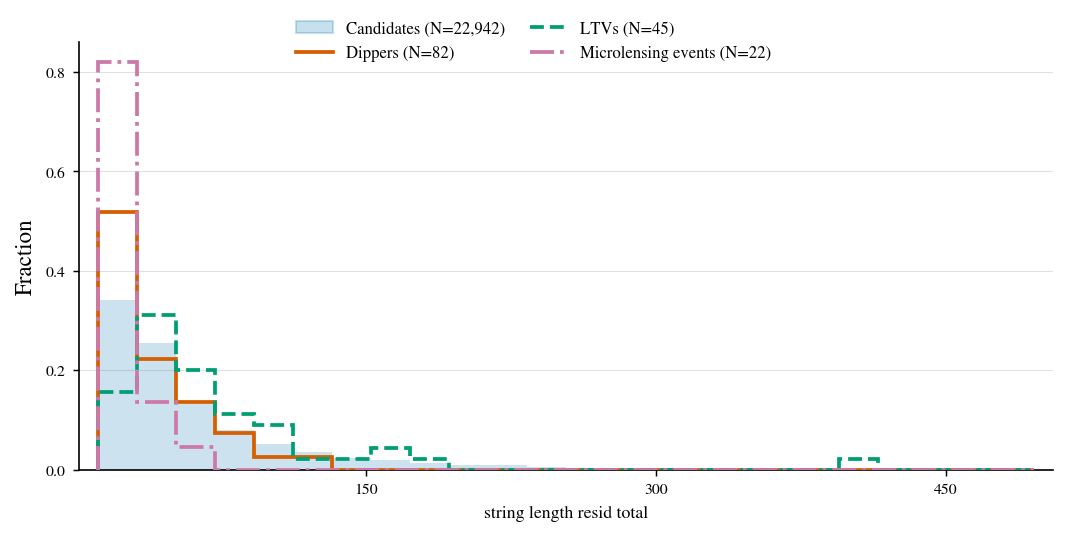

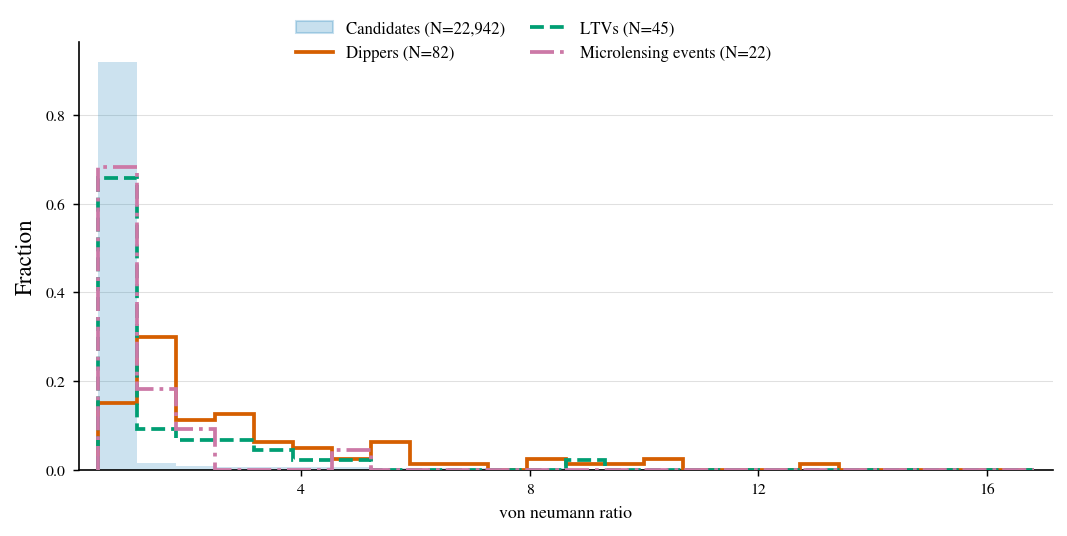

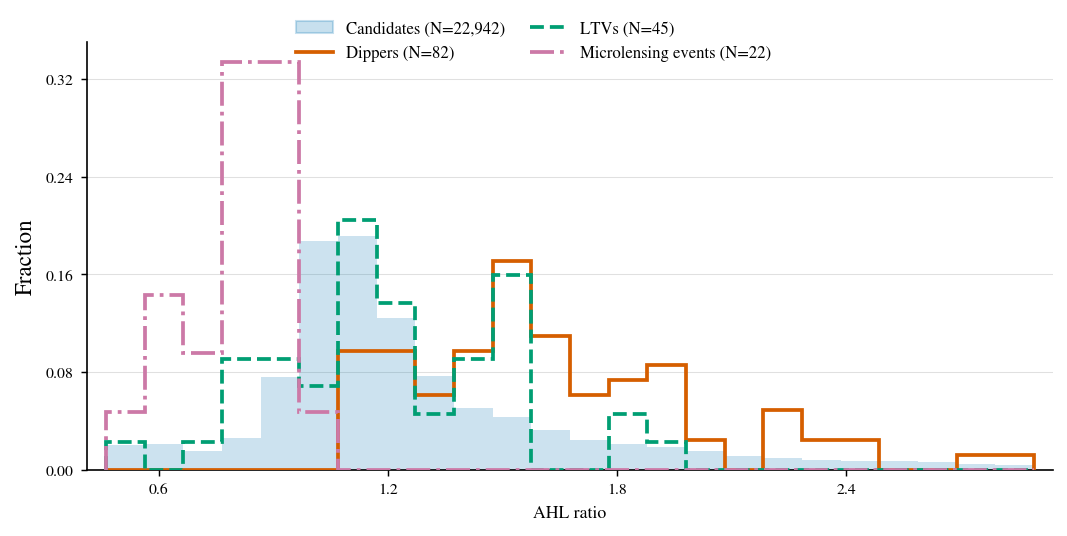

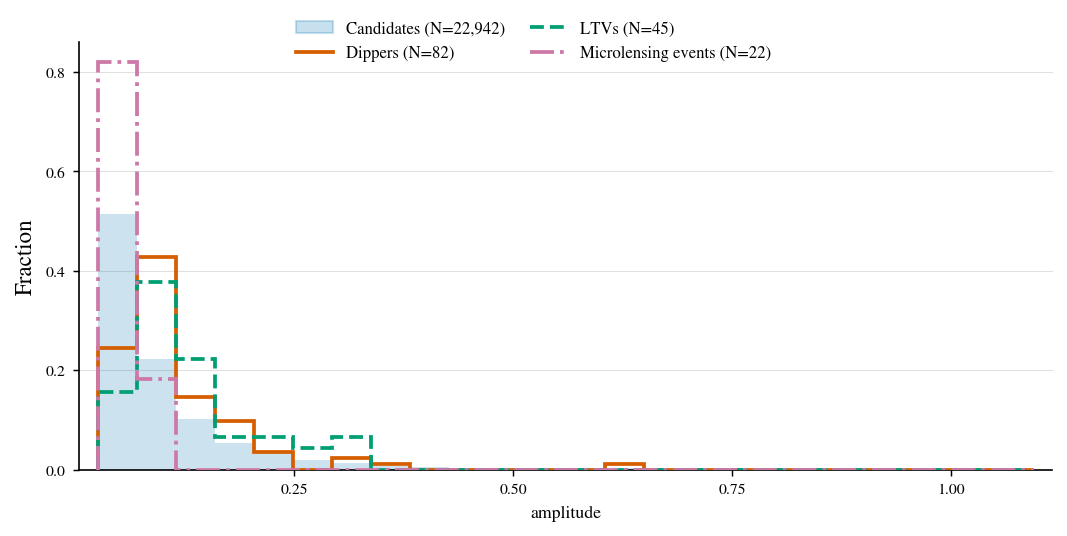

'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


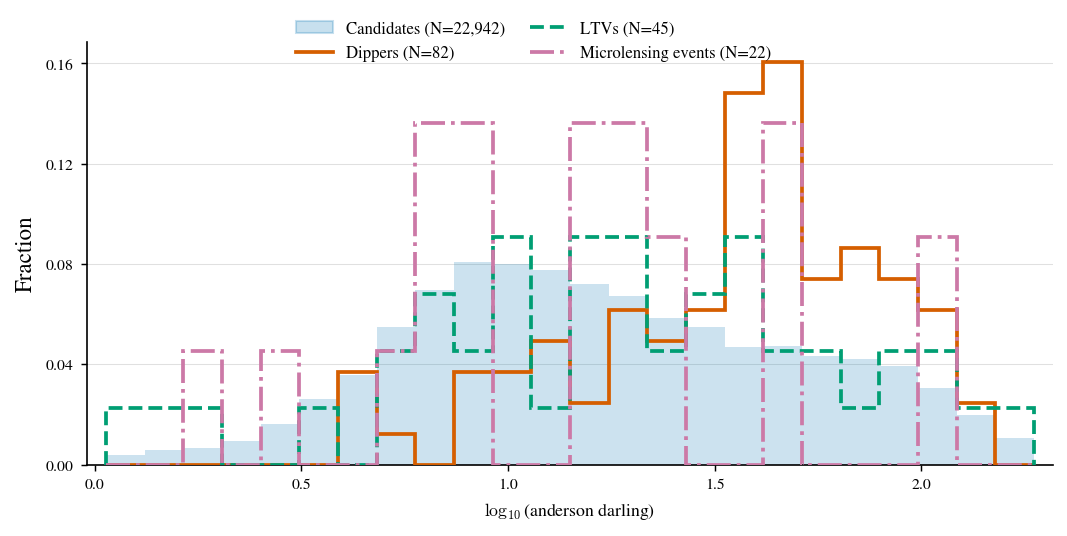

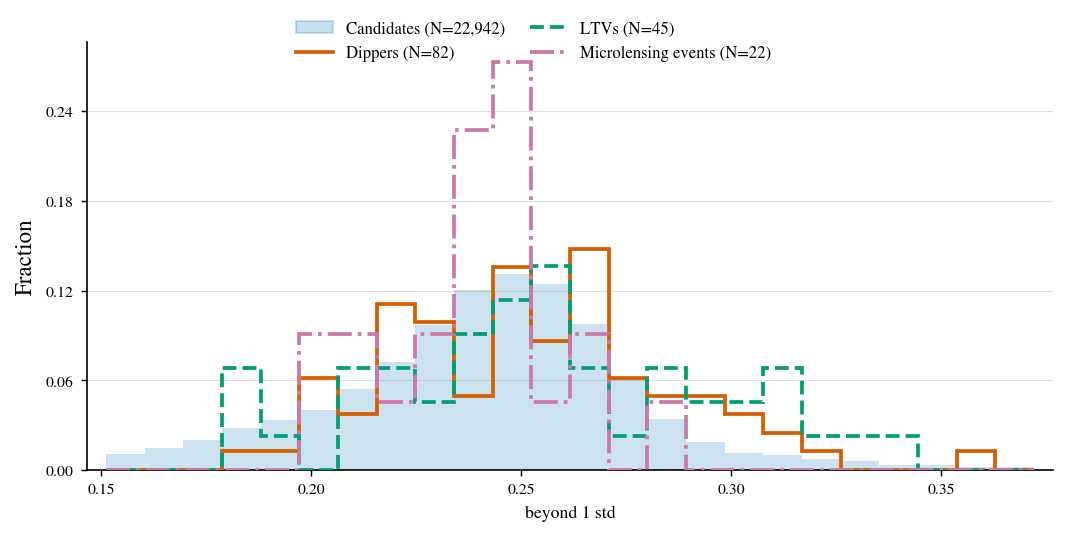

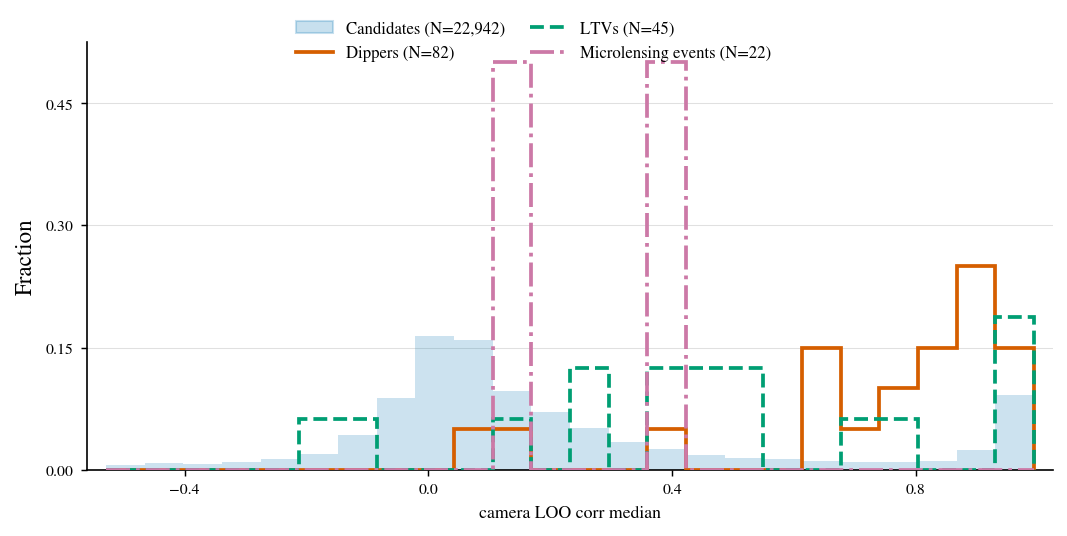

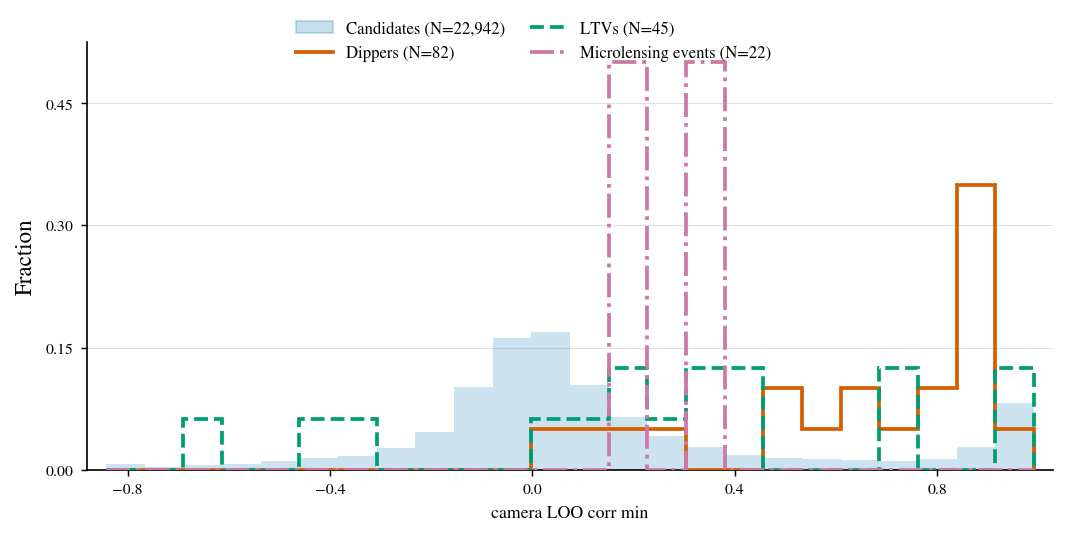

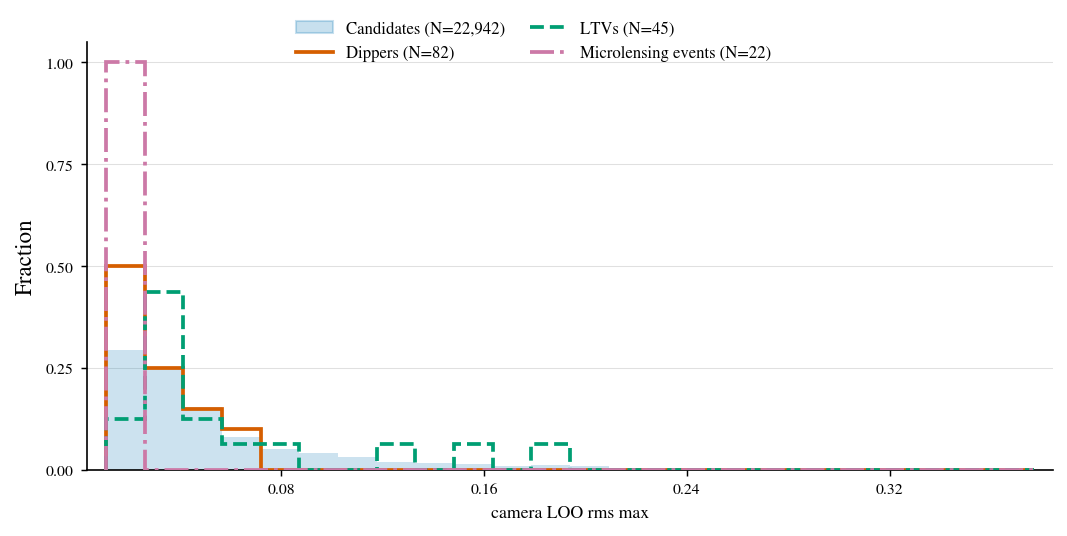

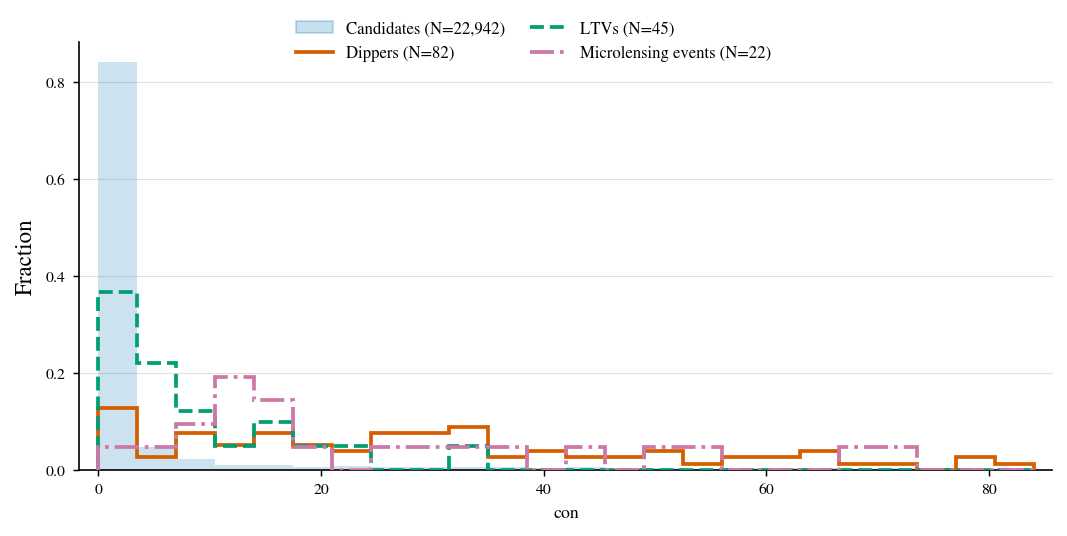

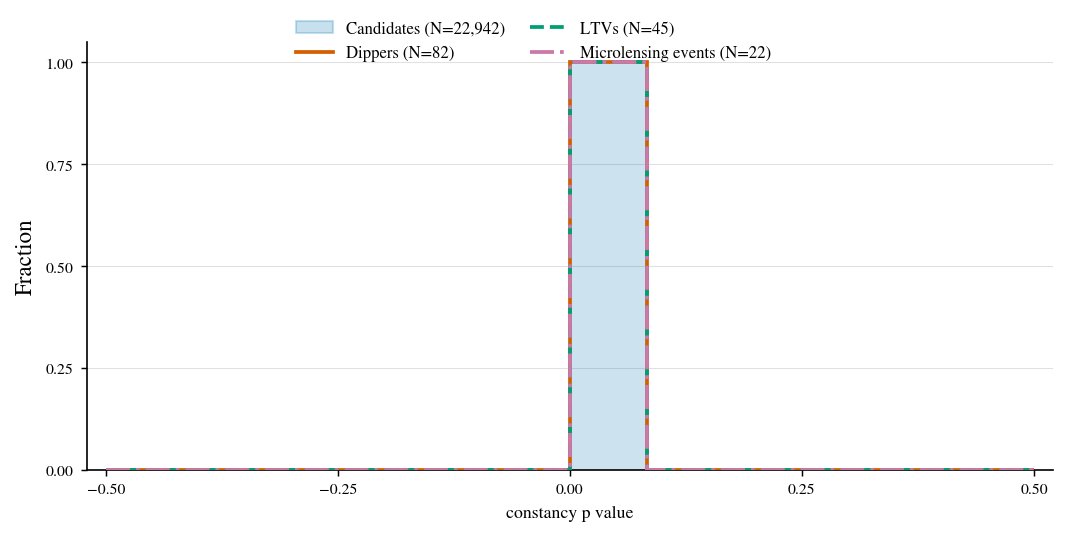

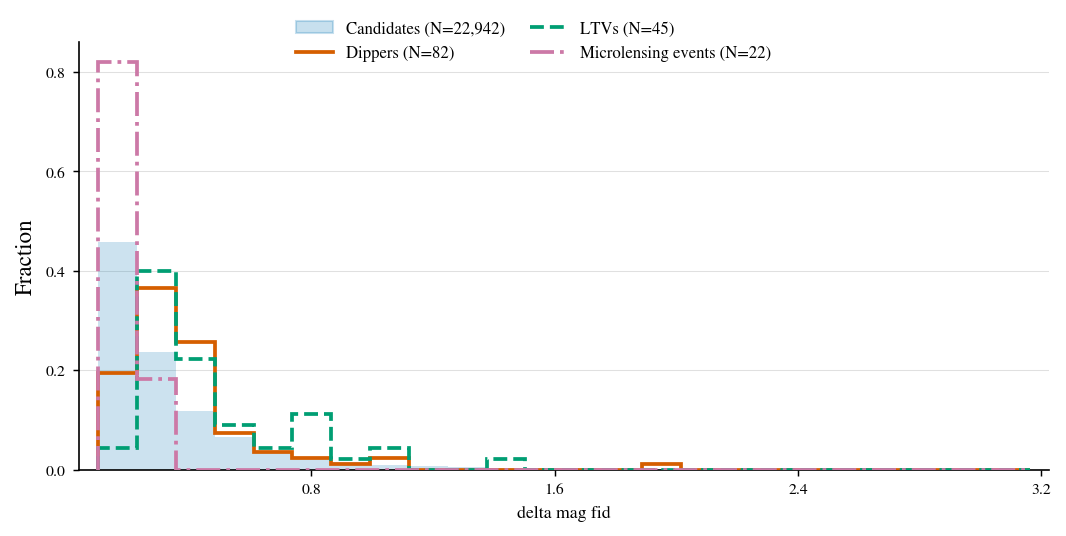

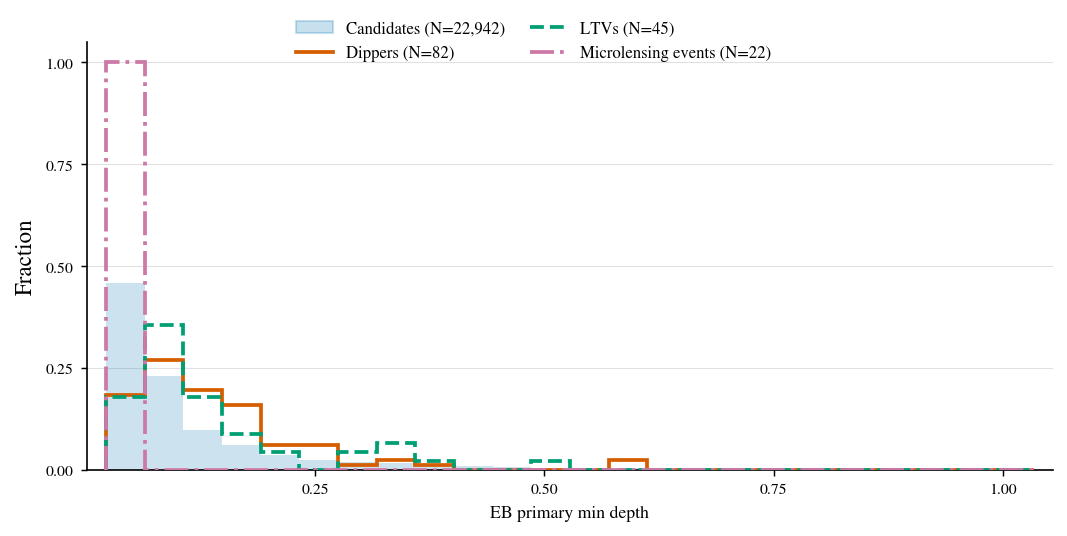

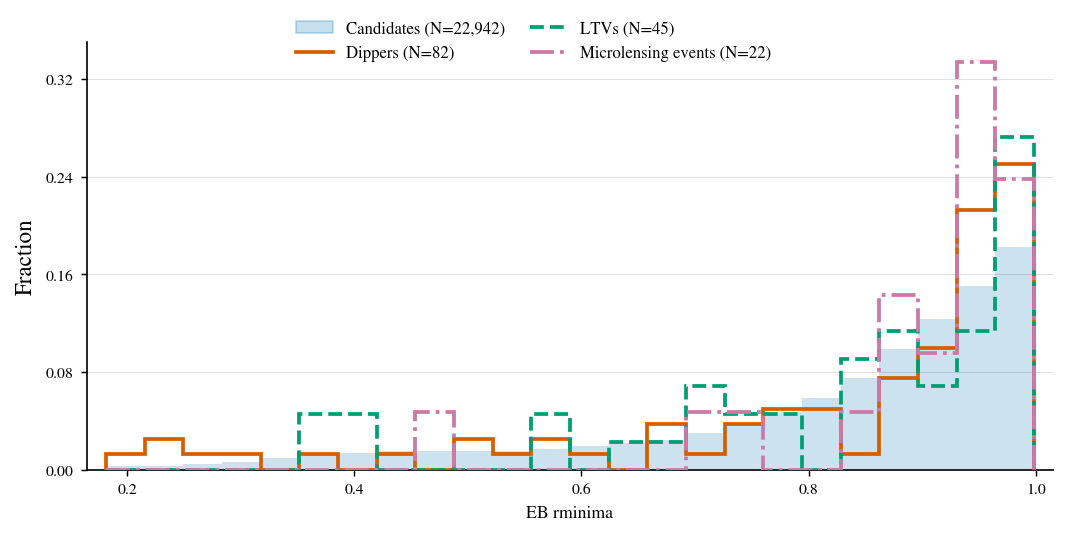

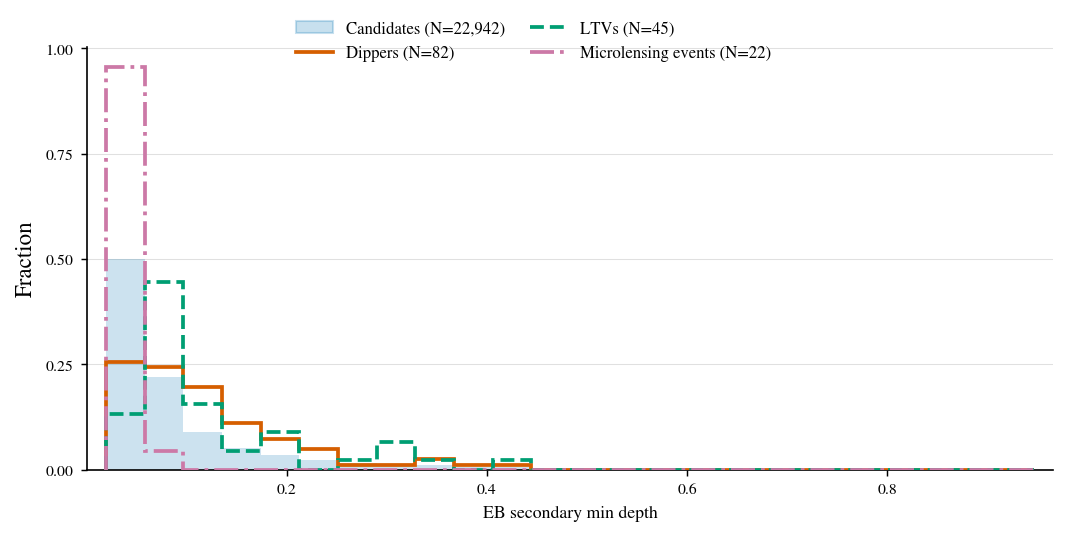

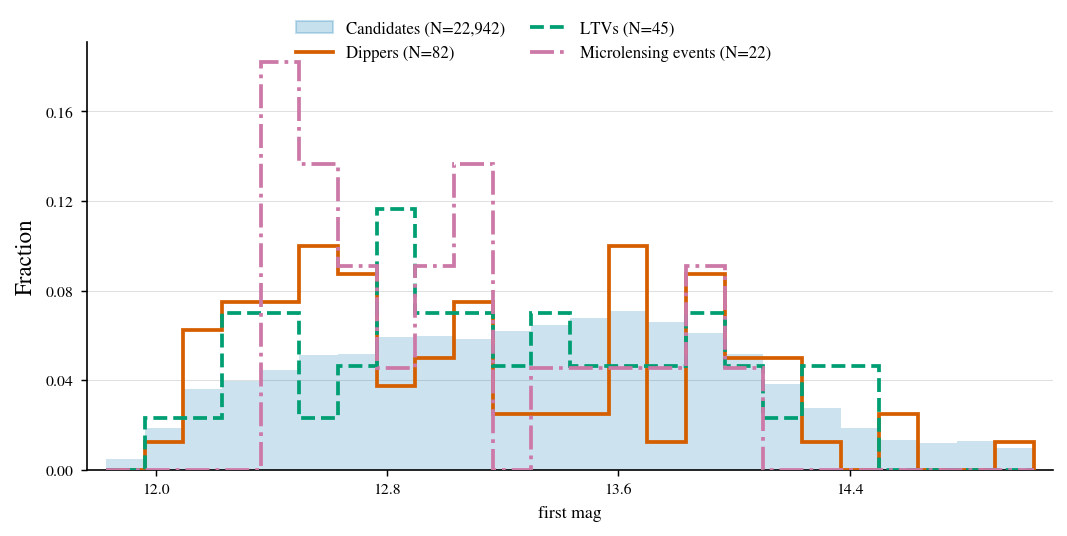

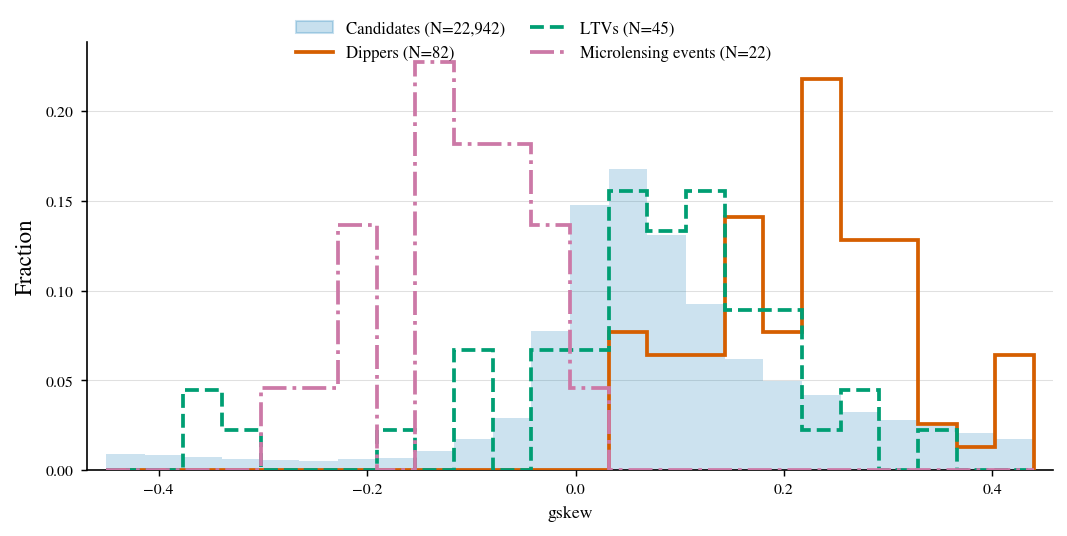

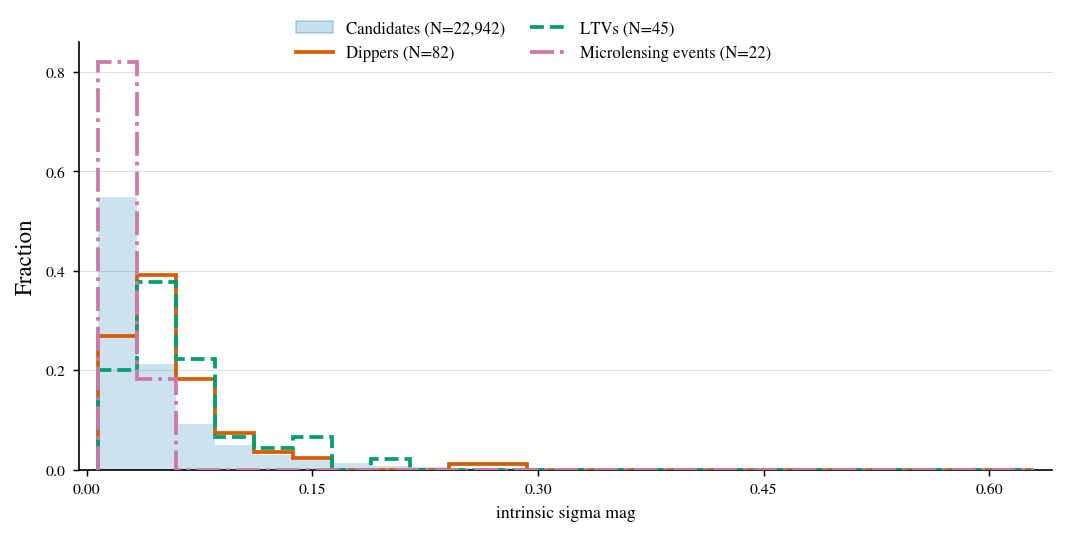

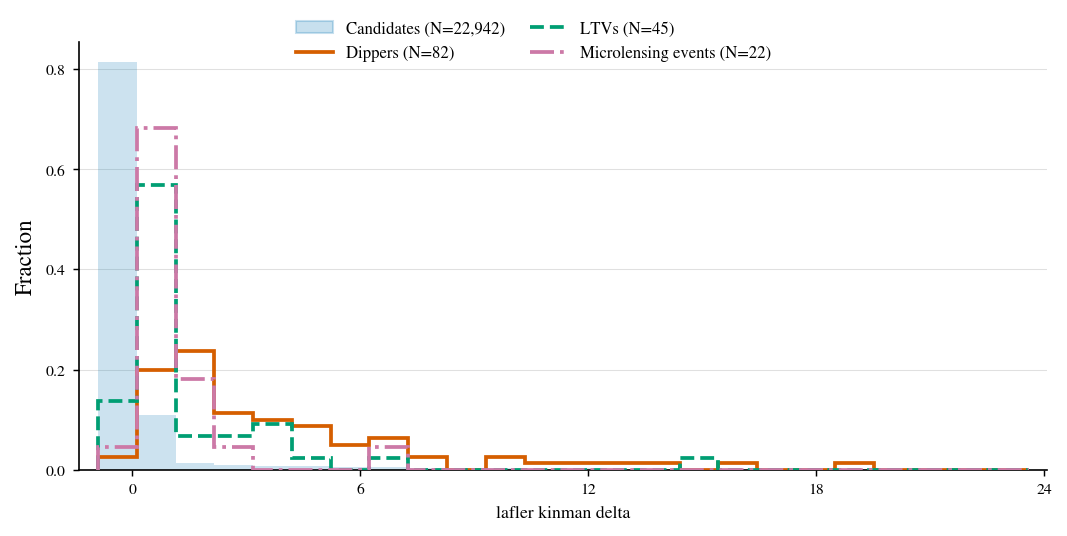

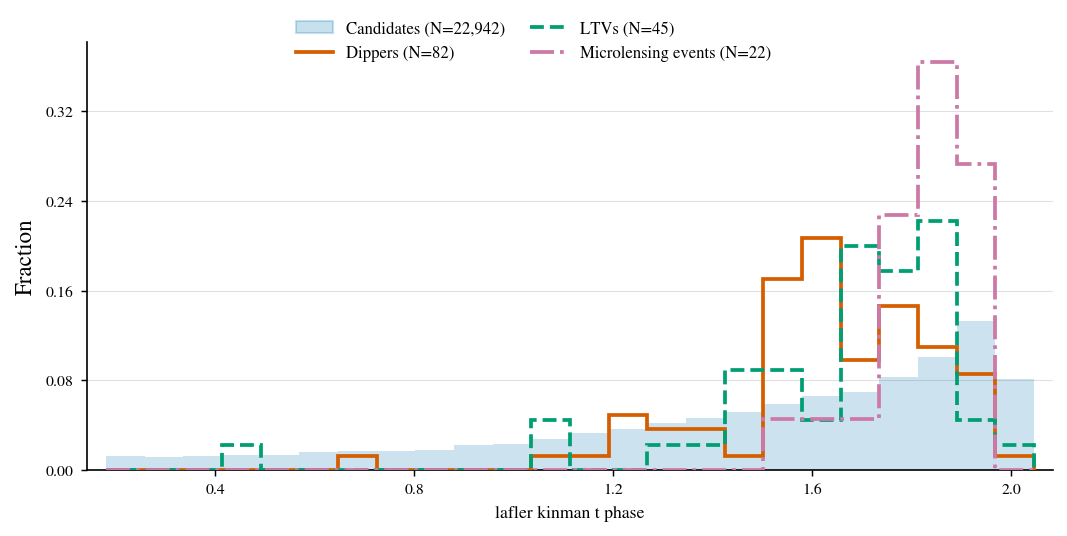

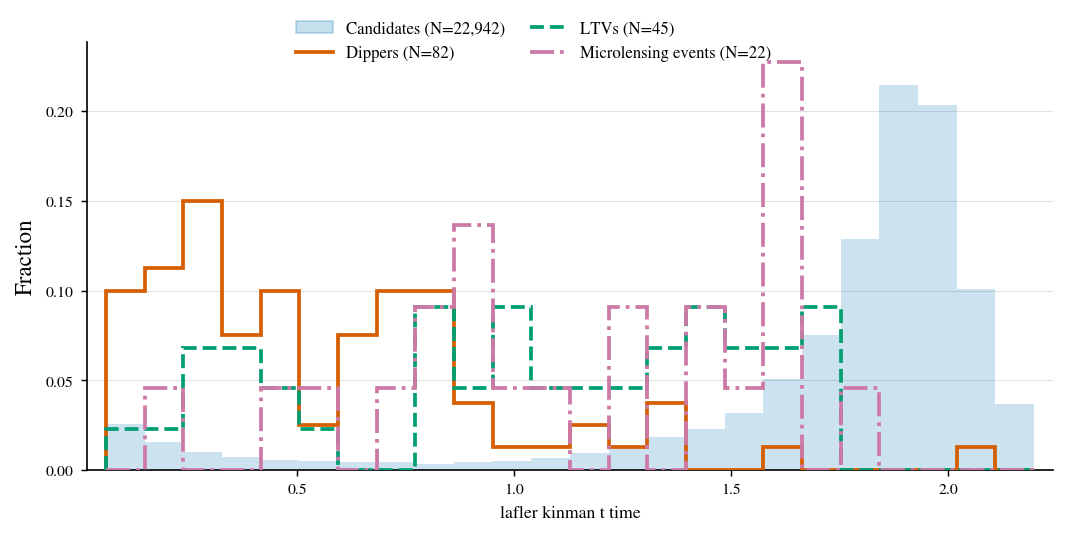

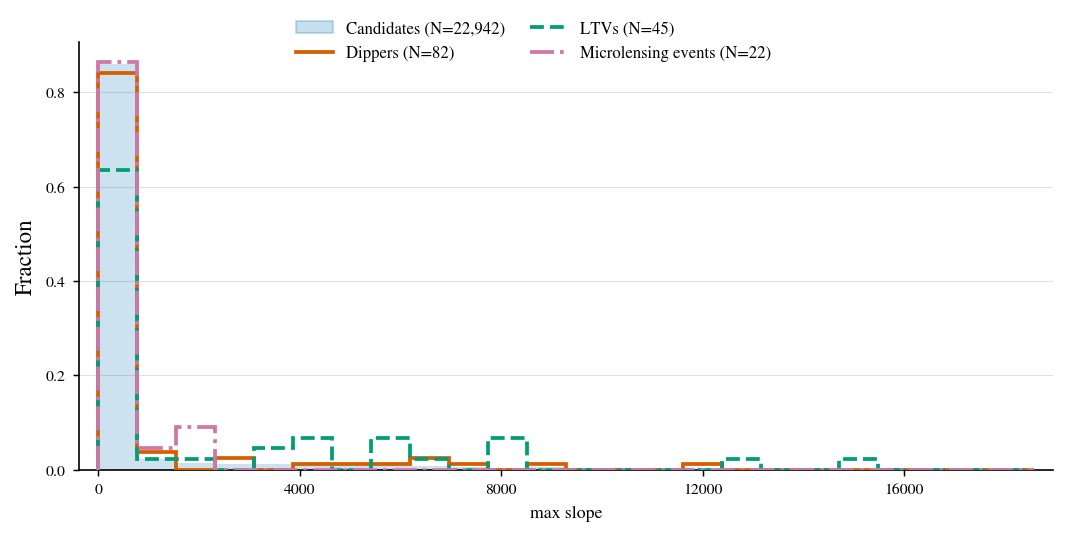

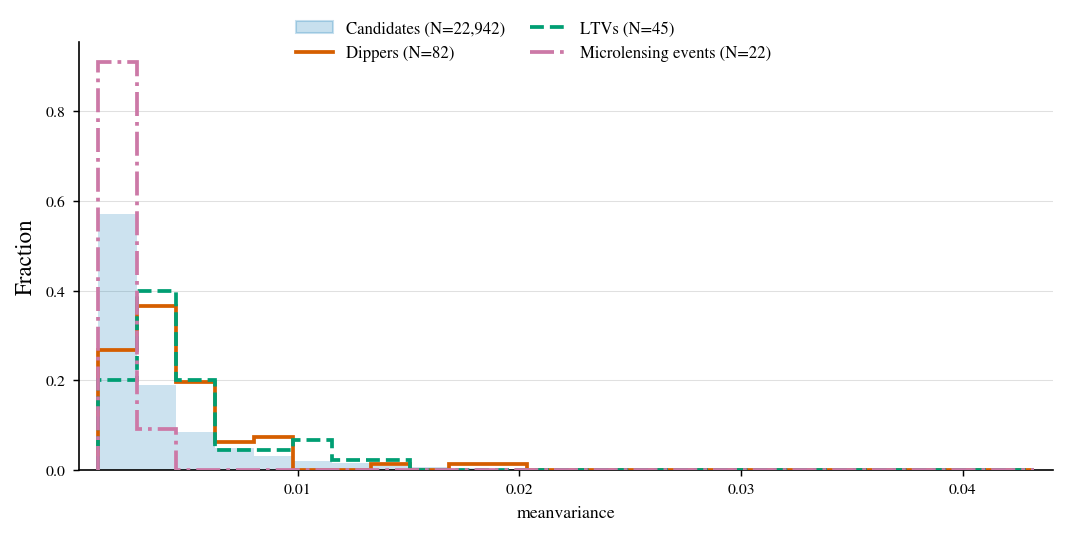

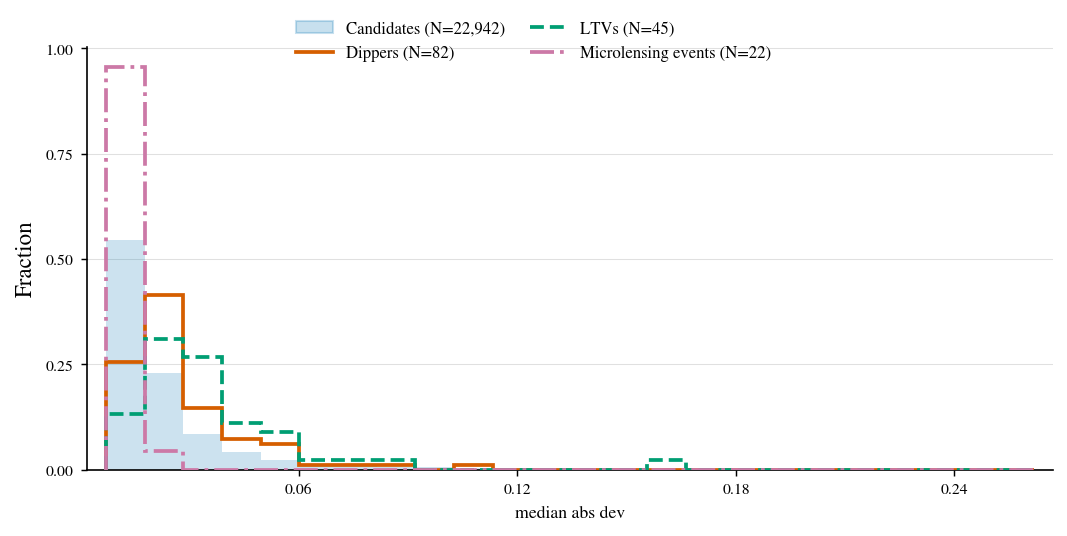

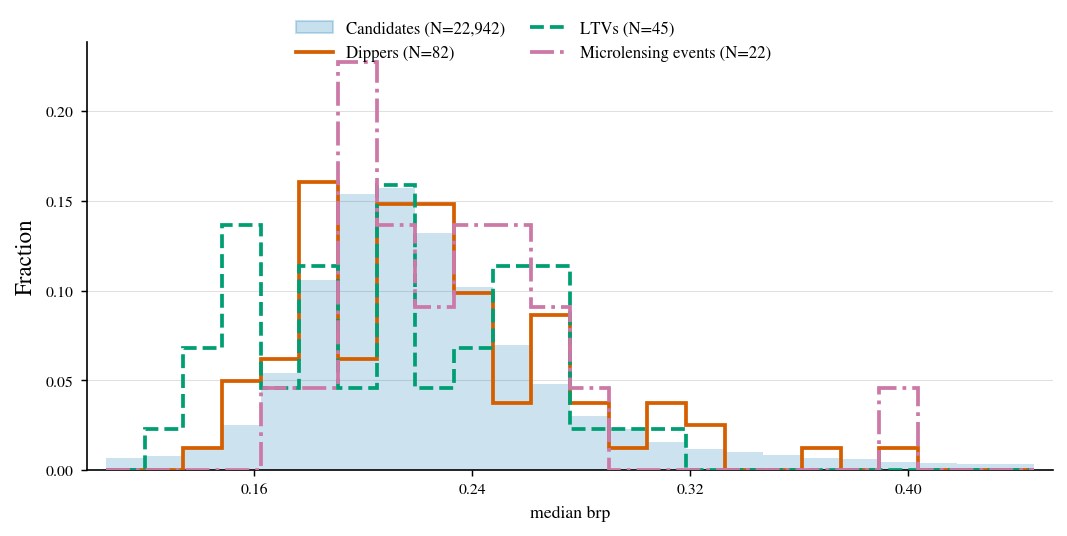

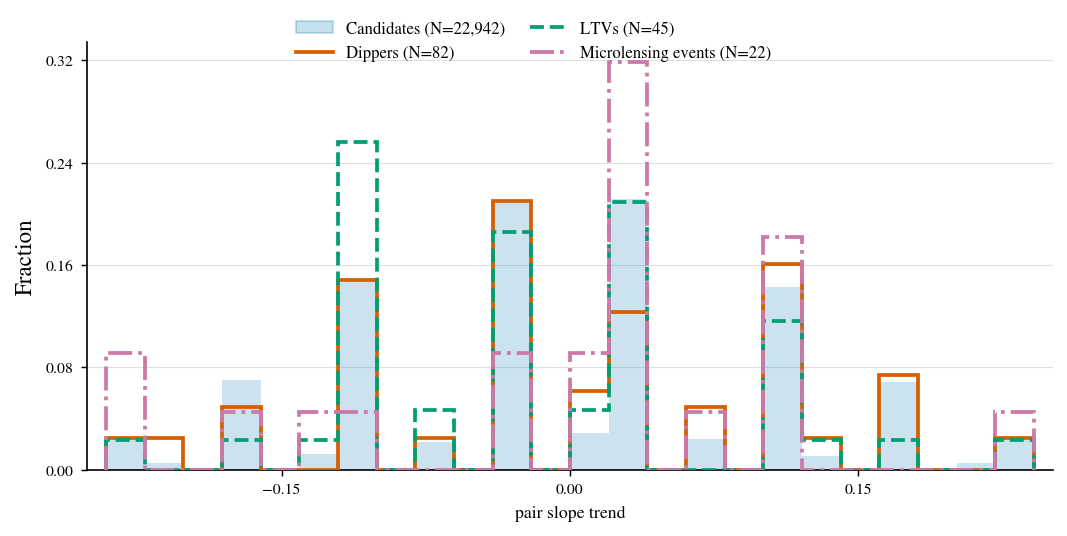

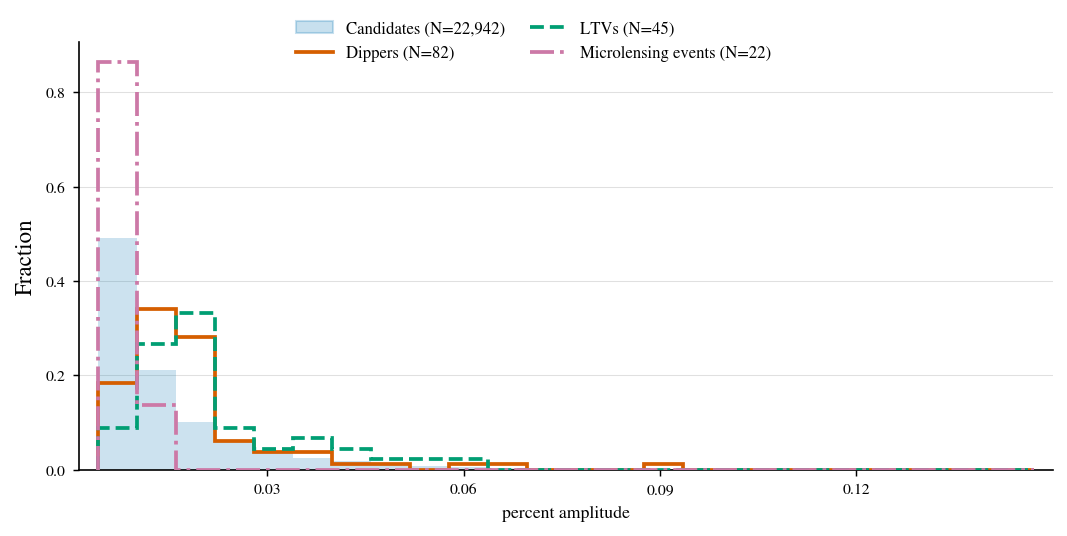

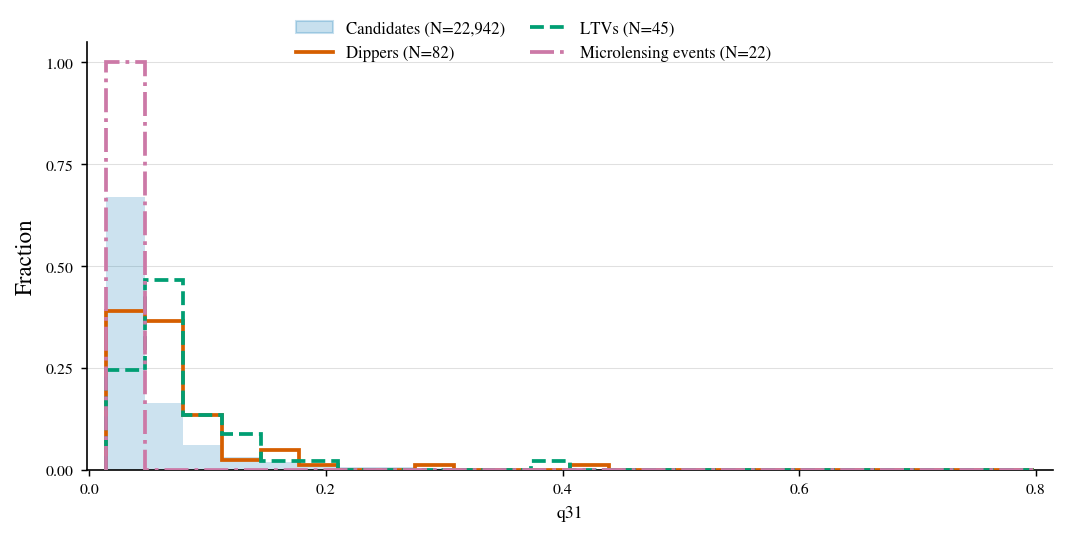

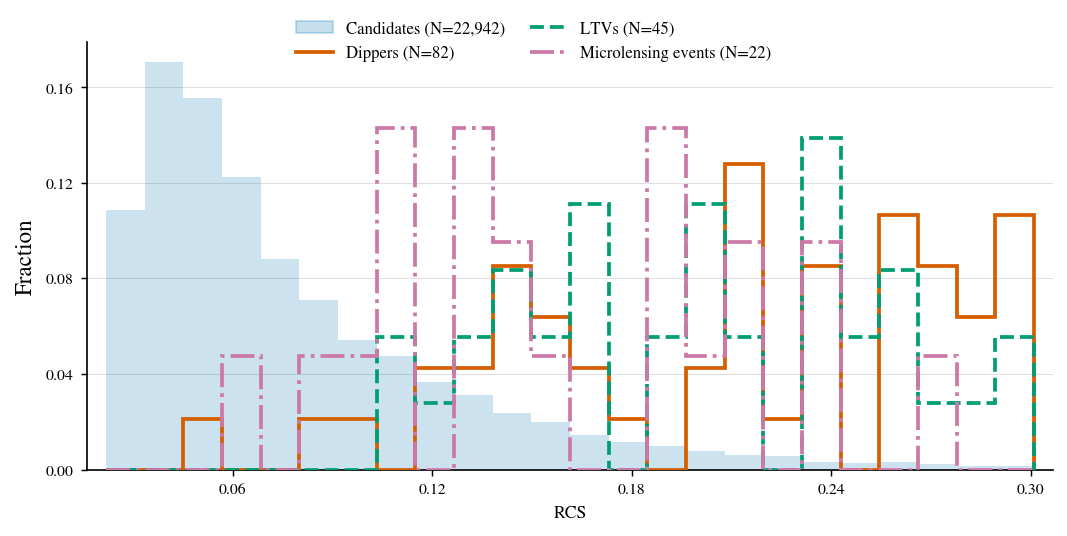

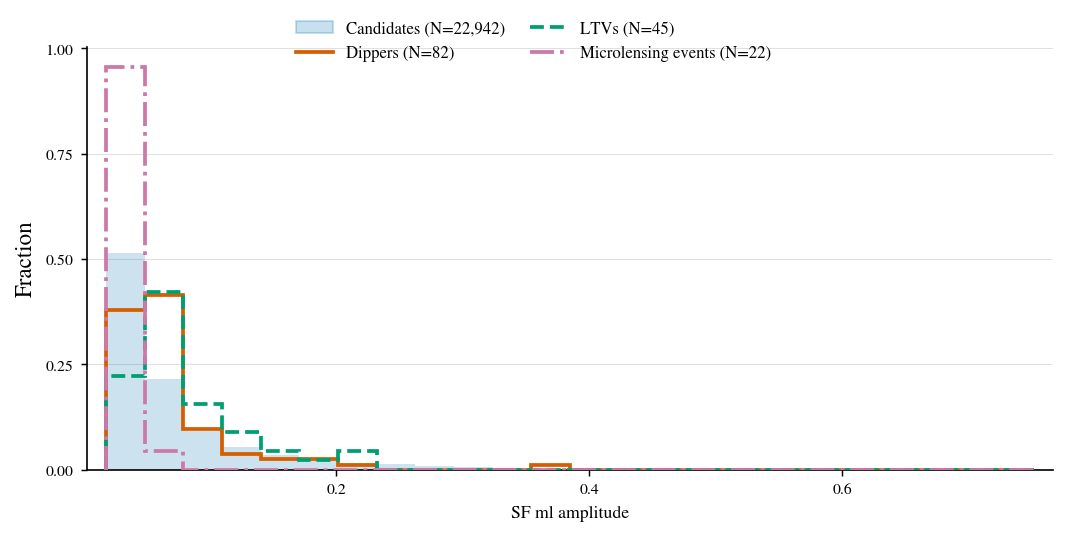

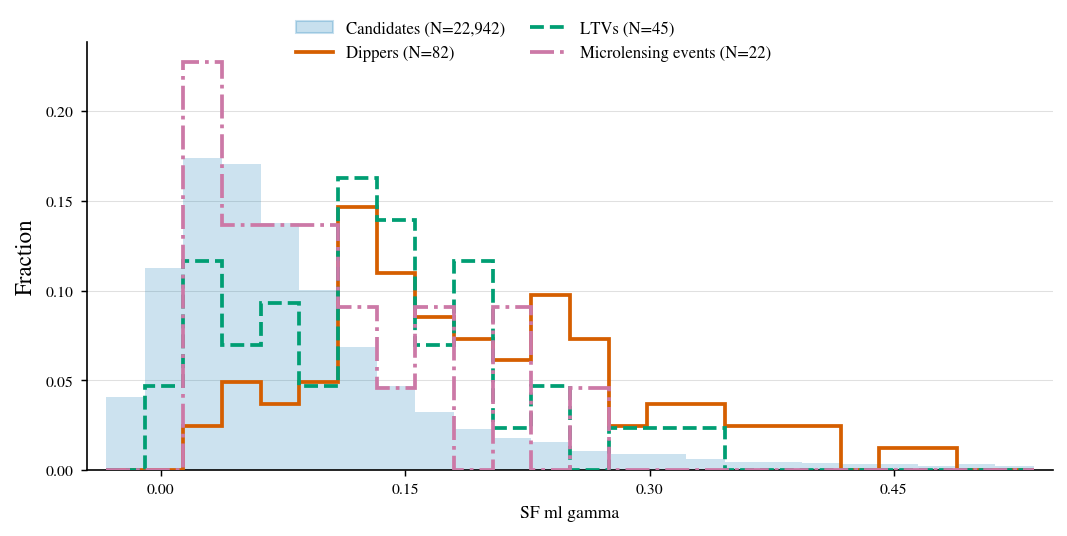

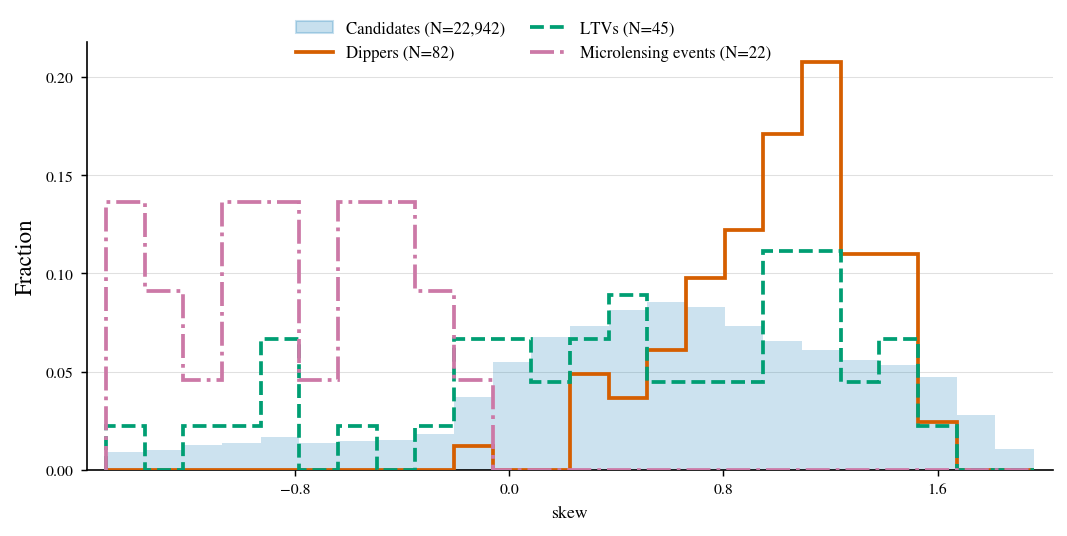

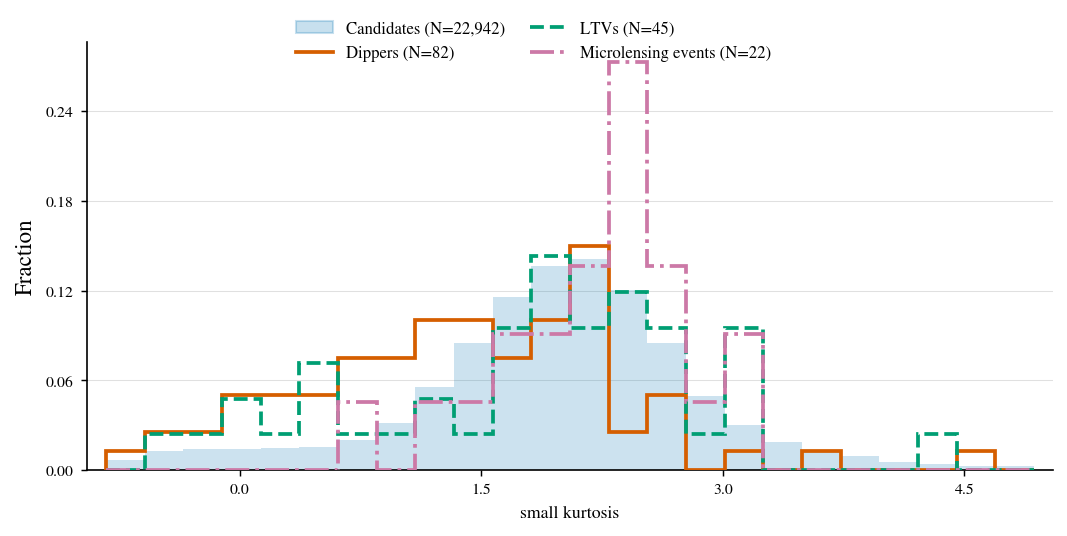

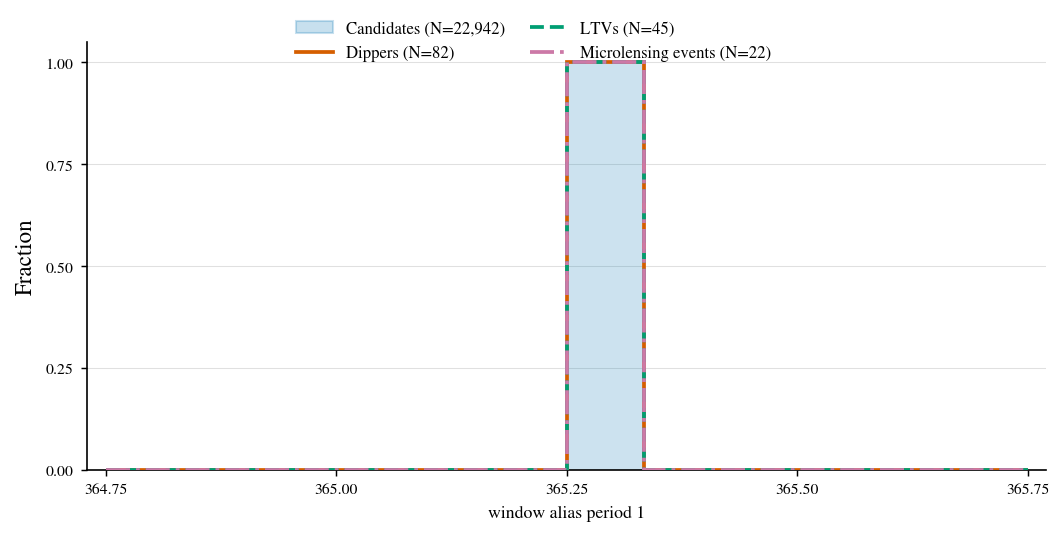

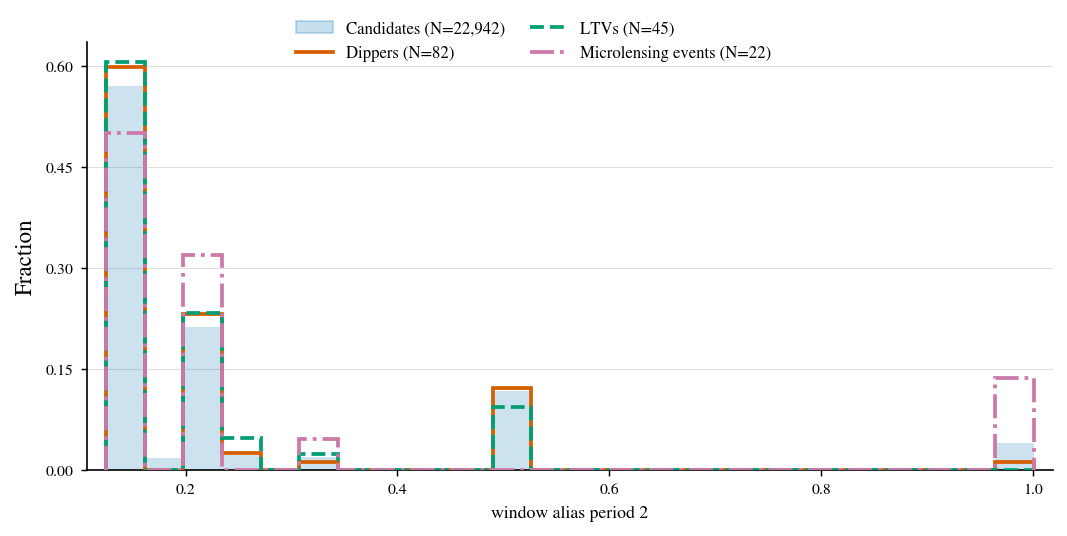

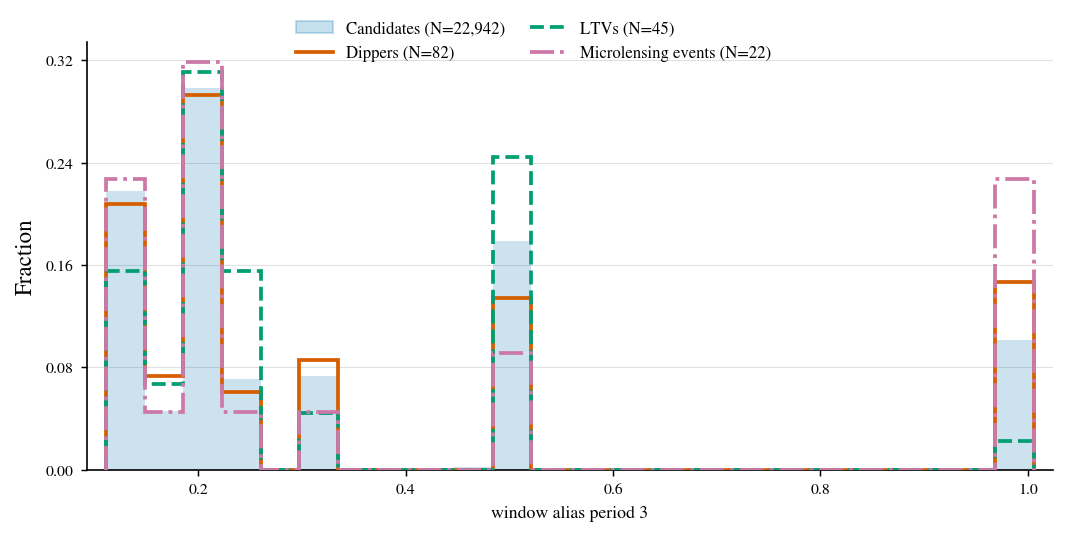

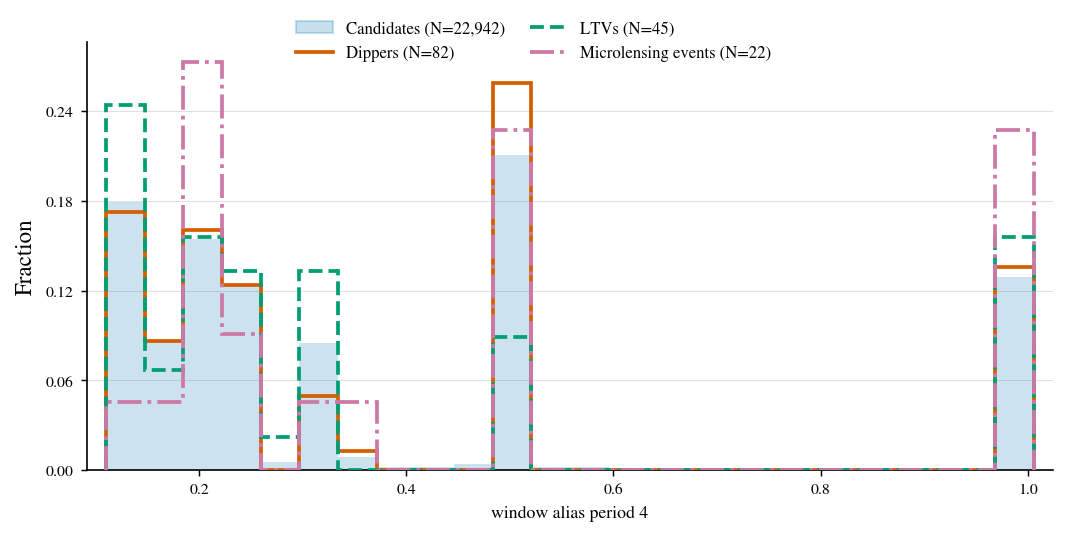

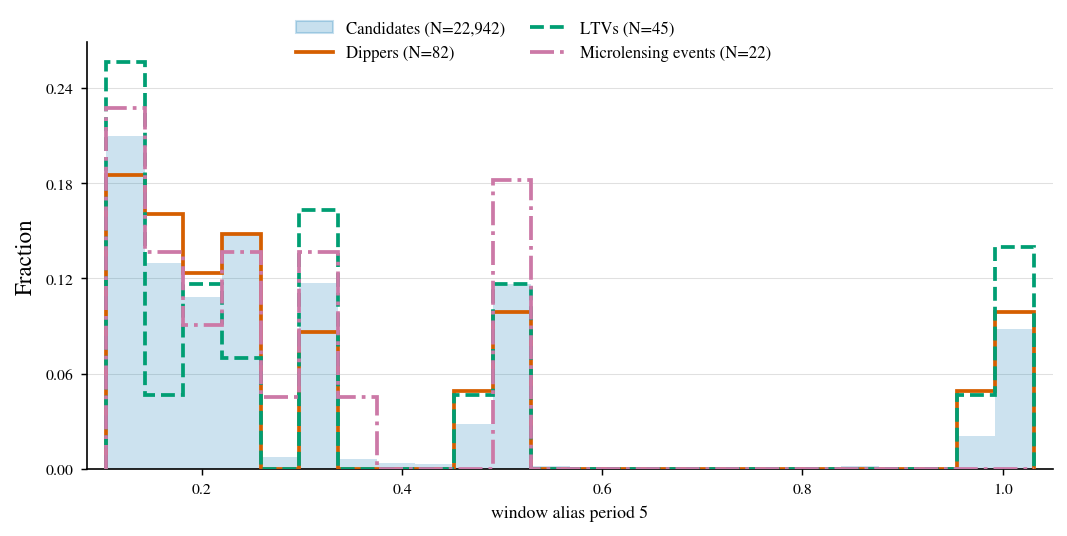

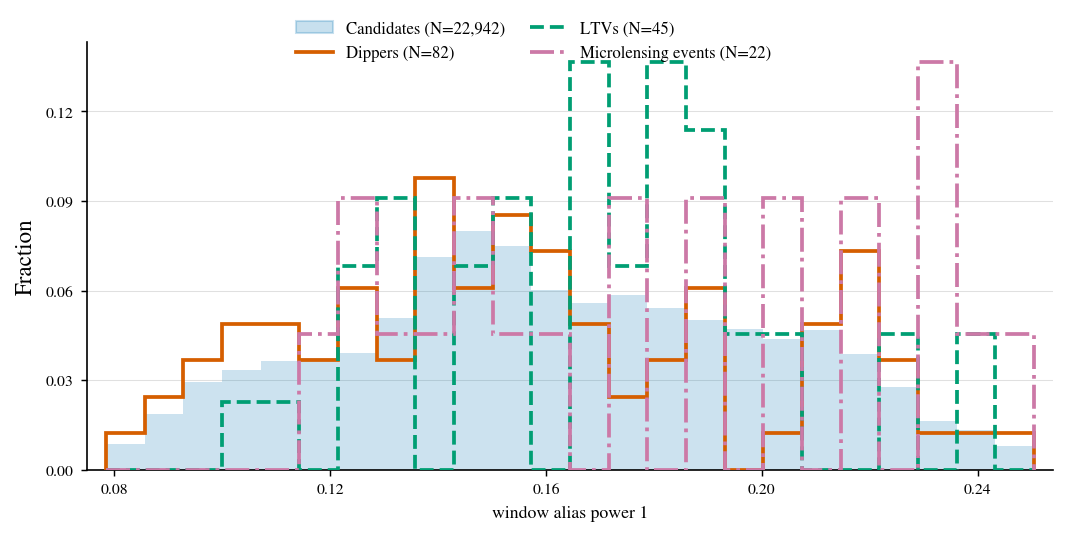

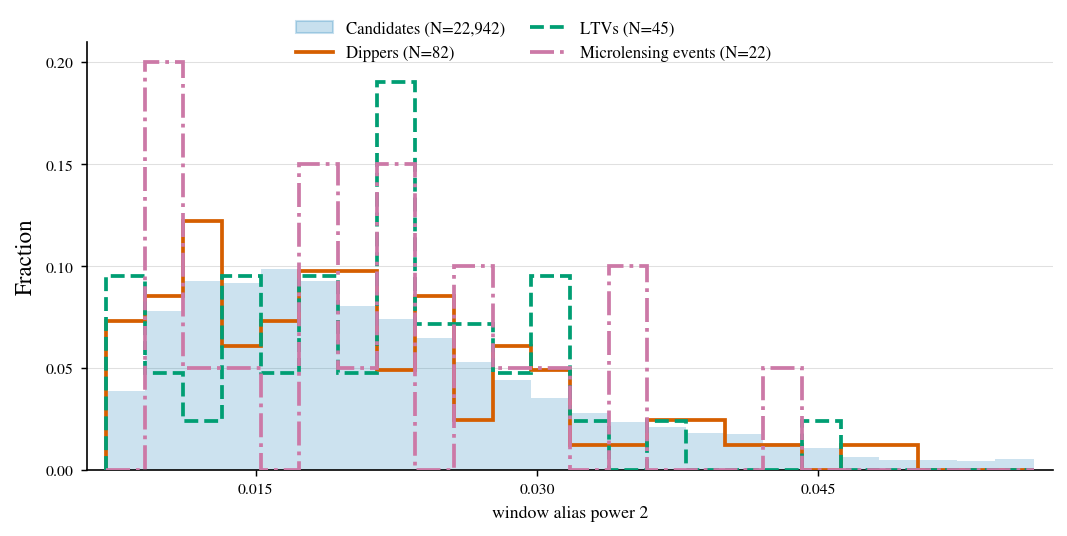

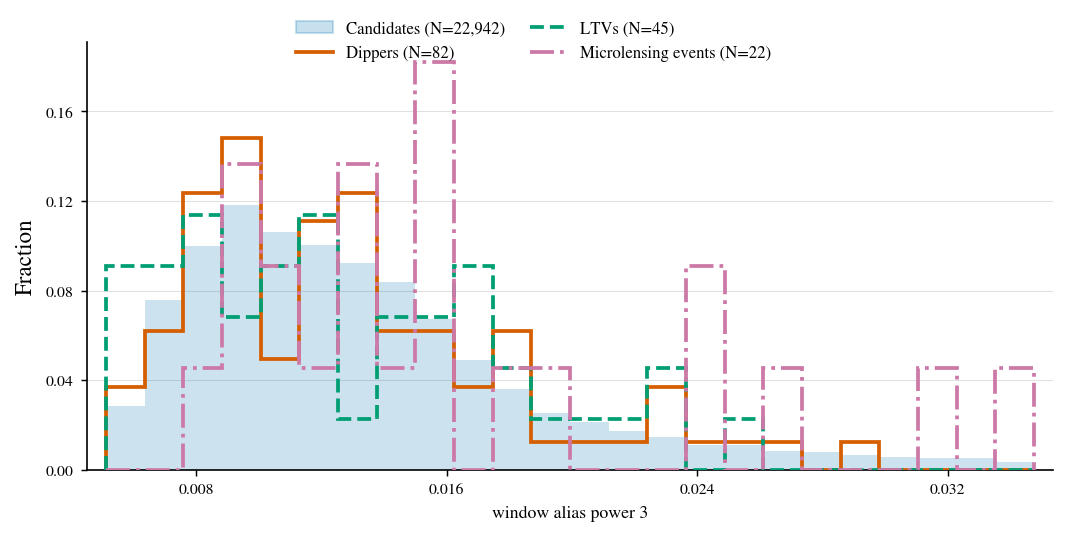

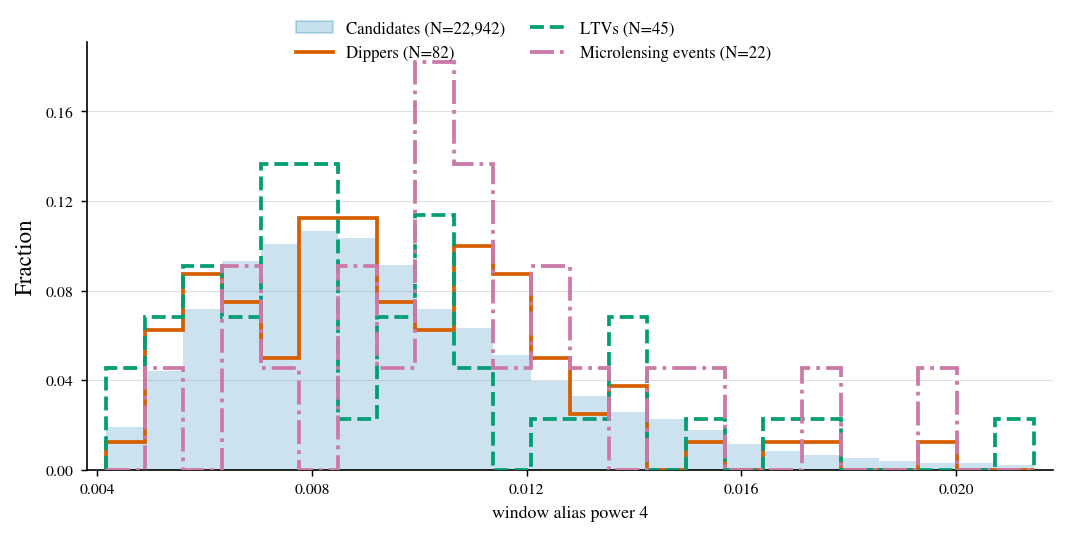

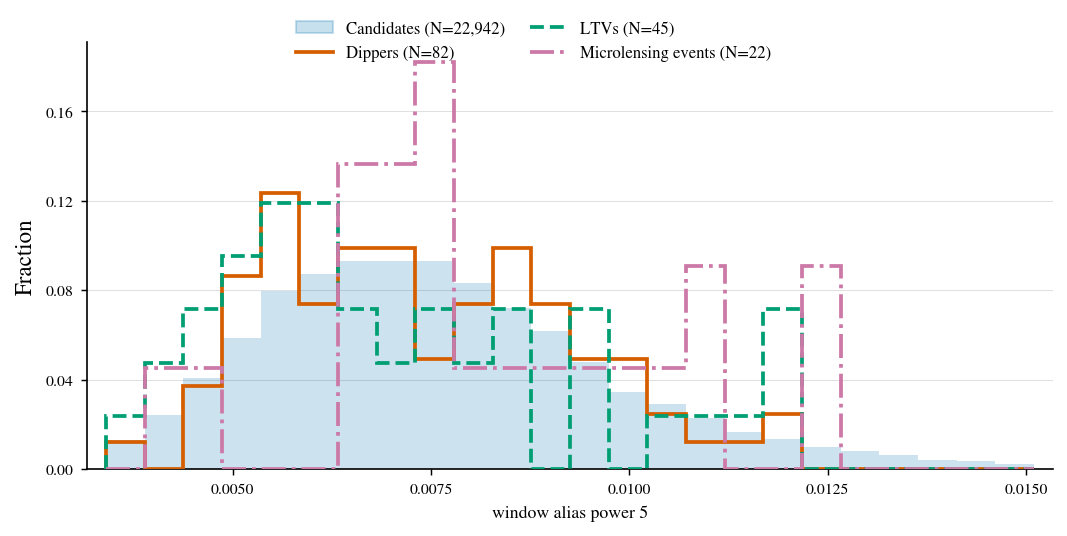

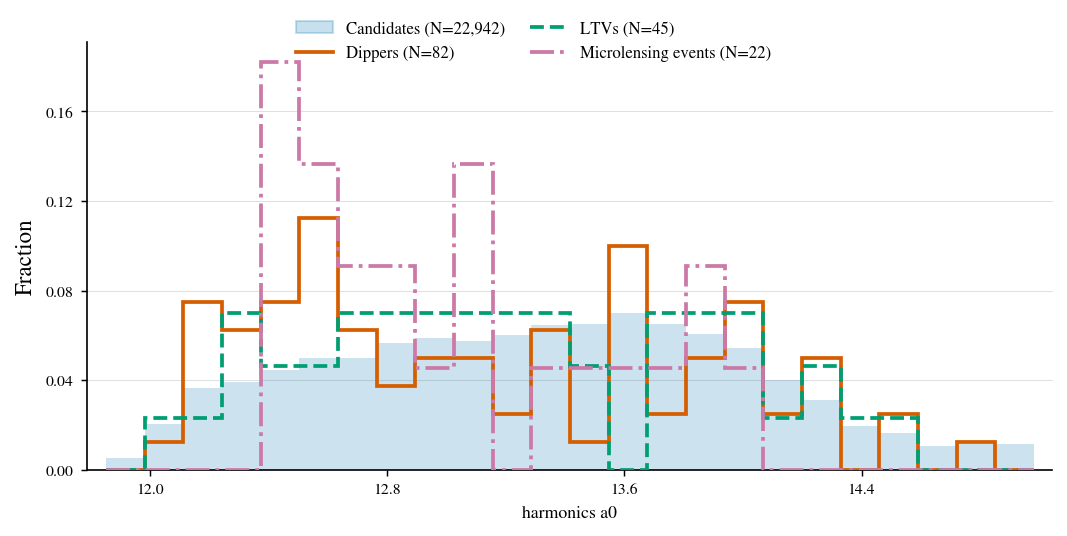

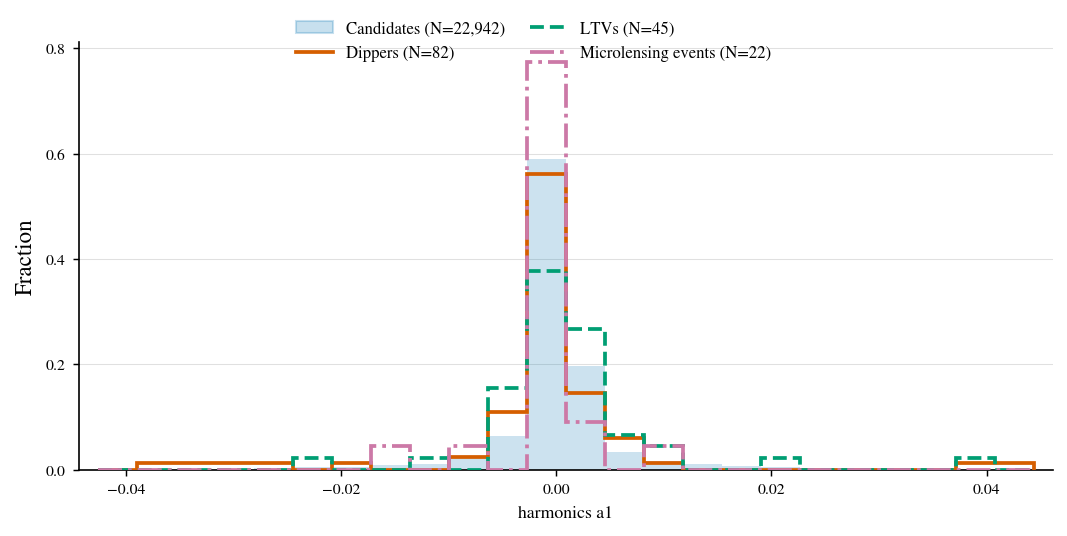

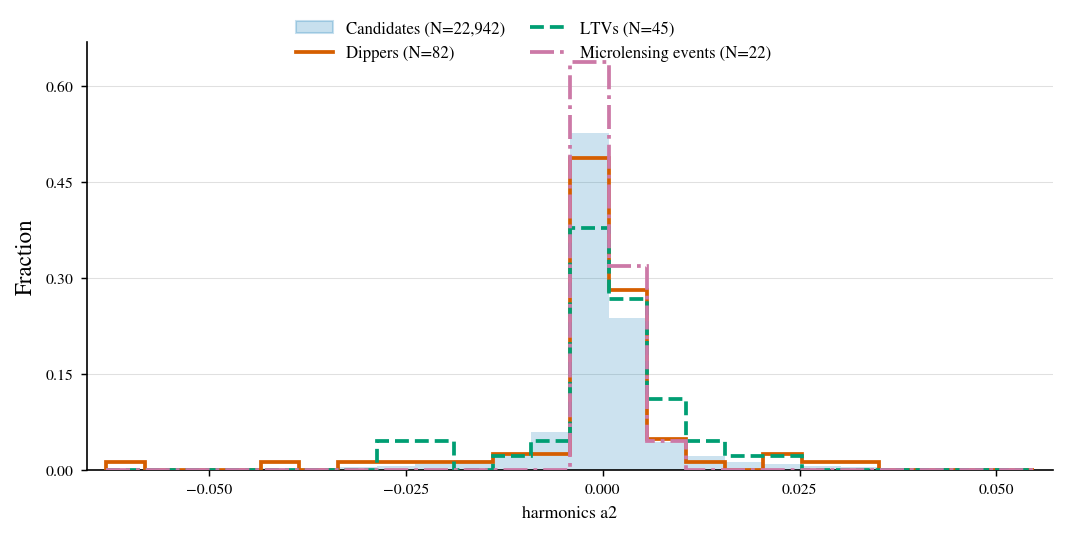

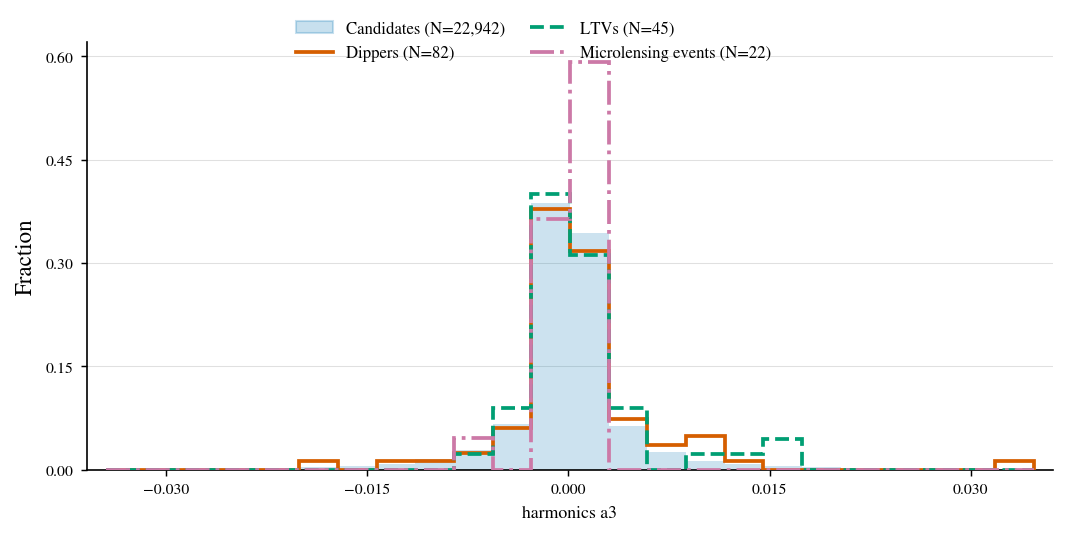

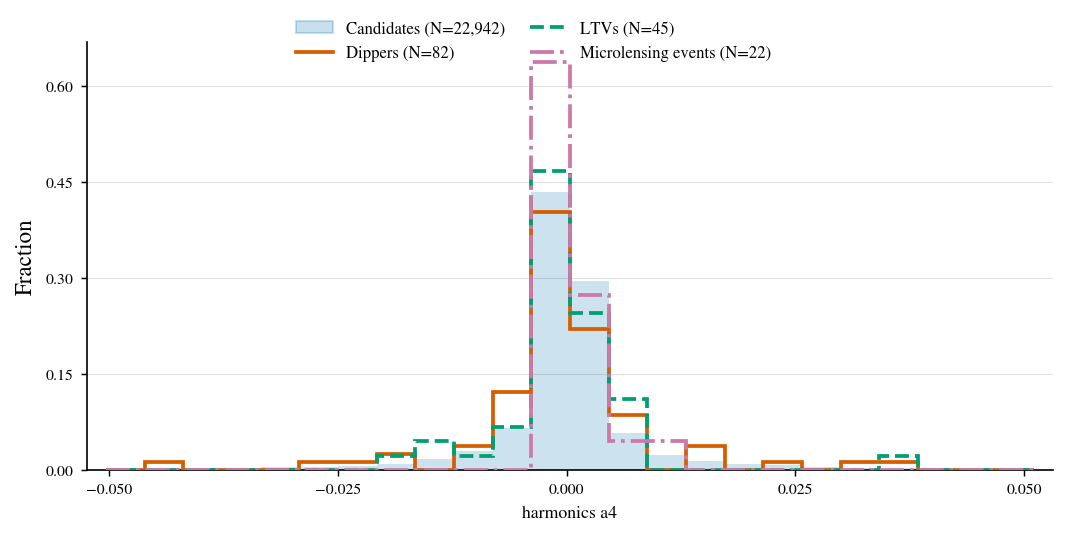

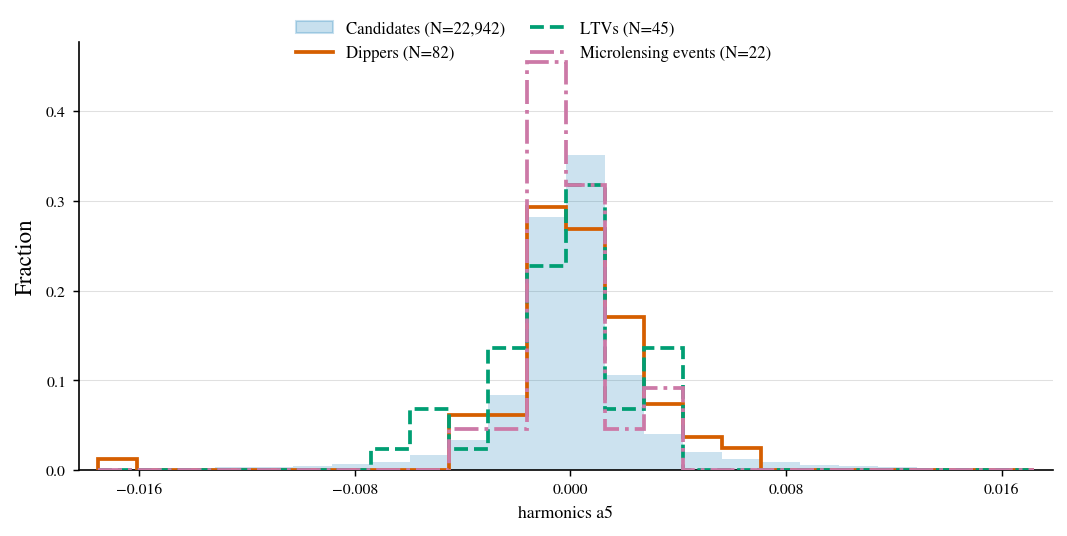

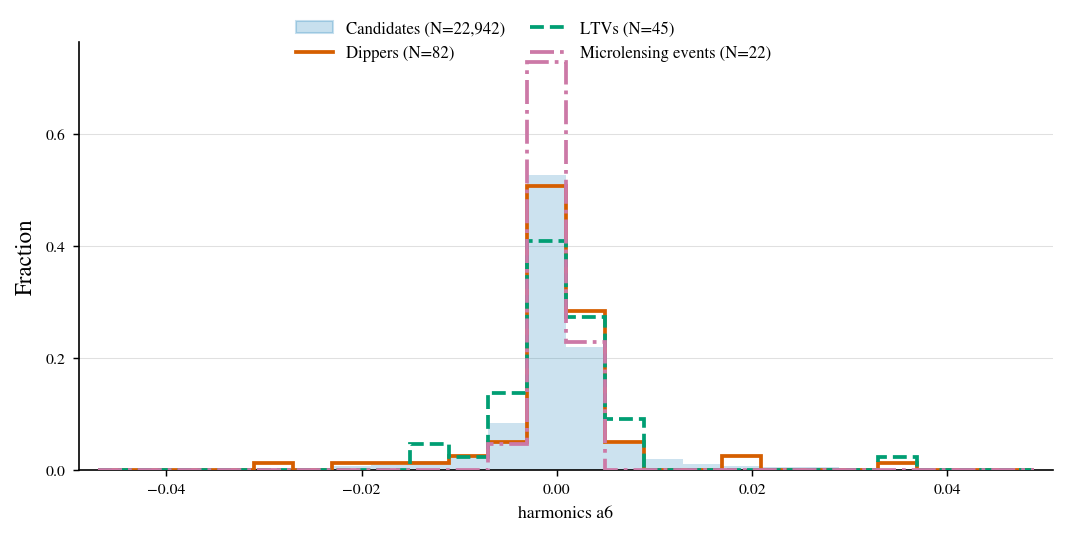

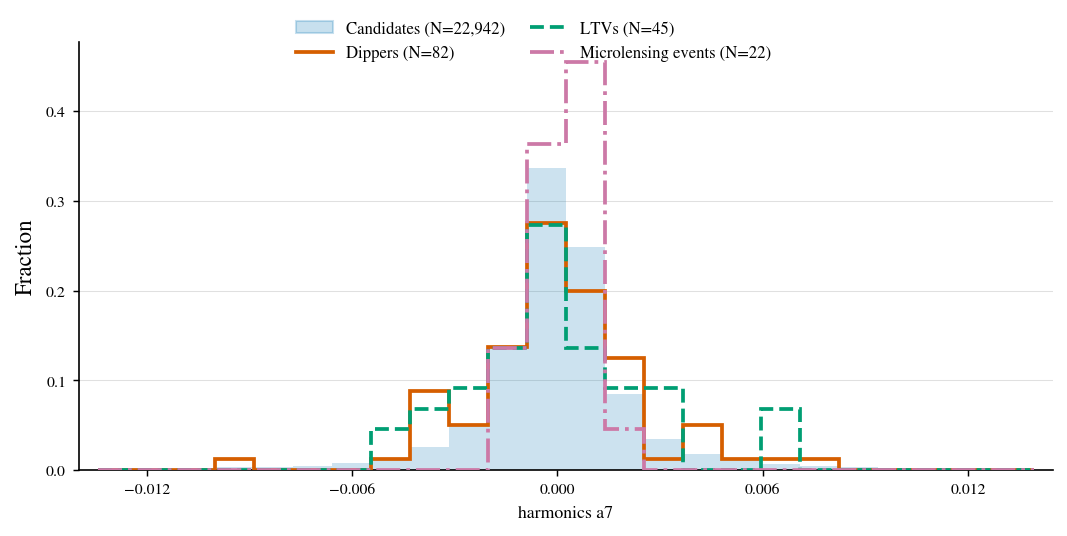

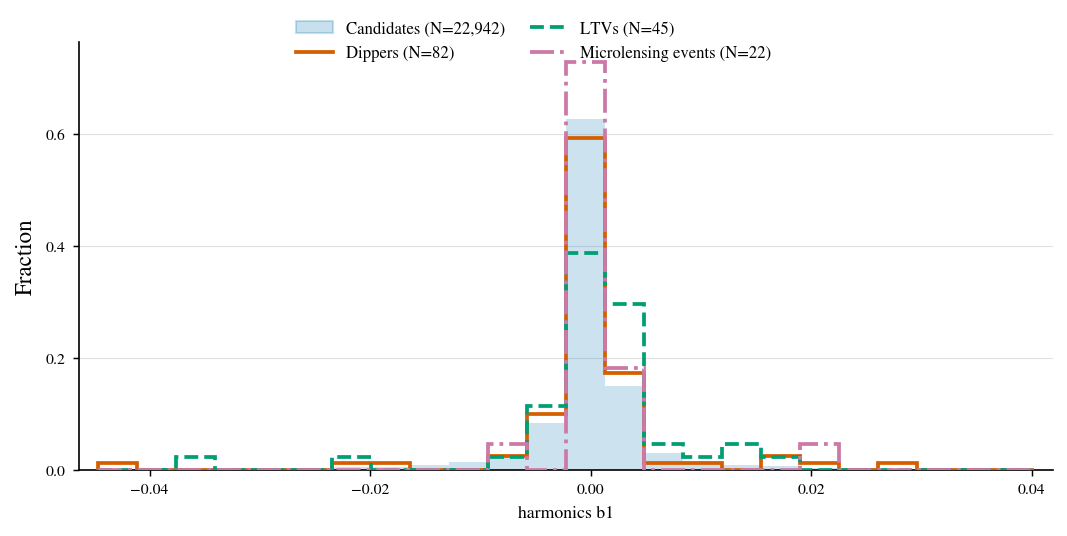

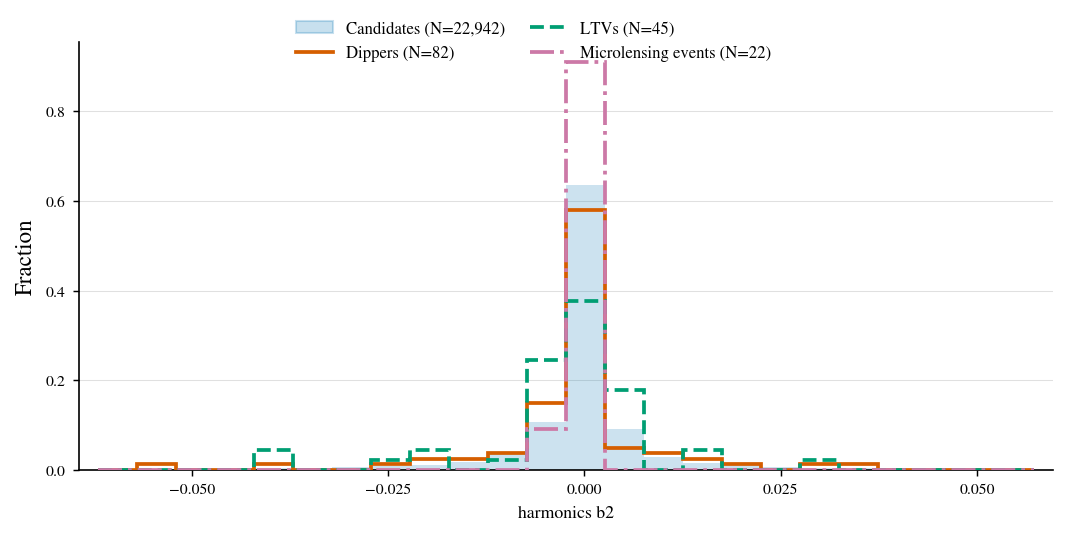

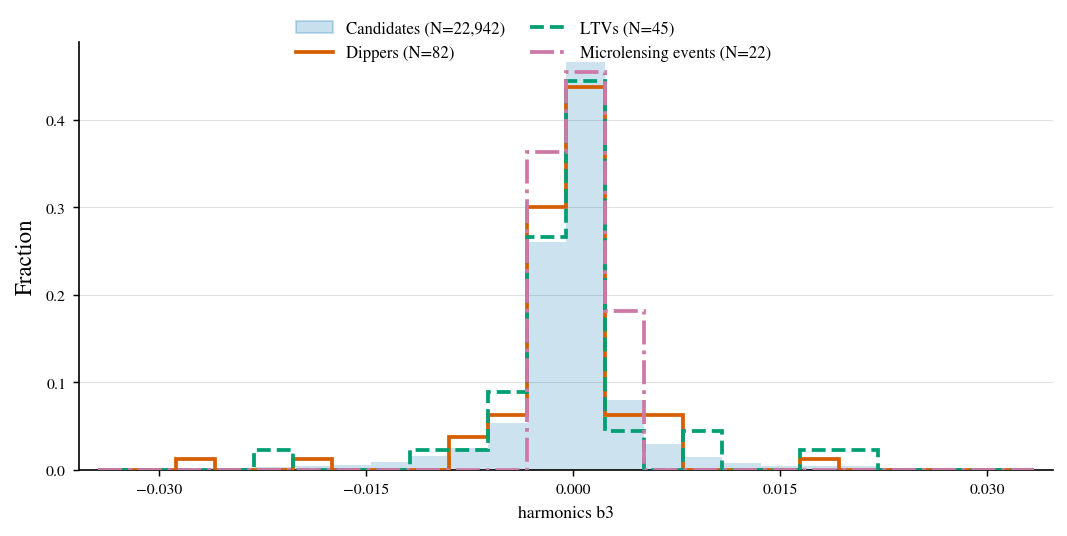

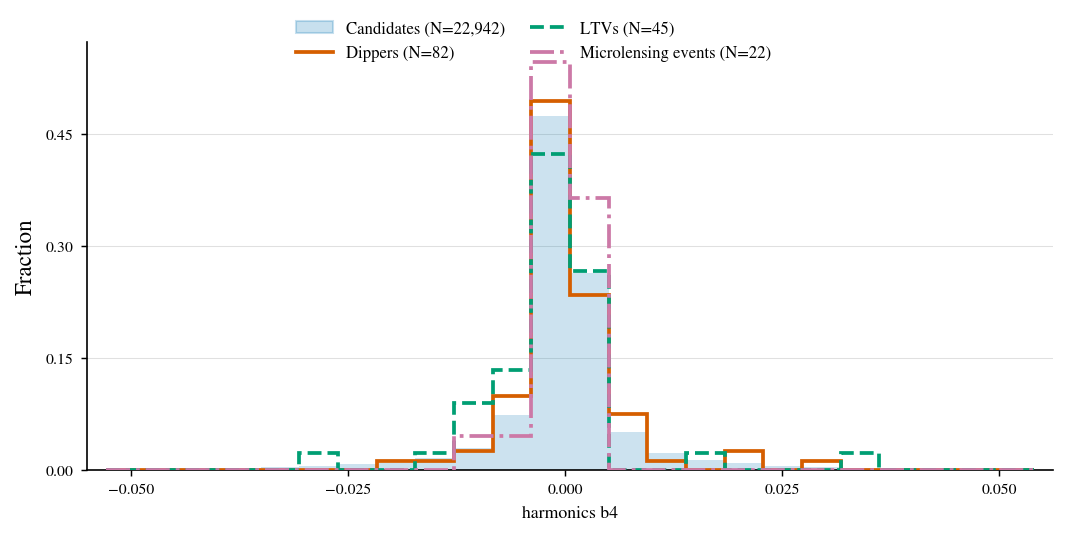

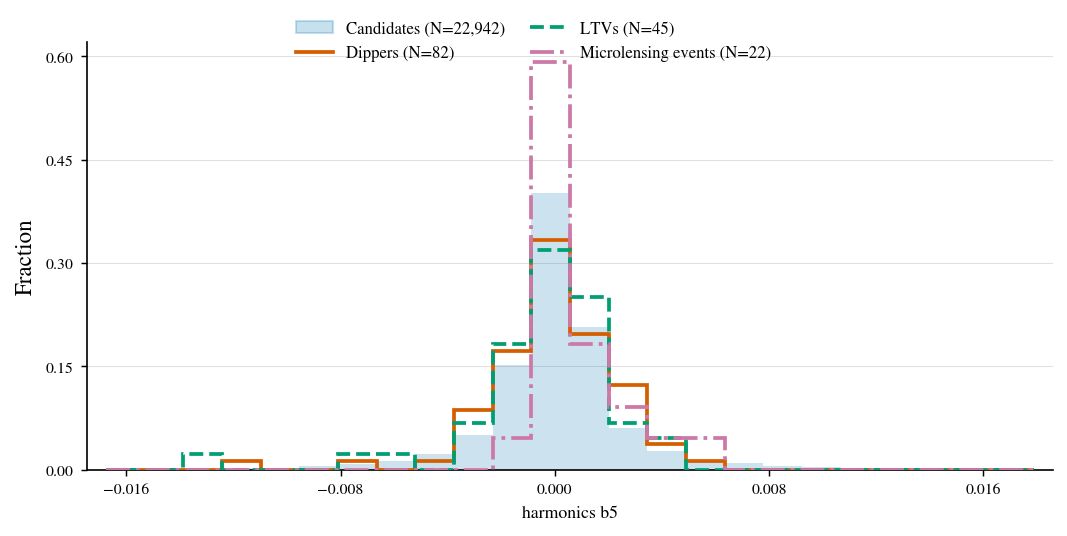

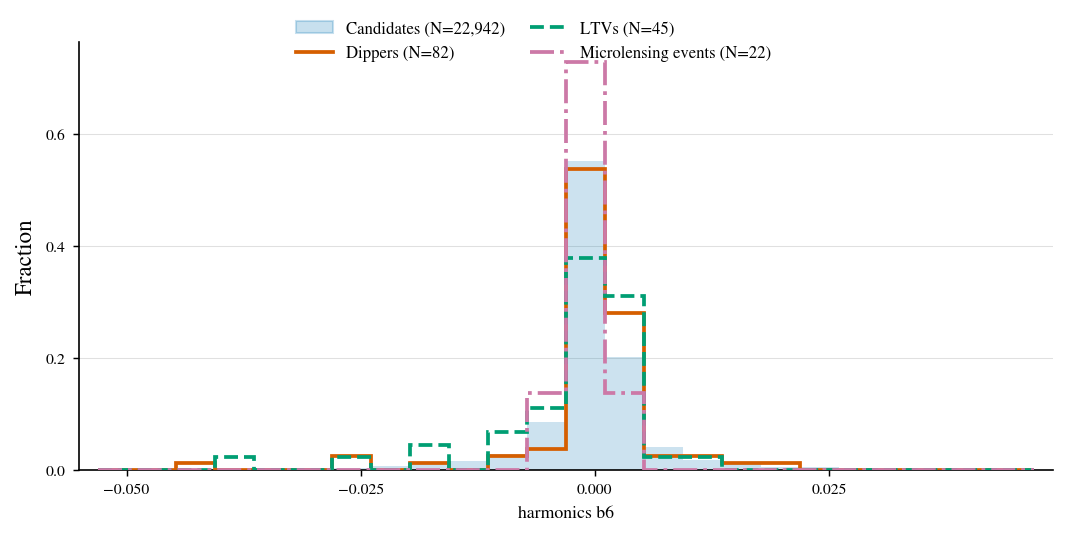

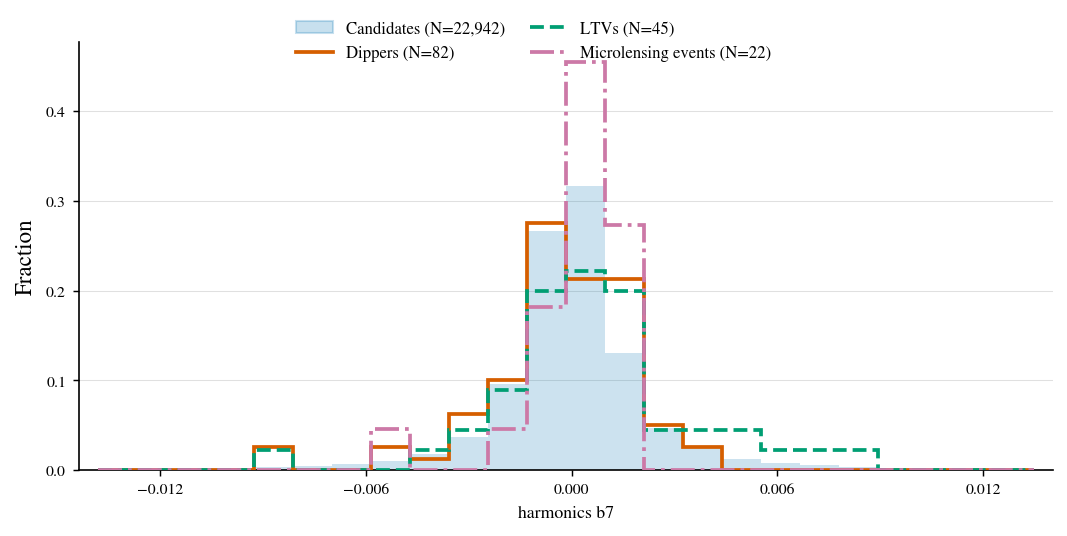

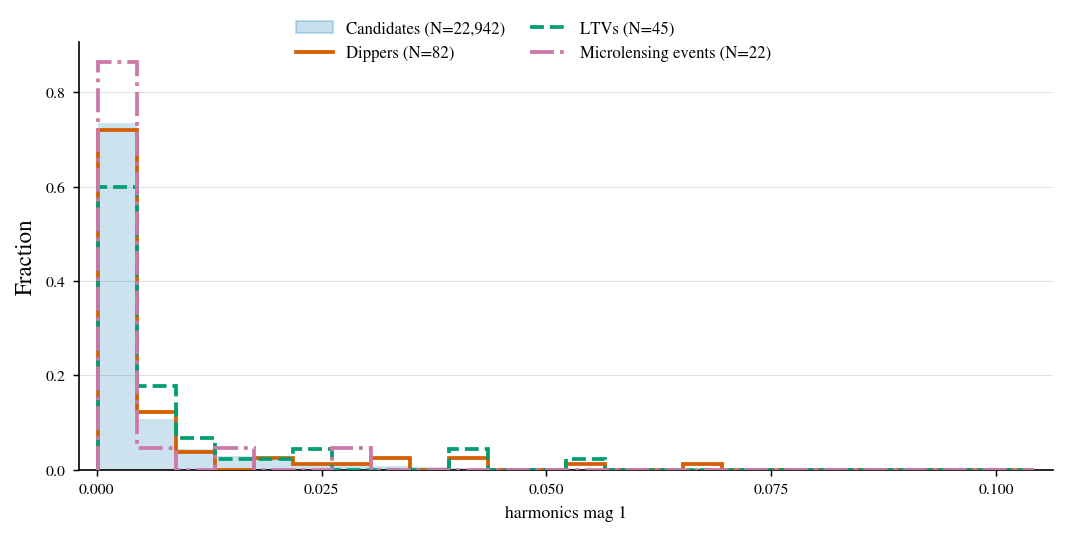

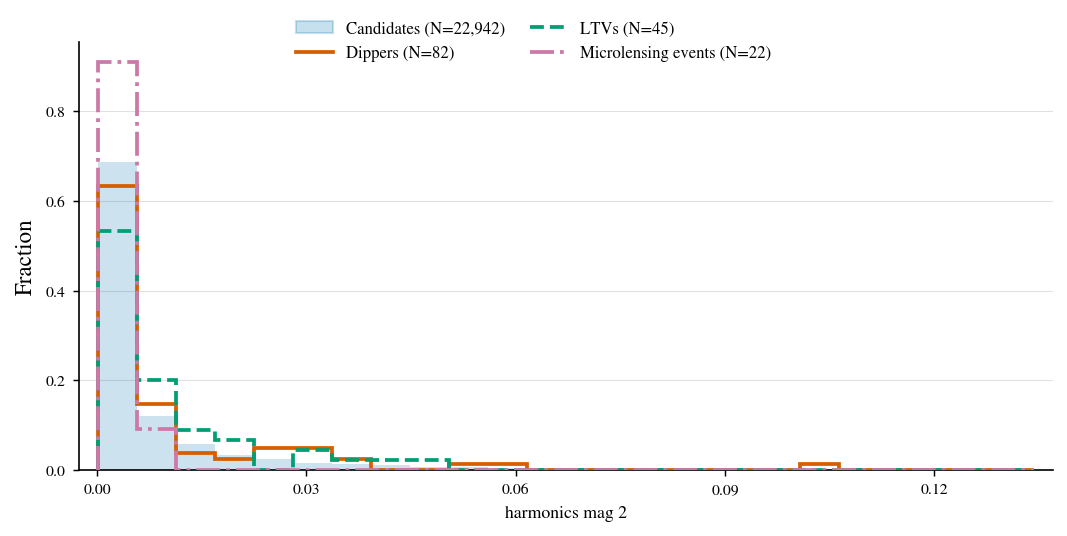

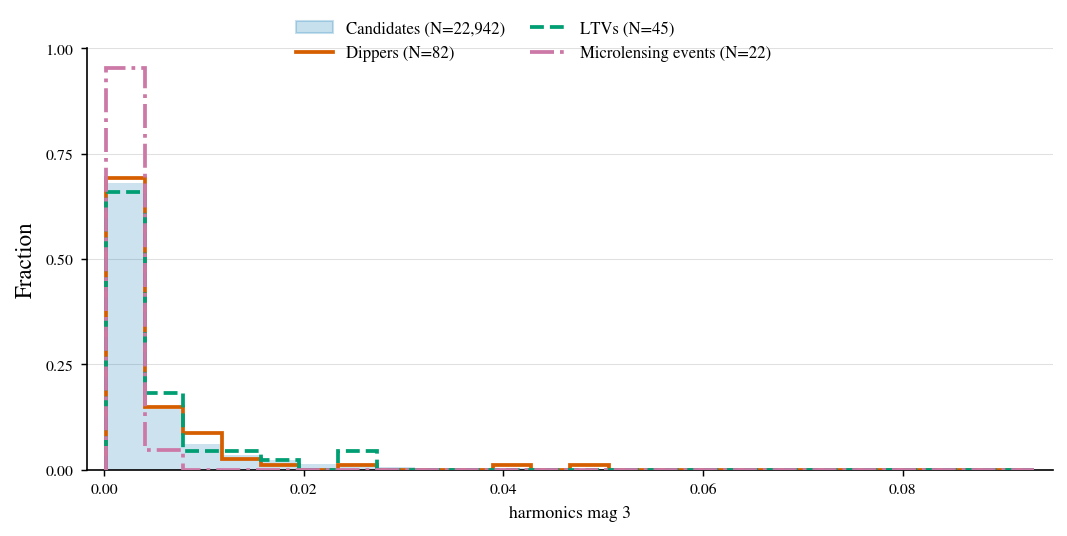

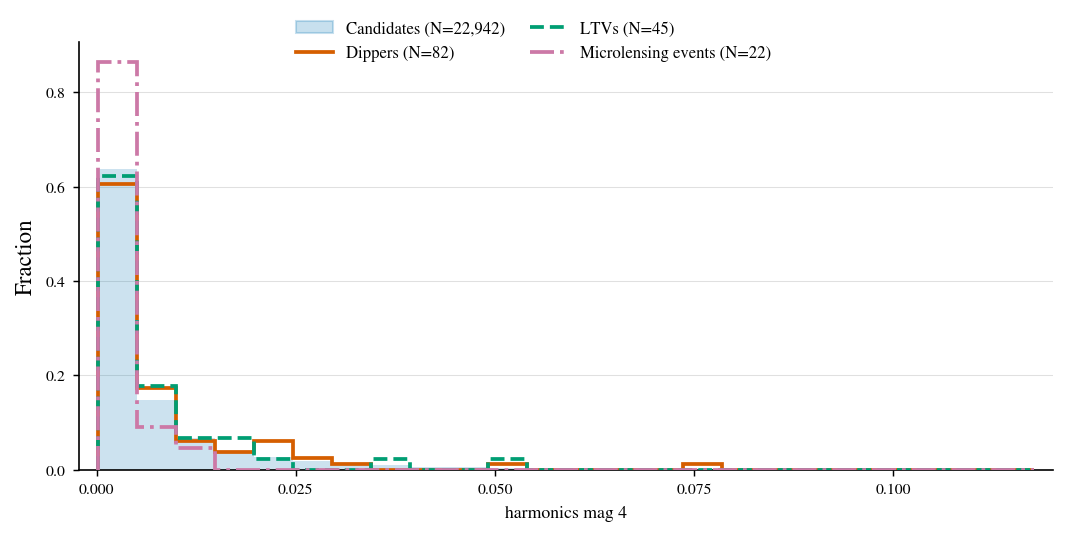

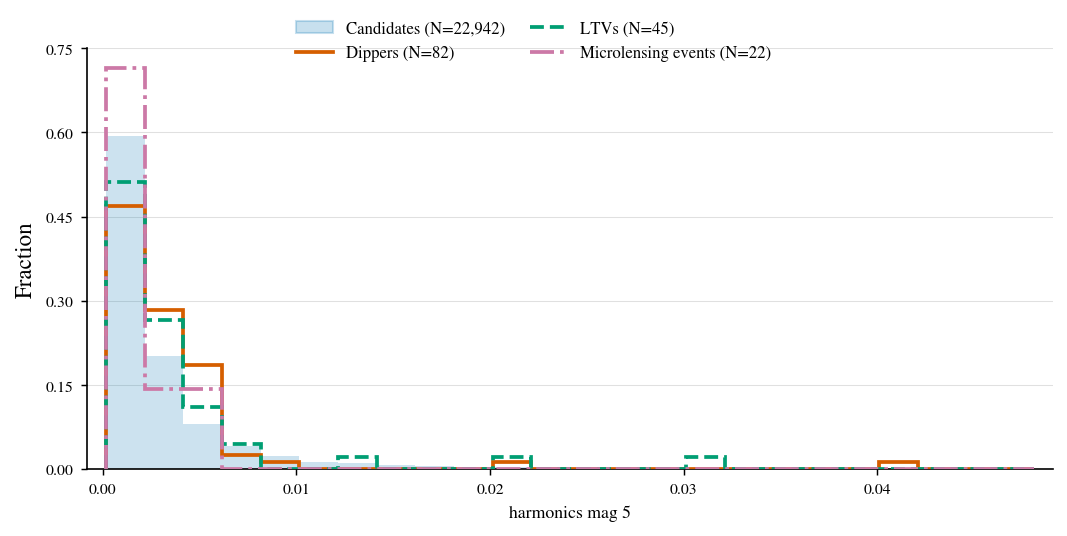

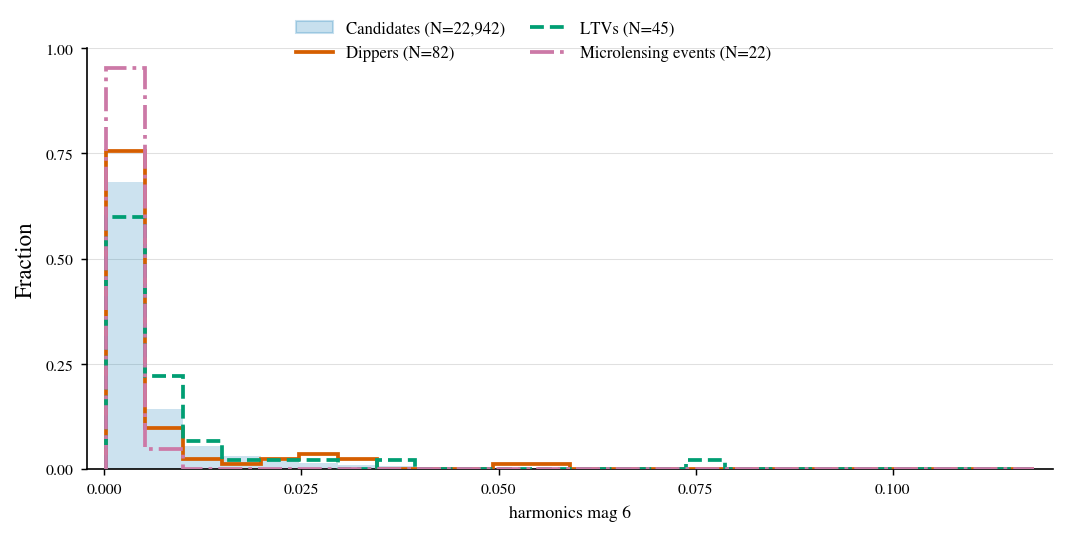

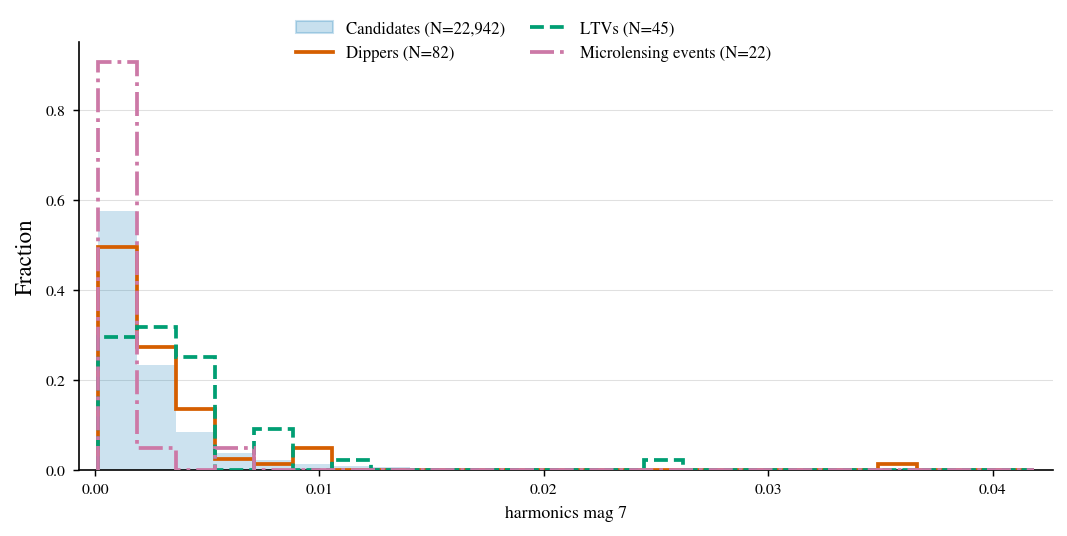

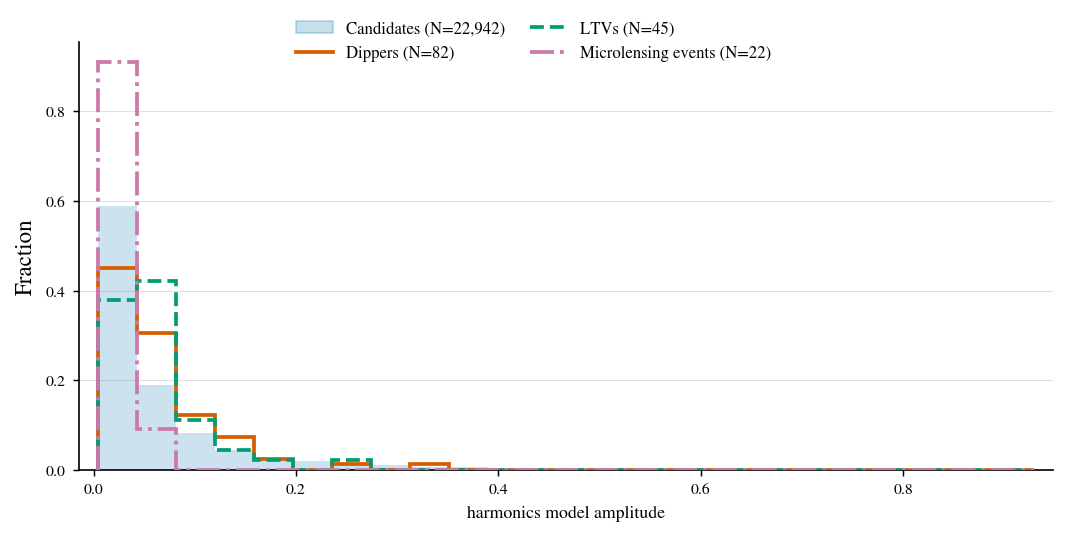

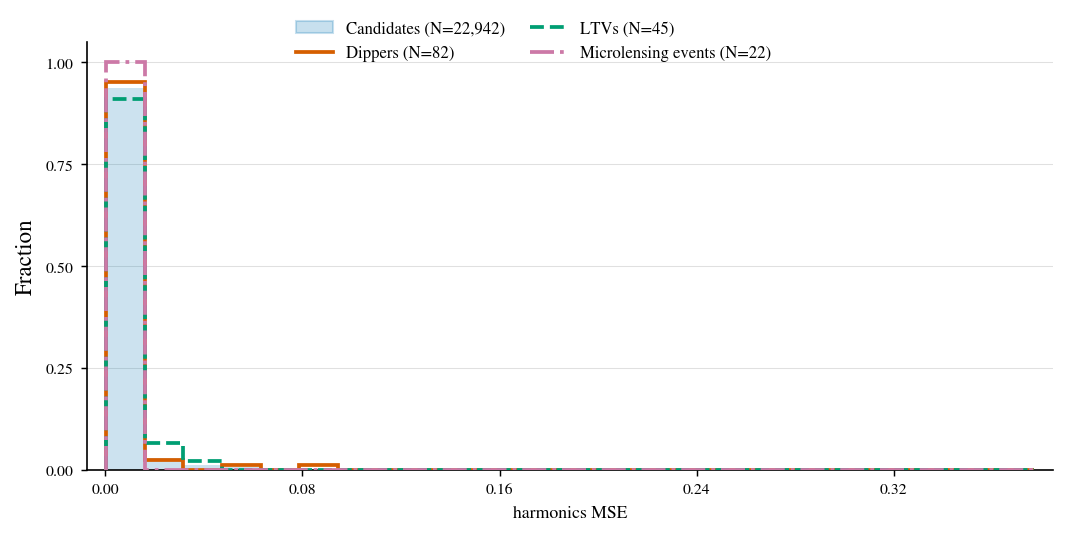

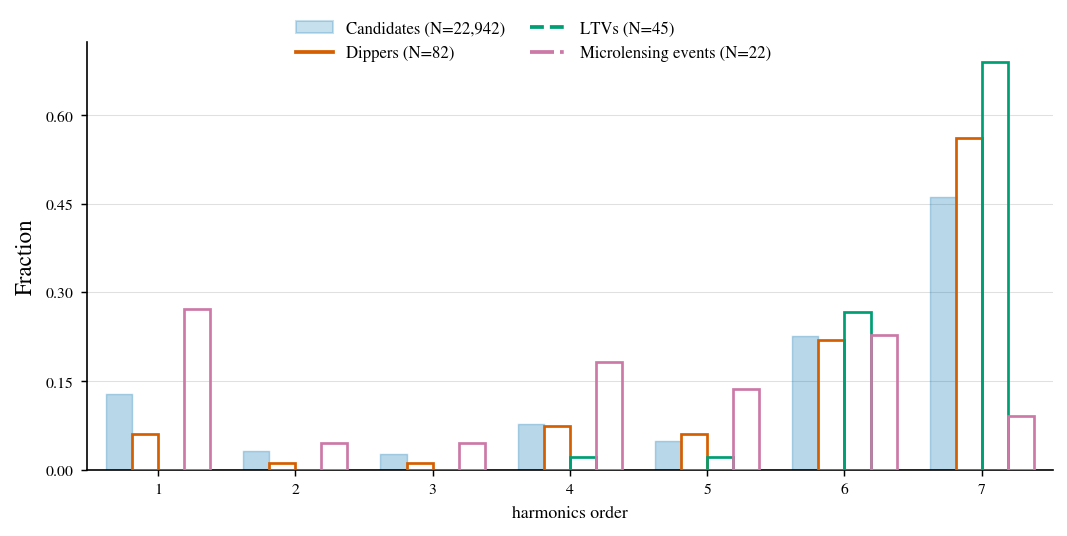

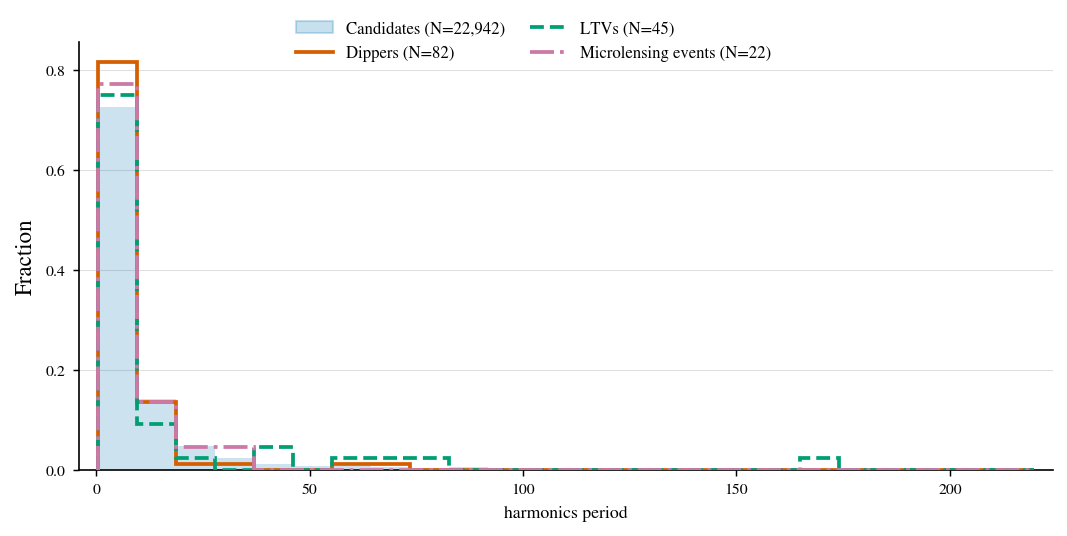

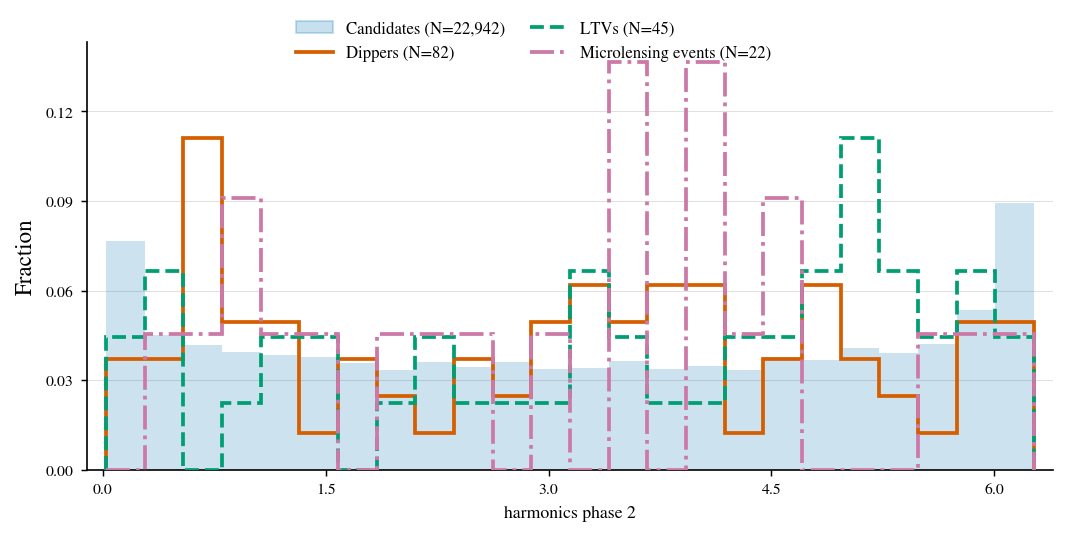

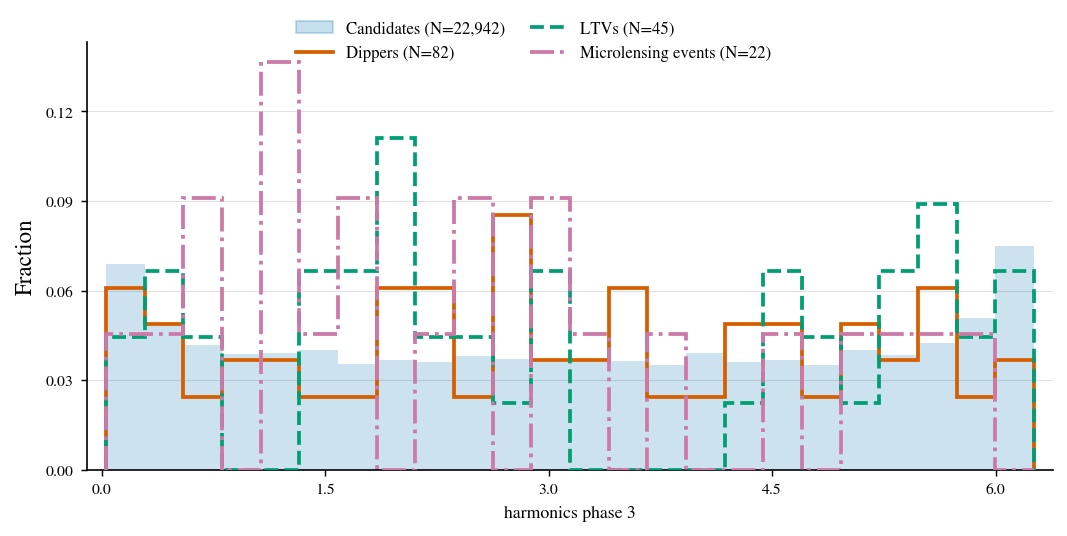

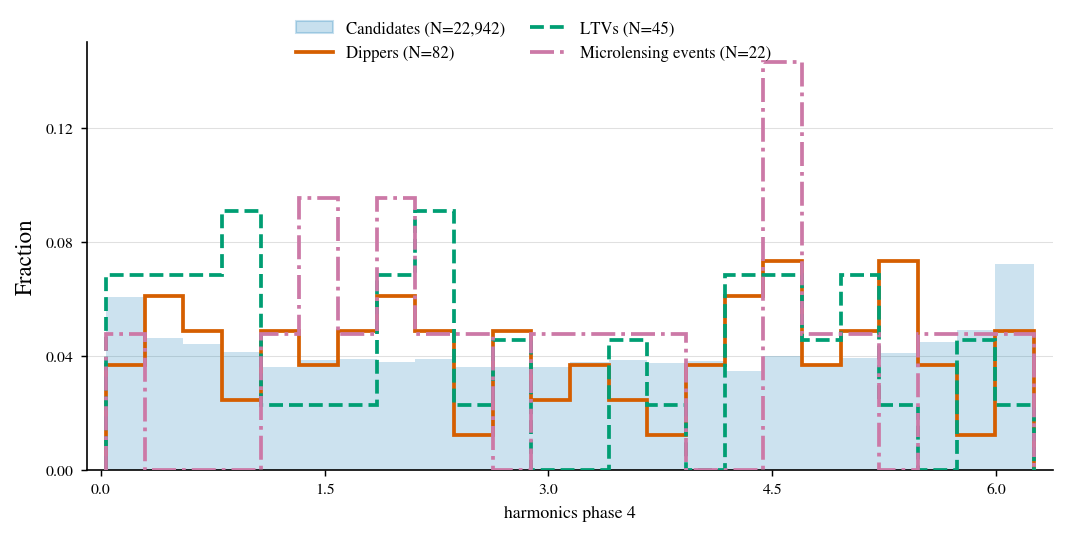

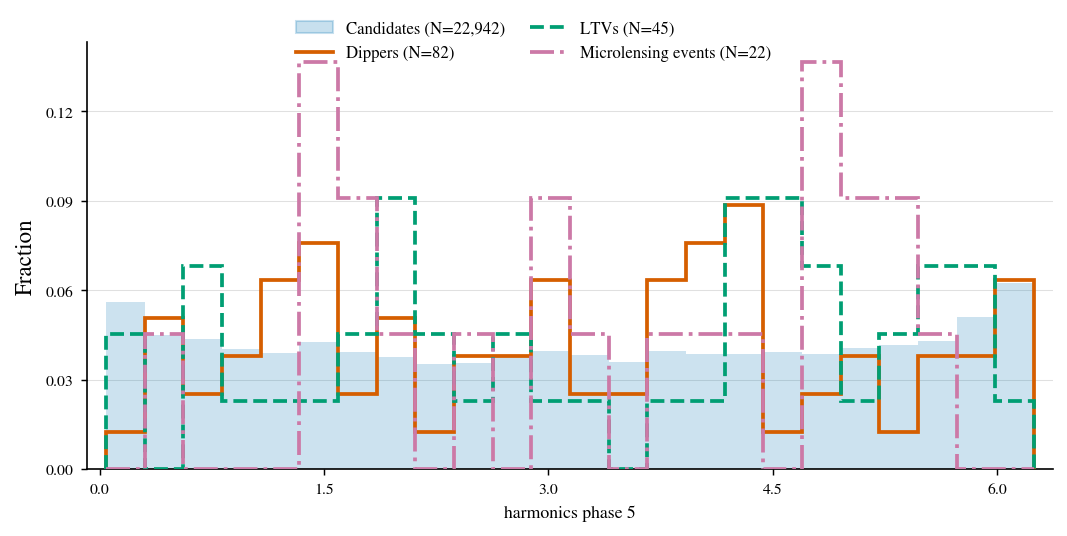

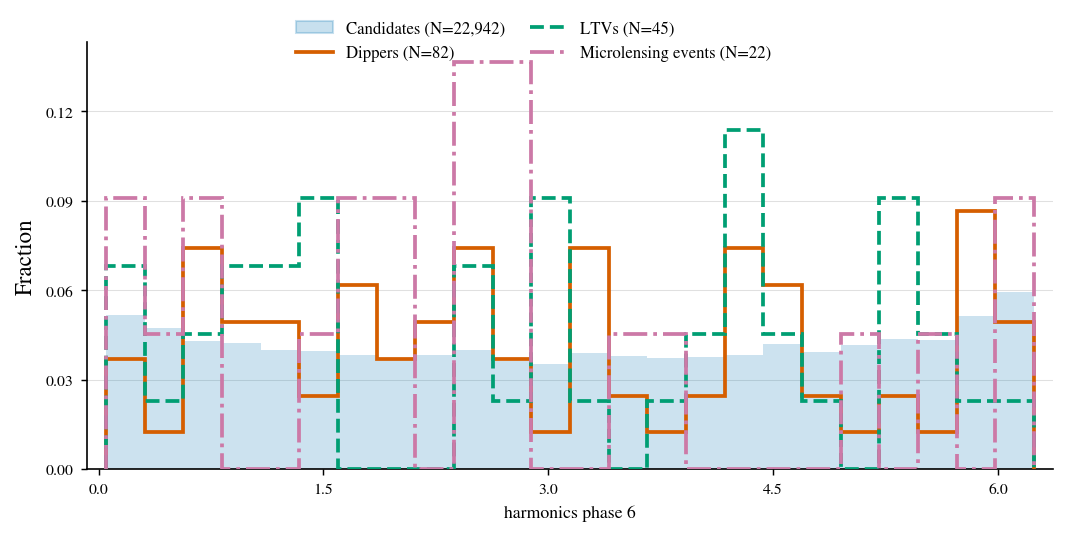

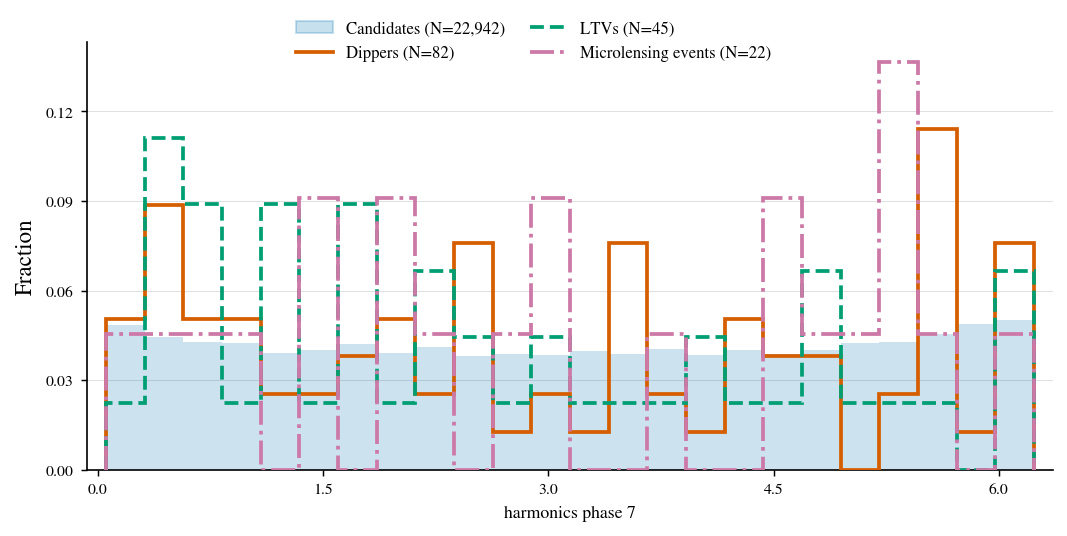

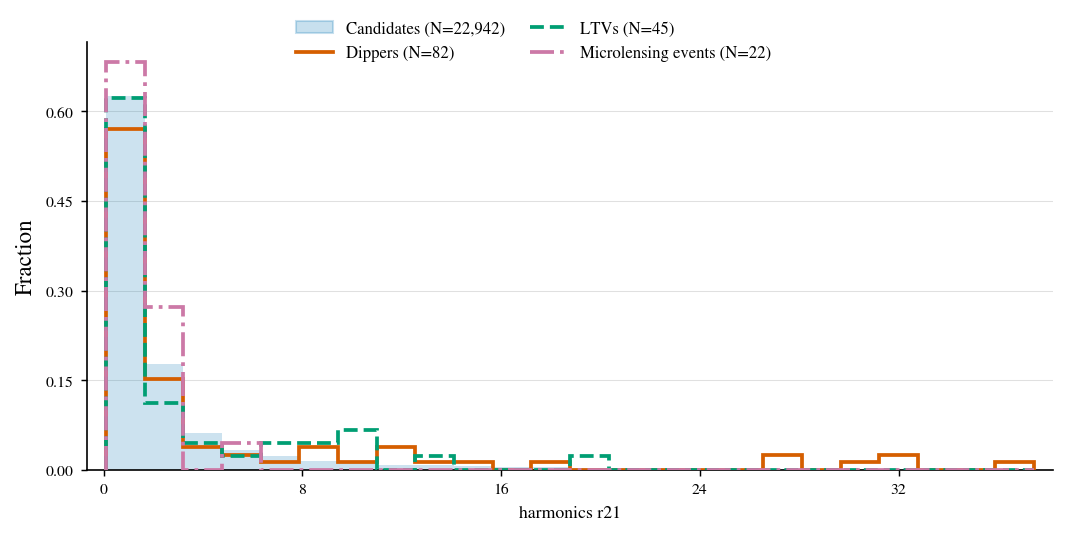

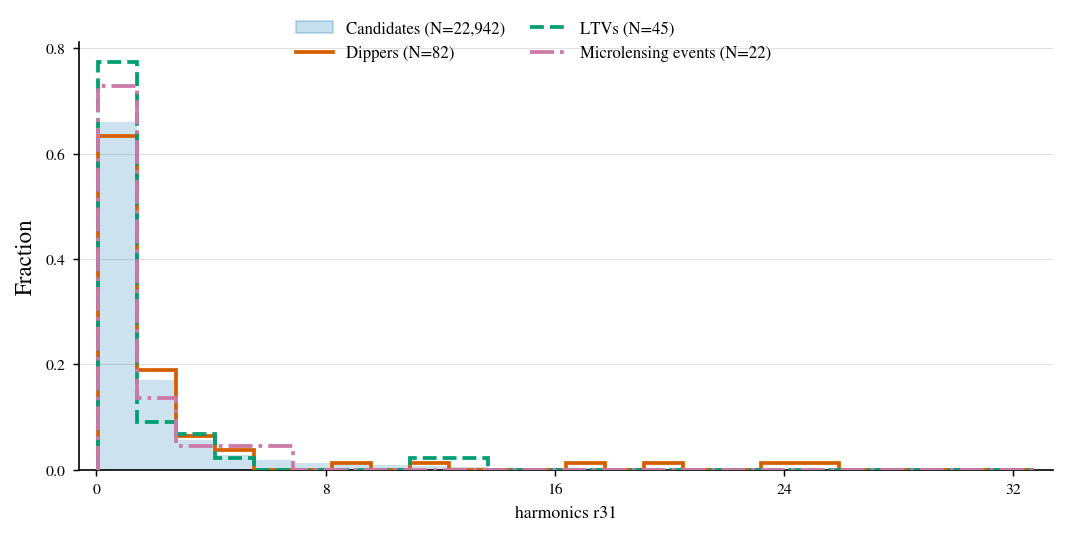

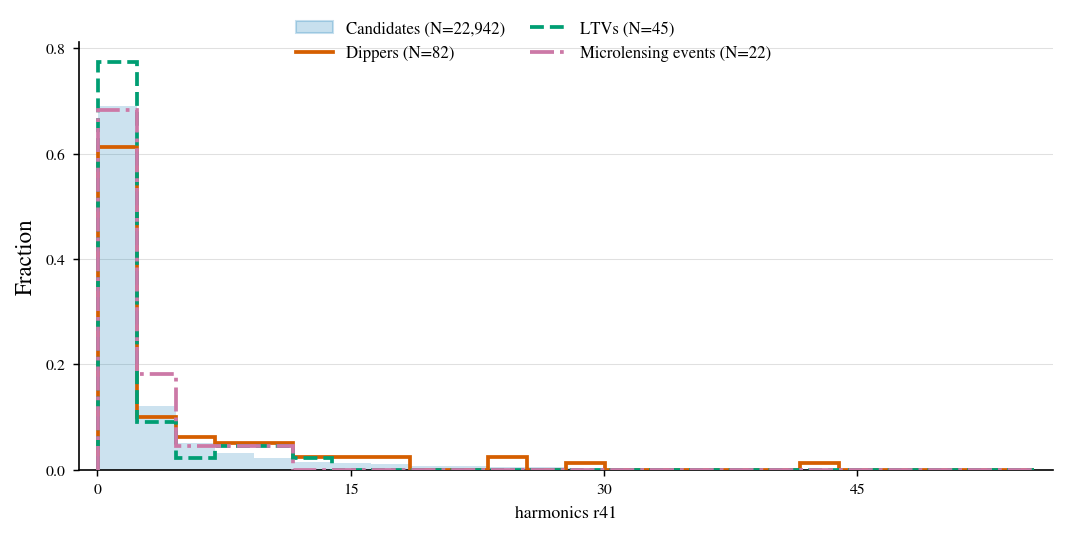

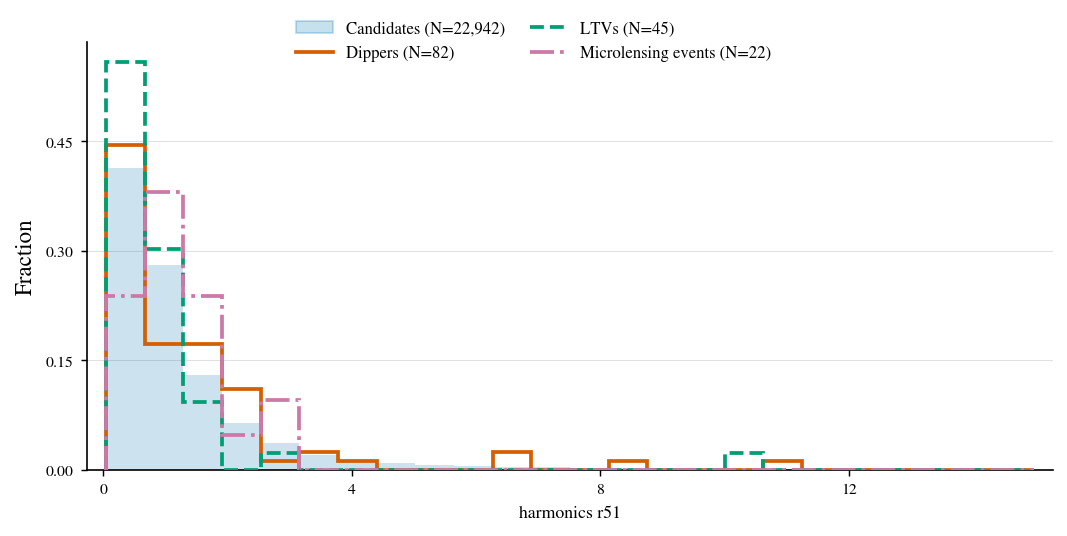

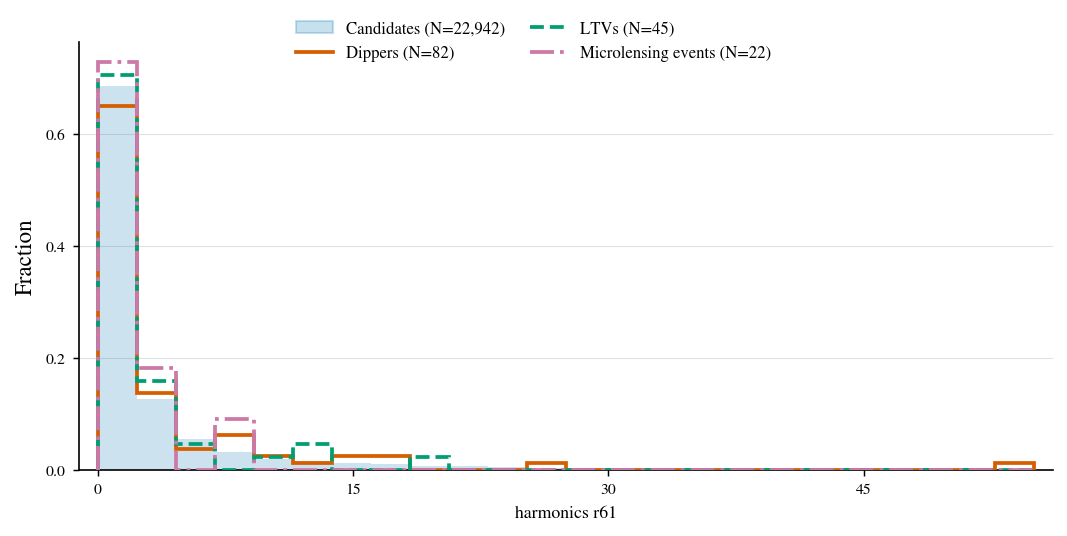

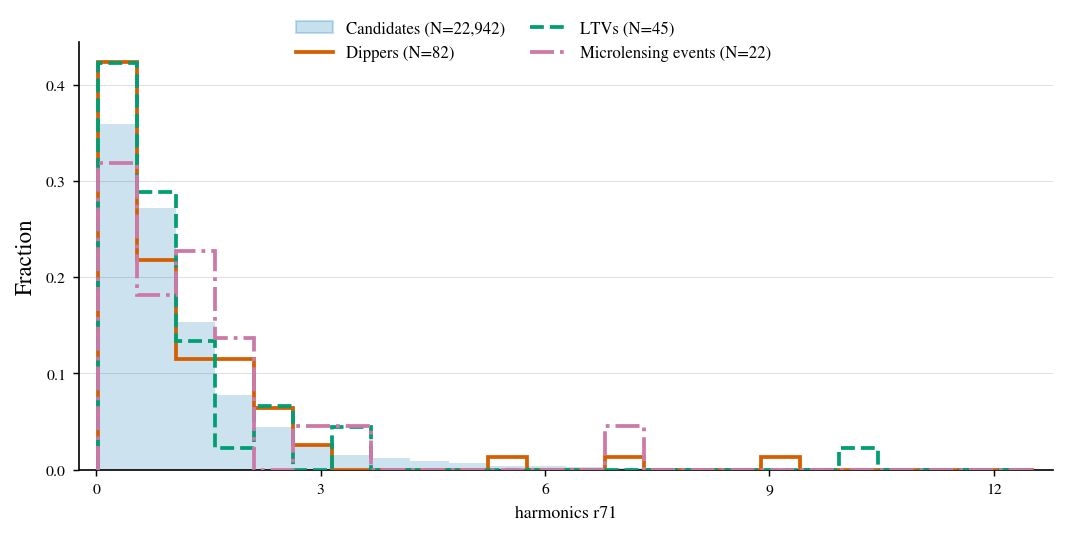

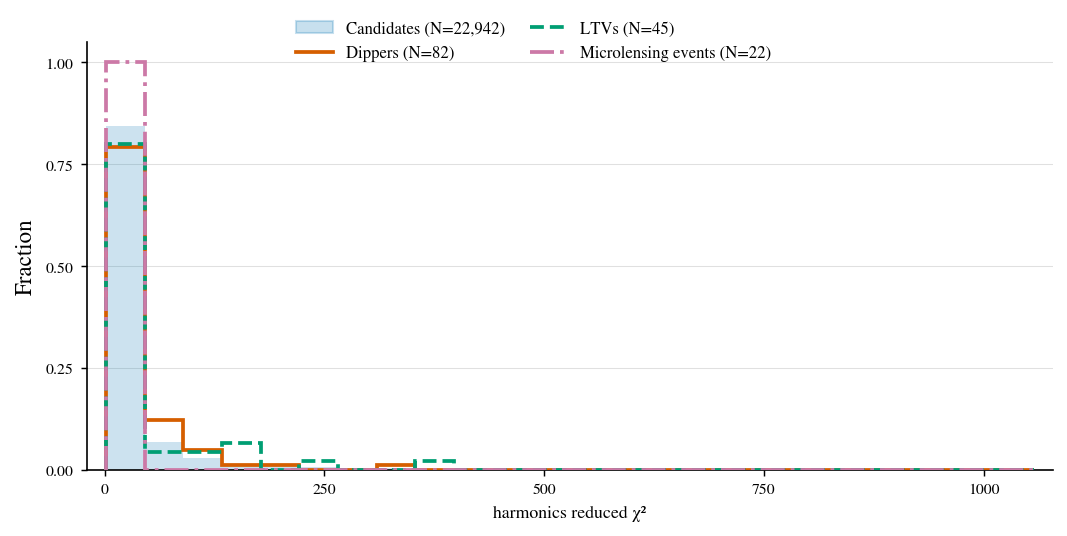

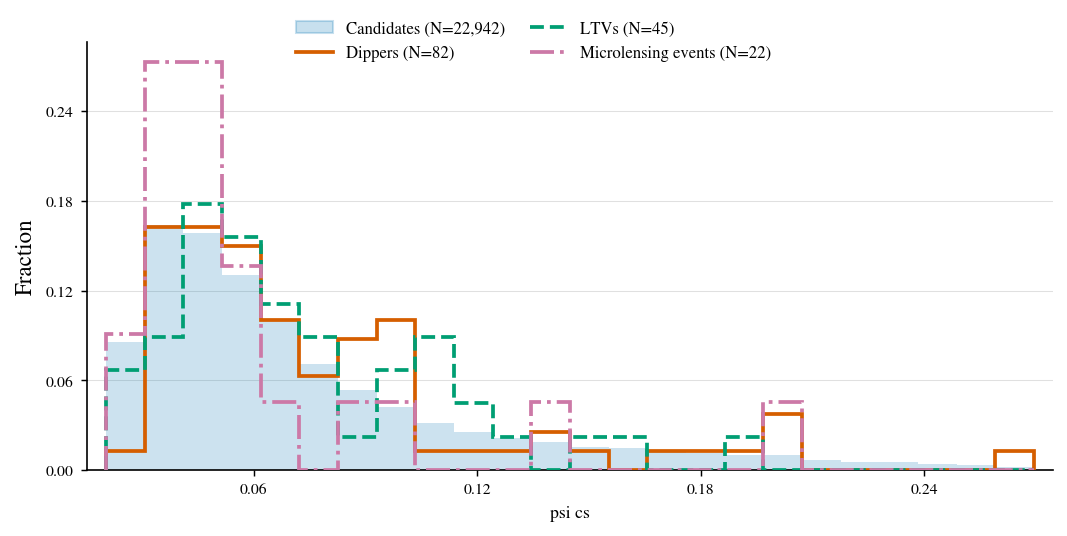

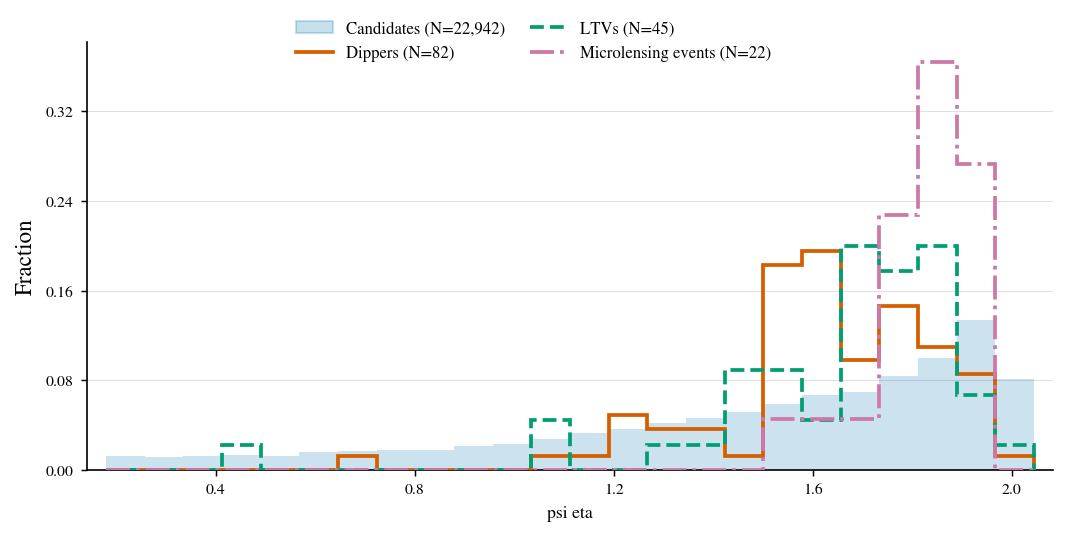

'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


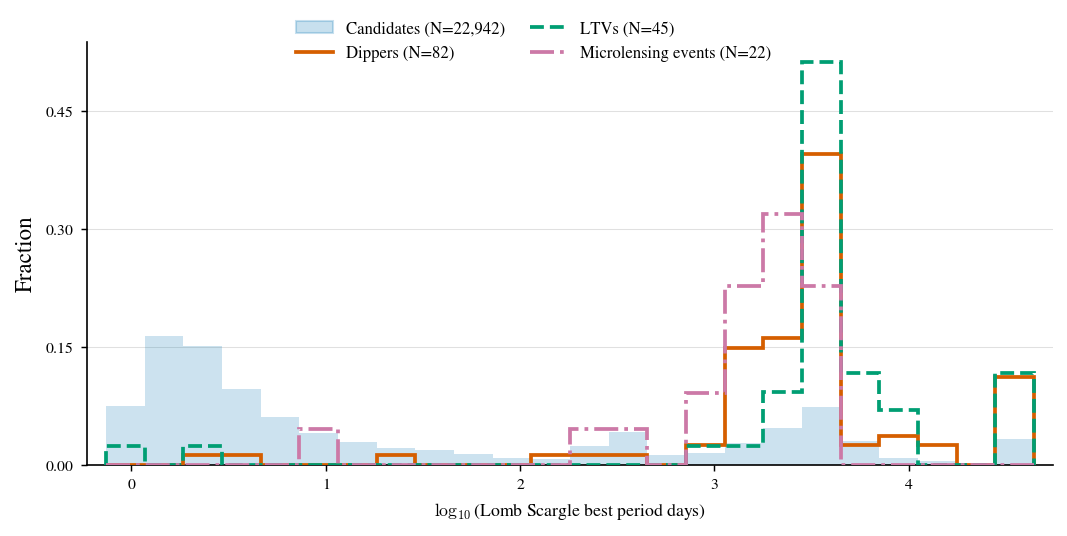

'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


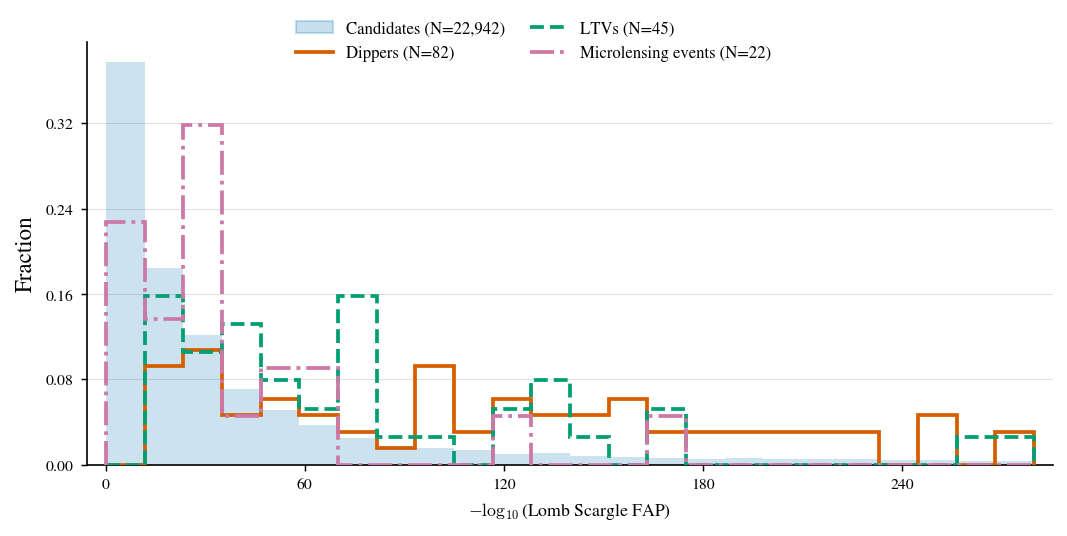

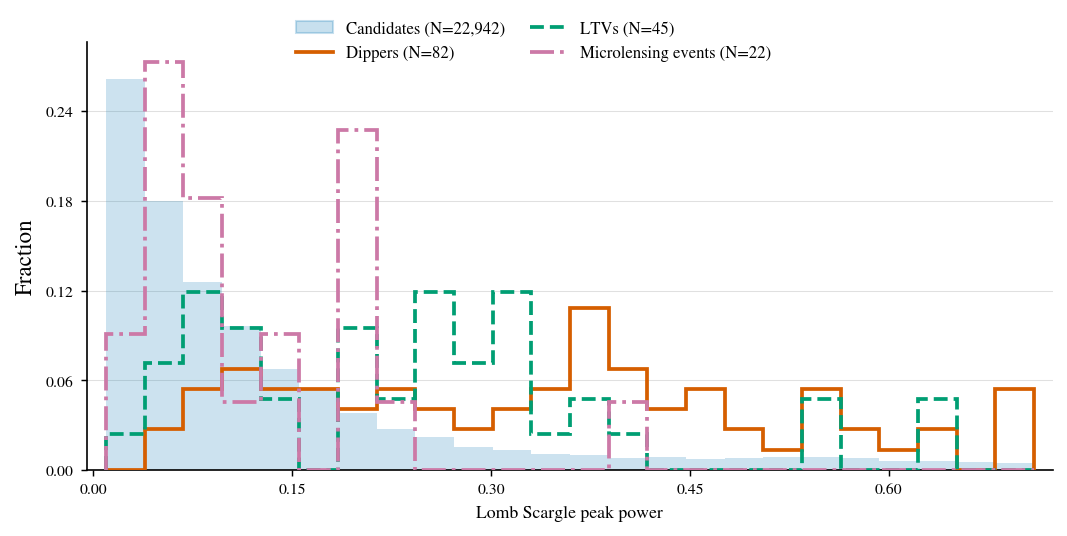

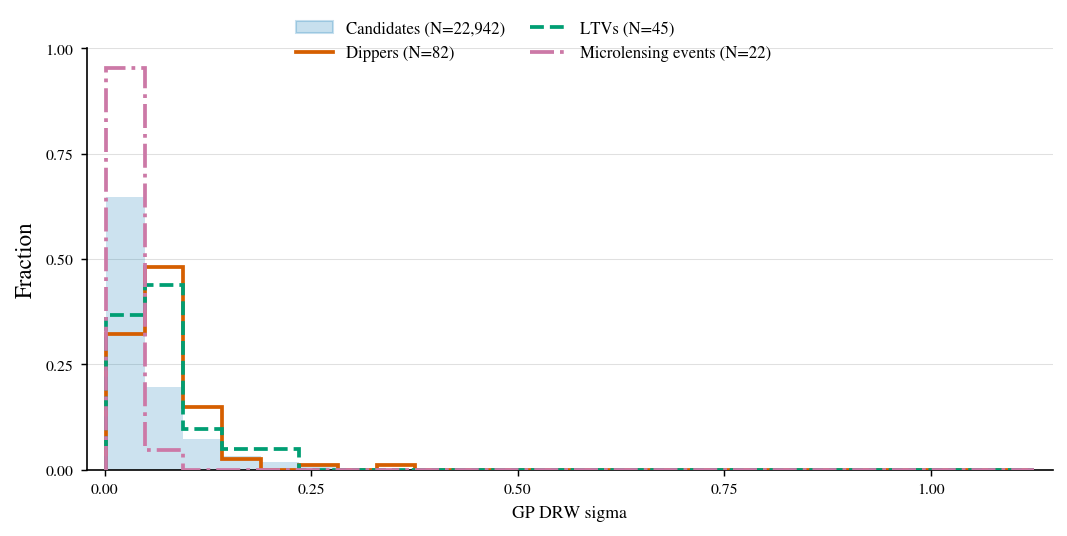

'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


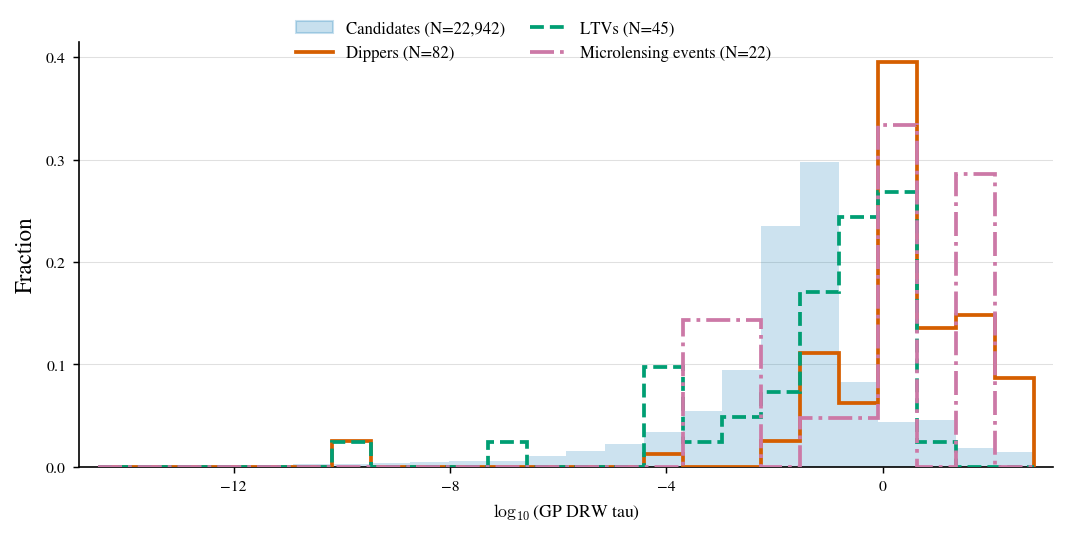

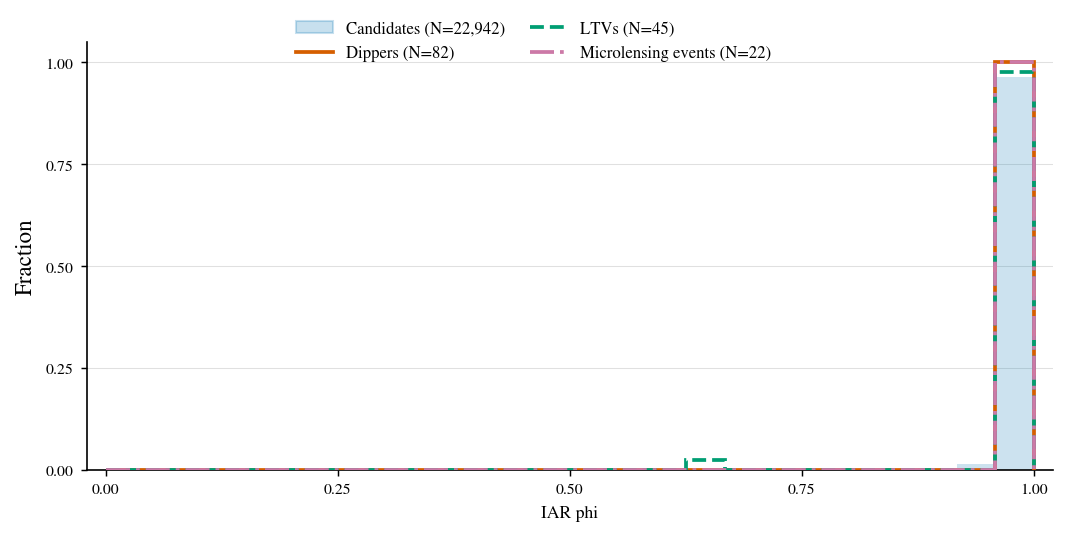

'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


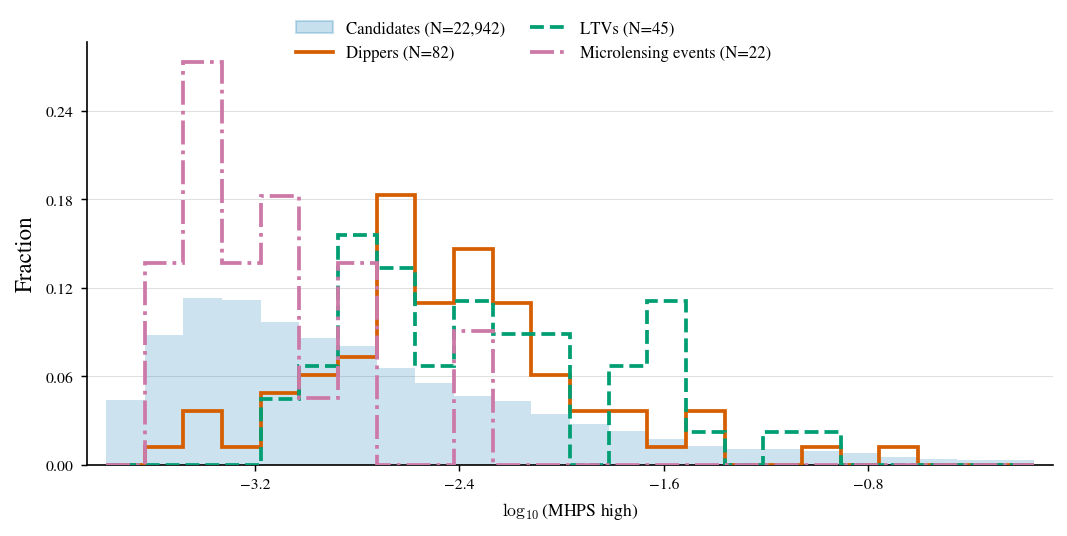

'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


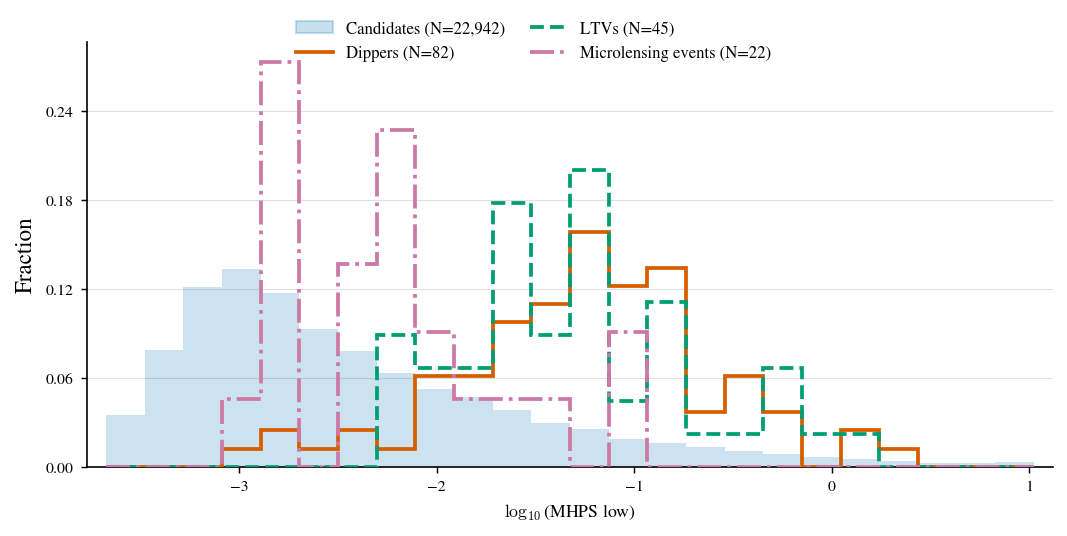

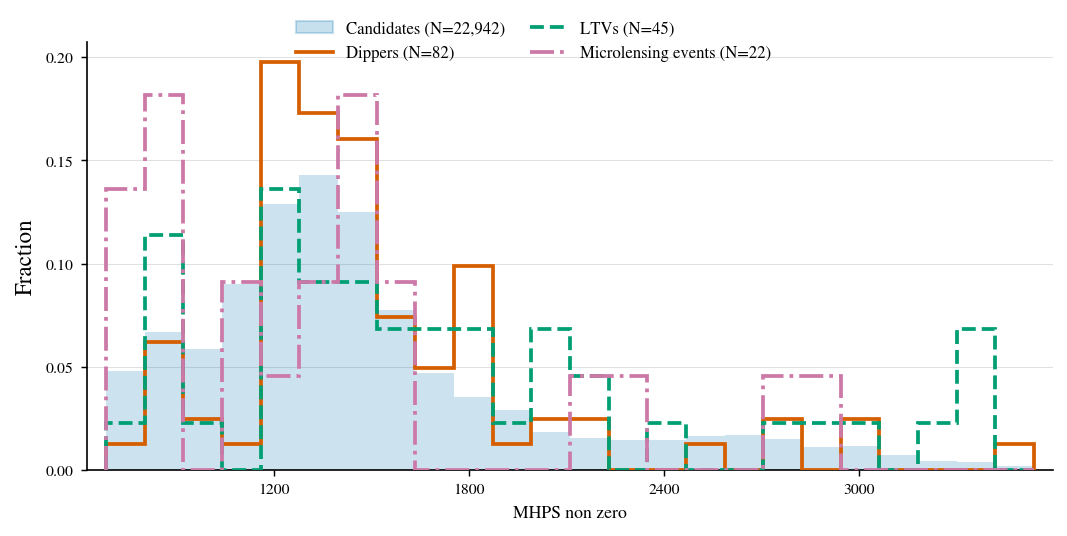

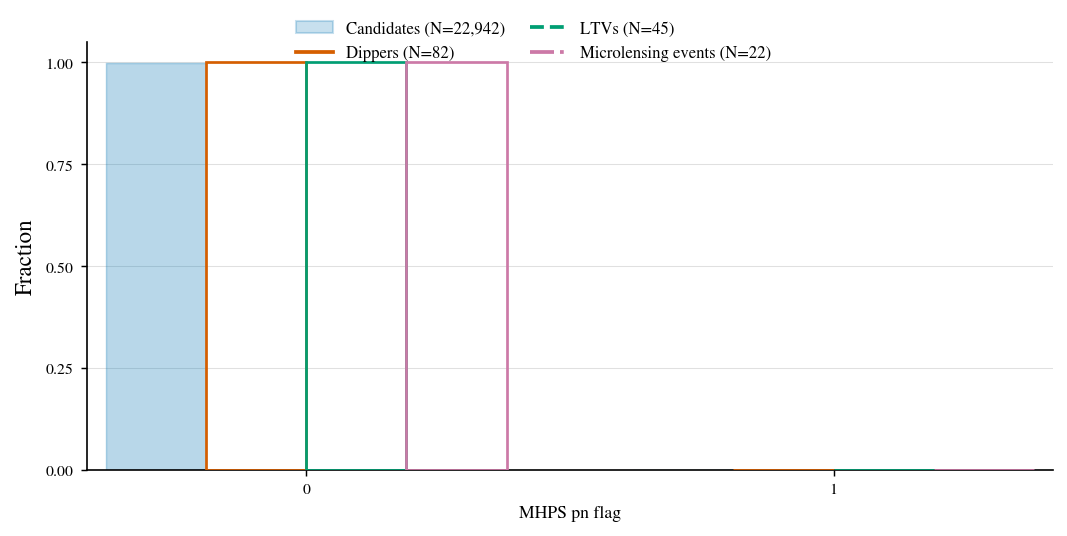

'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


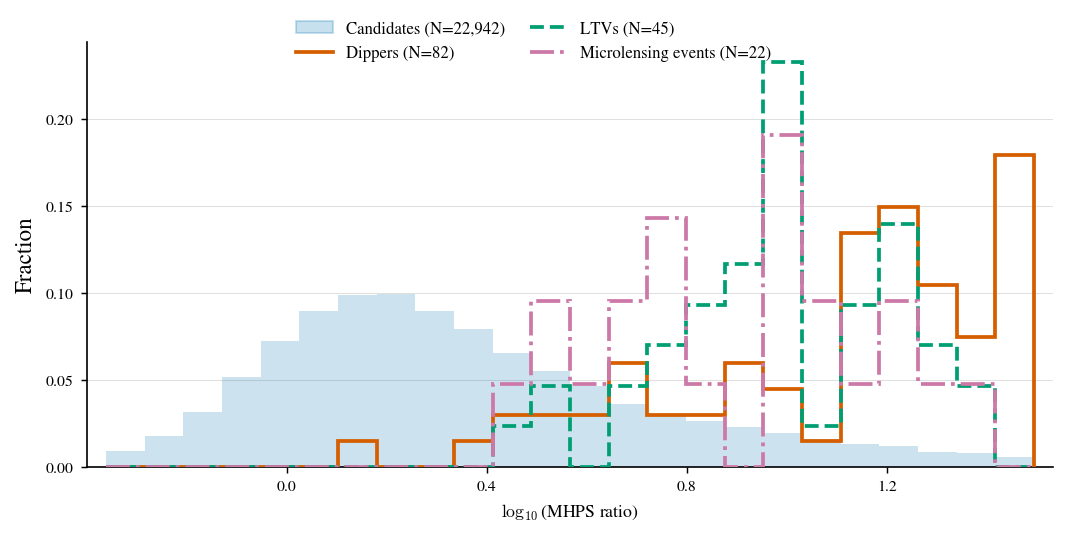

Exported 310 publication figure file(s) to /Users/calder/code/malca/output/runs/dat3-full-extended_2026-07-01-v4/results/population_stats_publication


,figure_path
0,/Users/calder/code/malca/output/runs/dat3-full...
1,/Users/calder/code/malca/output/runs/dat3-full...
2,/Users/calder/code/malca/output/runs/dat3-full...
3,/Users/calder/code/malca/output/runs/dat3-full...
4,/Users/calder/code/malca/output/runs/dat3-full...
...,...
305,/Users/calder/code/malca/output/runs/dat3-full...
306,/Users/calder/code/malca/output/runs/dat3-full...
307,/Users/calder/code/malca/output/runs/dat3-full...
308,/Users/calder/code/malca/output/runs/dat3-full...


In [8]:
exported_figure_paths = []
figure_output_dir = FIGURE_OUTPUT_DIR if EXPORT_FIGURES else None

for group_name in GROUP_ORDER:
    cols = [c for c in plottable_stats_cols if INVENTORY_MAP[c]['group'] == group_name]
    if cols:
        exported_figure_paths.extend(plot_group_histograms(
            df_all,
            cols,
            overlays=review_class_overlays,
            output_dir=figure_output_dir,
        ))

figure_manifest = pd.DataFrame({'figure_path': [str(path) for path in exported_figure_paths]})
print(f'Exported {len(exported_figure_paths):,} publication figure file(s) to {figure_output_dir}')
display(figure_manifest)


## Notes

- Missing Lomb-Scargle or harmonic columns usually mean those stats were not computed for the run product.
- Table-like outputs from `compute_stats(...)` are intentionally not part of the histogram inventory because they are not persisted as simple `stats_*` scalars.
- The publication figures use the full-population 1st–99th percentile range and shared adaptive bins (12–24). The candidate population is lightly filled; the dipper subset is a high-contrast outline.
- PDF exports are vector figures with embedded TrueType fonts; PNG exports are written at 300 dpi.
- If you only want a subset of runs, set `RUN_DIR_NAMES` at the top and rerun the notebook.
